# Part 2.1 | Bivariate Relationships

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'font.family': 'serif',              # Set the font family
    'font.serif': ['Times New Roman'],   # Use a specific serif font
    'font.size': 16,                     # Set the general font size
    'axes.titlesize': 20,                # Set the font size of the title
    'axes.labelsize': 16,                # Set the font size of axis labels
    'font.style': 'italic',              # Set the font style to italic
    'figure.dpi': 400   
})

category_color_pal = sns.color_palette("hls", 8)#sns.color_palette("husl", 8)
continuous_color_pal = sns.color_palette("rocket_r", as_cmap=True)

## Anscombe's Quartet

In [2]:
# Load Anscombe's Quartet
anscombe = pd.read_csv('../../data/Anscombes_Quartet.csv')

# Calculate summary statistics for each dataset
stats = anscombe.groupby('dataset').agg({
    'x': ['mean', 'std'],
    'y': ['mean', 'std']
}).round(2)

# Calculate correlation for each dataset
correlations = anscombe.groupby('dataset').apply(lambda d: d['x'].corr(d['y'])).round(3)

print("Summary Statistics:")
print(stats)
print("\nCorrelations:")
print(correlations)

Summary Statistics:
           x          y      
        mean   std mean   std
dataset                      
I        9.0  3.32  7.5  2.03
II       9.0  3.32  7.5  2.03
III      9.0  3.32  7.5  2.03
IV       9.0  3.32  7.5  2.03

Correlations:
dataset
I      0.816
II     0.816
III    0.816
IV     0.817
dtype: float64


/var/folders/v7/n92bbkrn50x_rhkvsgm29llc0000gn/T/ipykernel_80456/1032751557.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations = anscombe.groupby('dataset').apply(lambda d: d['x'].corr(d['y'])).round(3)


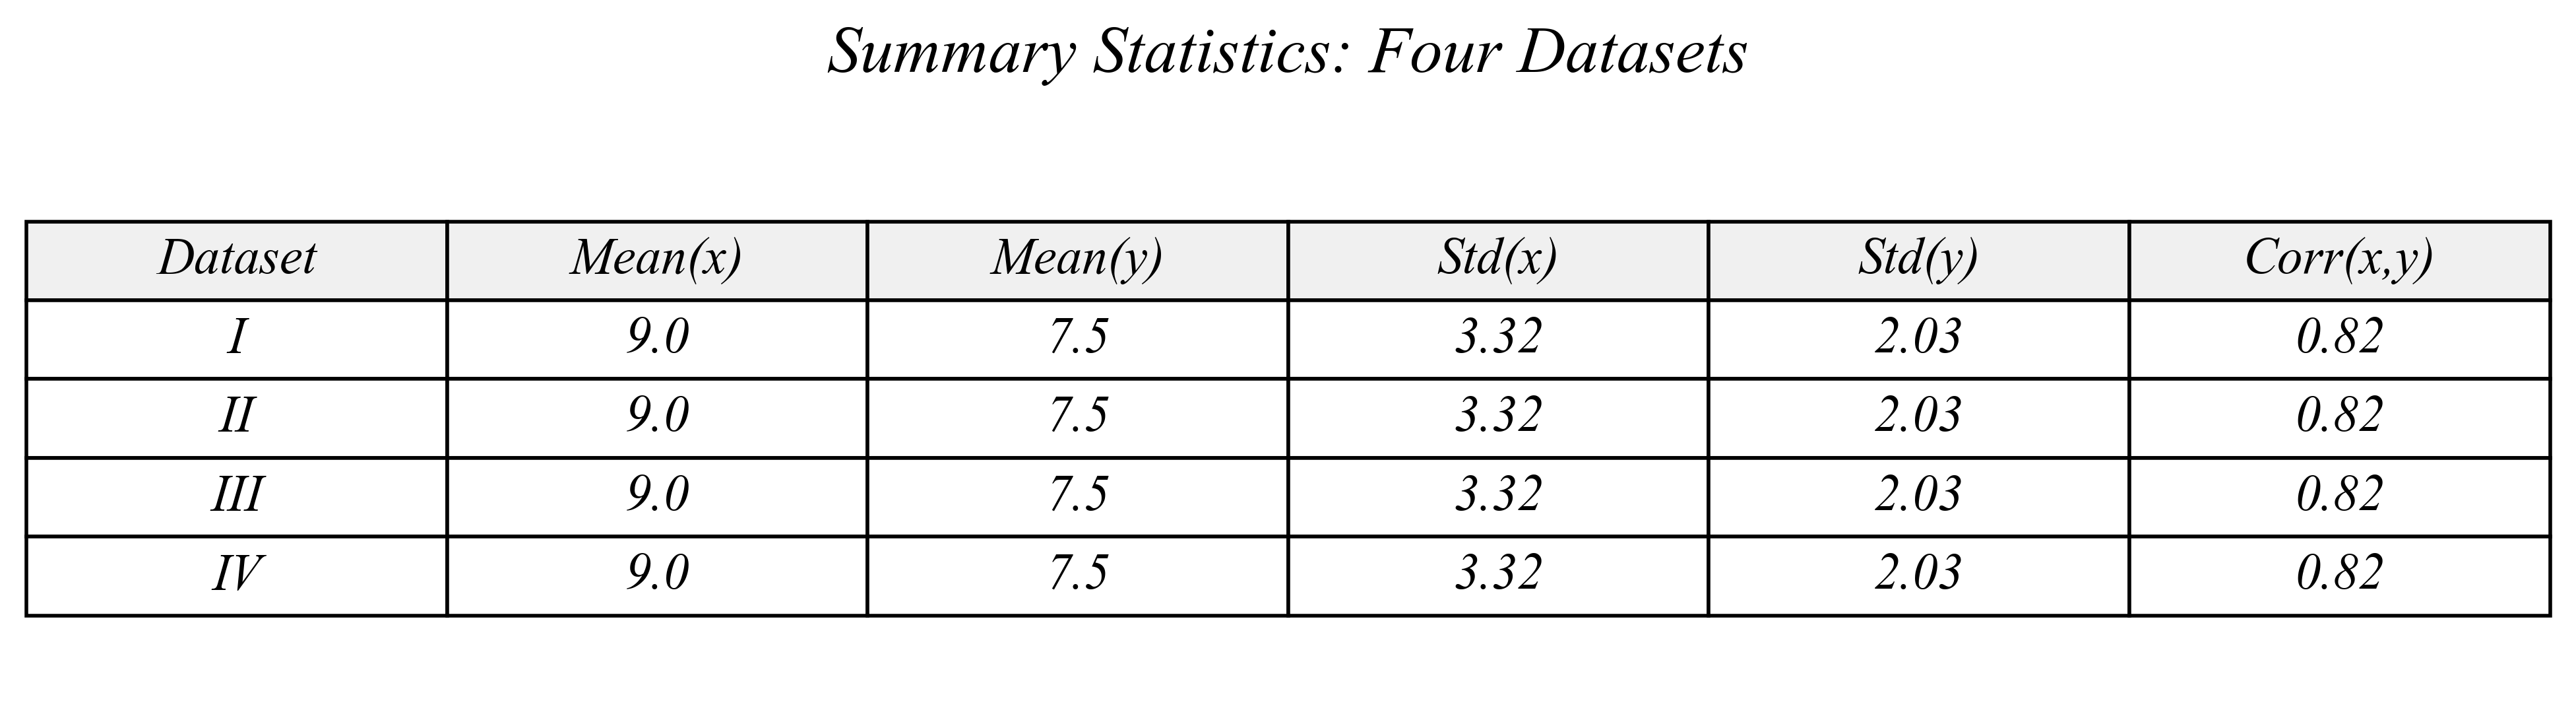

In [3]:
# Figure: Summary statistics table
anscombe = pd.read_csv('../../data/Anscombes_Quartet.csv')

# Calculate stats for each dataset
summary_data = []
for dataset in ['I', 'II', 'III', 'IV']:
    d = anscombe[anscombe['dataset'] == dataset]
    summary_data.append({
        'Dataset': dataset,
        'Mean(x)': round(d['x'].mean(), 2),
        'Mean(y)': round(d['y'].mean(), 2),
        'Std(x)': round(d['x'].std(), 2),
        'Std(y)': round(d['y'].std(), 2),
        'Corr(x,y)': round(d['x'].corr(d['y']), 2)
    })

summary_df = pd.DataFrame(summary_data)

# Create table figure
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center',
    colColours=['#f0f0f0']*6
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 2)

plt.title('Summary Statistics: Four Datasets', fontsize=18, pad=20)
plt.tight_layout()
plt.savefig('i/a_01.png', bbox_inches='tight', dpi=300)

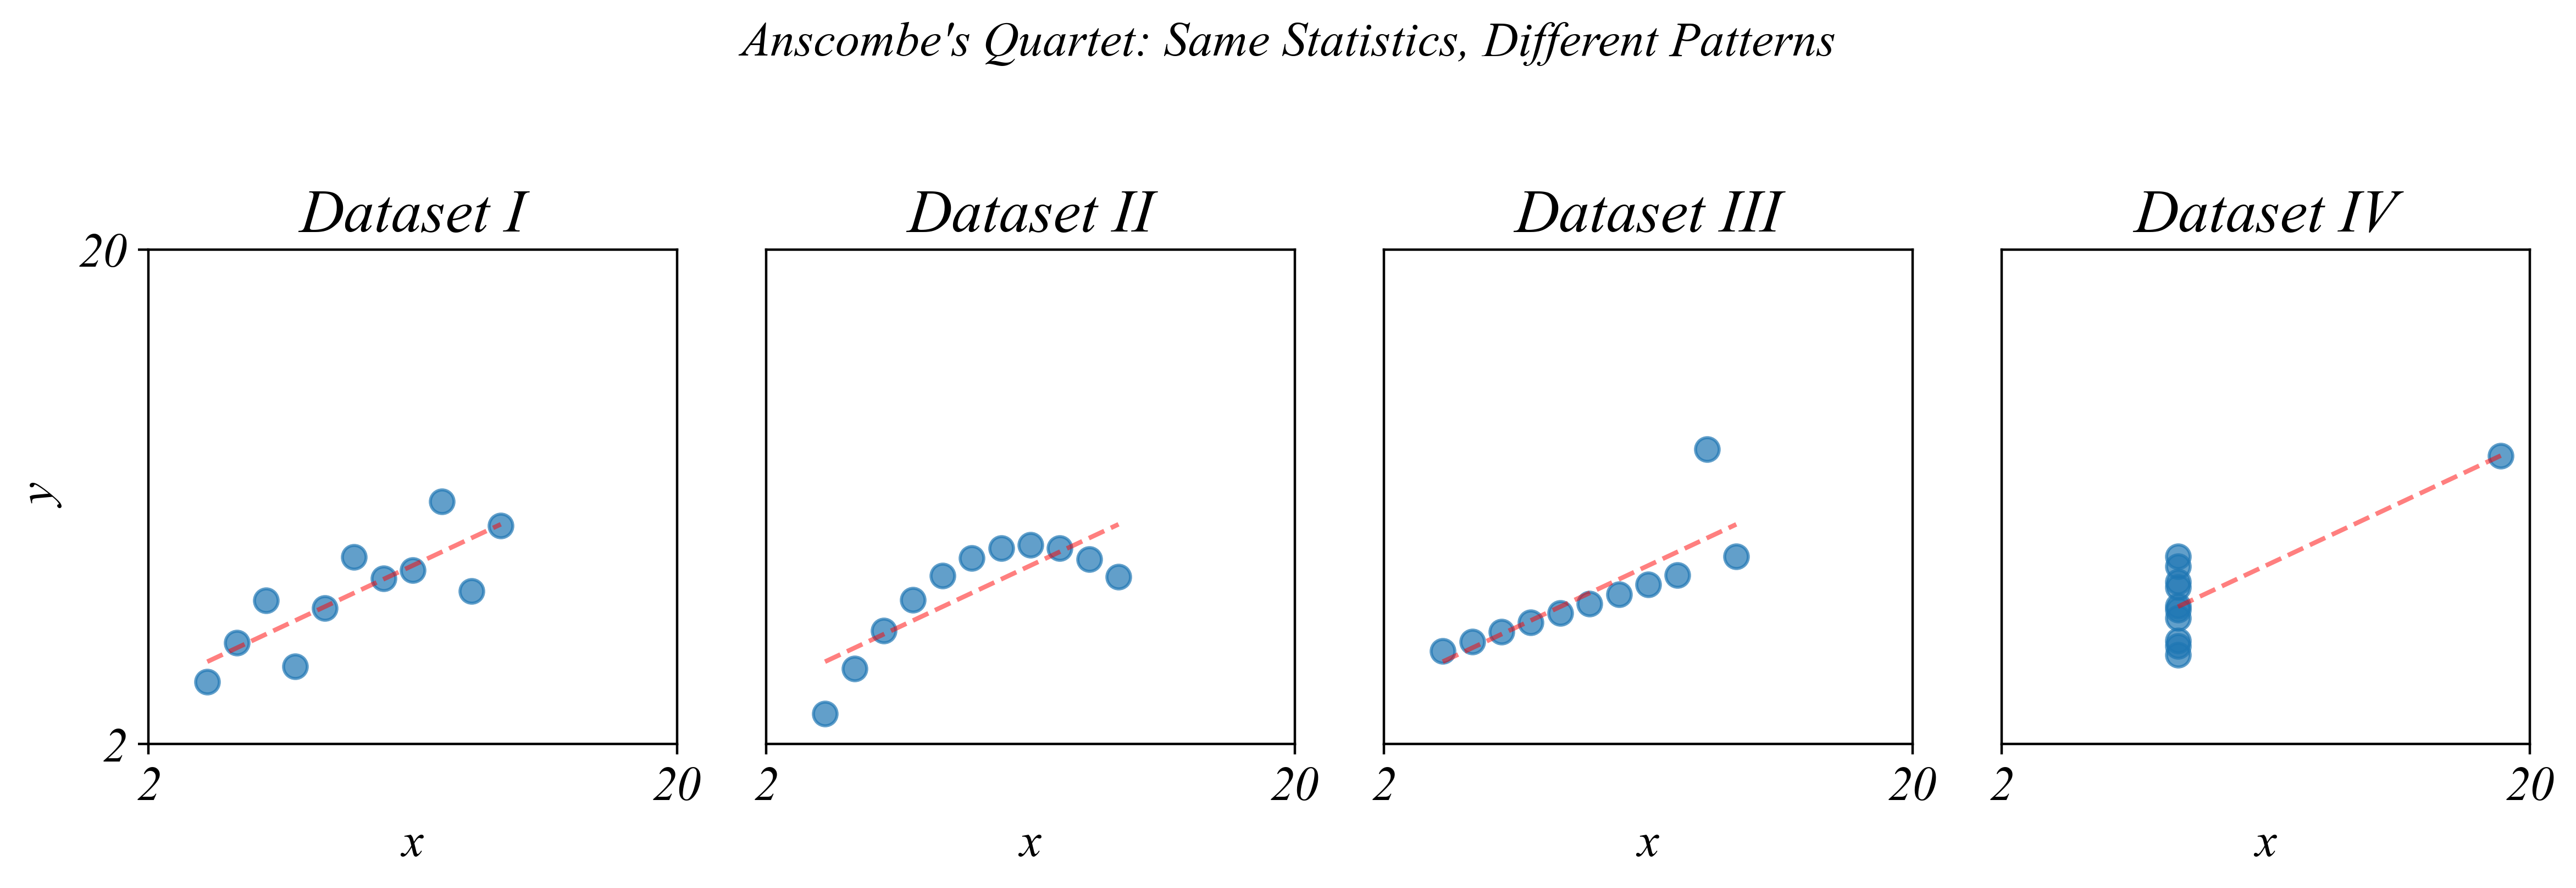

In [4]:
# Figure: 4-panel scatterplot revealing the quartet
anscombe = pd.read_csv('../../data/Anscombes_Quartet.csv')

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
axes = axes.flatten()

titles = ['Dataset I', 'Dataset II', 'Dataset III', 'Dataset IV']
datasets = ['I', 'II', 'III', 'IV']

for ax, dataset, title in zip(axes, datasets, titles):
    d = anscombe[anscombe['dataset'] == dataset]
    ax.scatter(d['x'], d['y'], s=60, alpha=0.7)
    
    # Add regression line
    z = np.polyfit(d['x'], d['y'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(d['x'].min(), d['x'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', alpha=0.5)
    
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 20)
    ax.set_yticks([])
    ax.set_xticks([2,20])
    ax.set_xlabel('x')
    ax.set_title(title)
    ax.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
axes[0].set_ylabel('y')
axes[0].set_yticks([2,20])

plt.suptitle("Anscombe's Quartet: Same Statistics, Different Patterns", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('i/a_02.png', bbox_inches='tight', dpi=300)

## GDP and Coffee Production

#### Data

In [5]:
beans = pd.read_csv('data/Coffee_Bean_Production.csv')
beans = beans.drop(columns=['Entity'])

gdp = pd.read_csv('../../data/GDP.csv')
gdp = gdp.rename(columns={'GDP (output, multiple price benchmarks)': 'GDP'})

data = pd.merge(beans, gdp, on=['Code', 'Year'], how='inner')
data['GDP'] = data['GDP']/1_000_000_000_000
data['coffee_prod'] = data['coffee_prod']/1000000
data = data[data.Entity != 'World']
data = data[data.coffee_prod > 0.01]
data = data[data.GDP < 9]
data.to_csv('../../data/Beans_GDP.csv')

subdata = data[data['Year'] == 2019]
subdata.to_csv('../../data/Beans_GDP_2019.csv')

subdata = data[data['Year'] == 1980]
subdata.to_csv('../../data/Beans_GDP_1980_raw.csv')

#### Figures

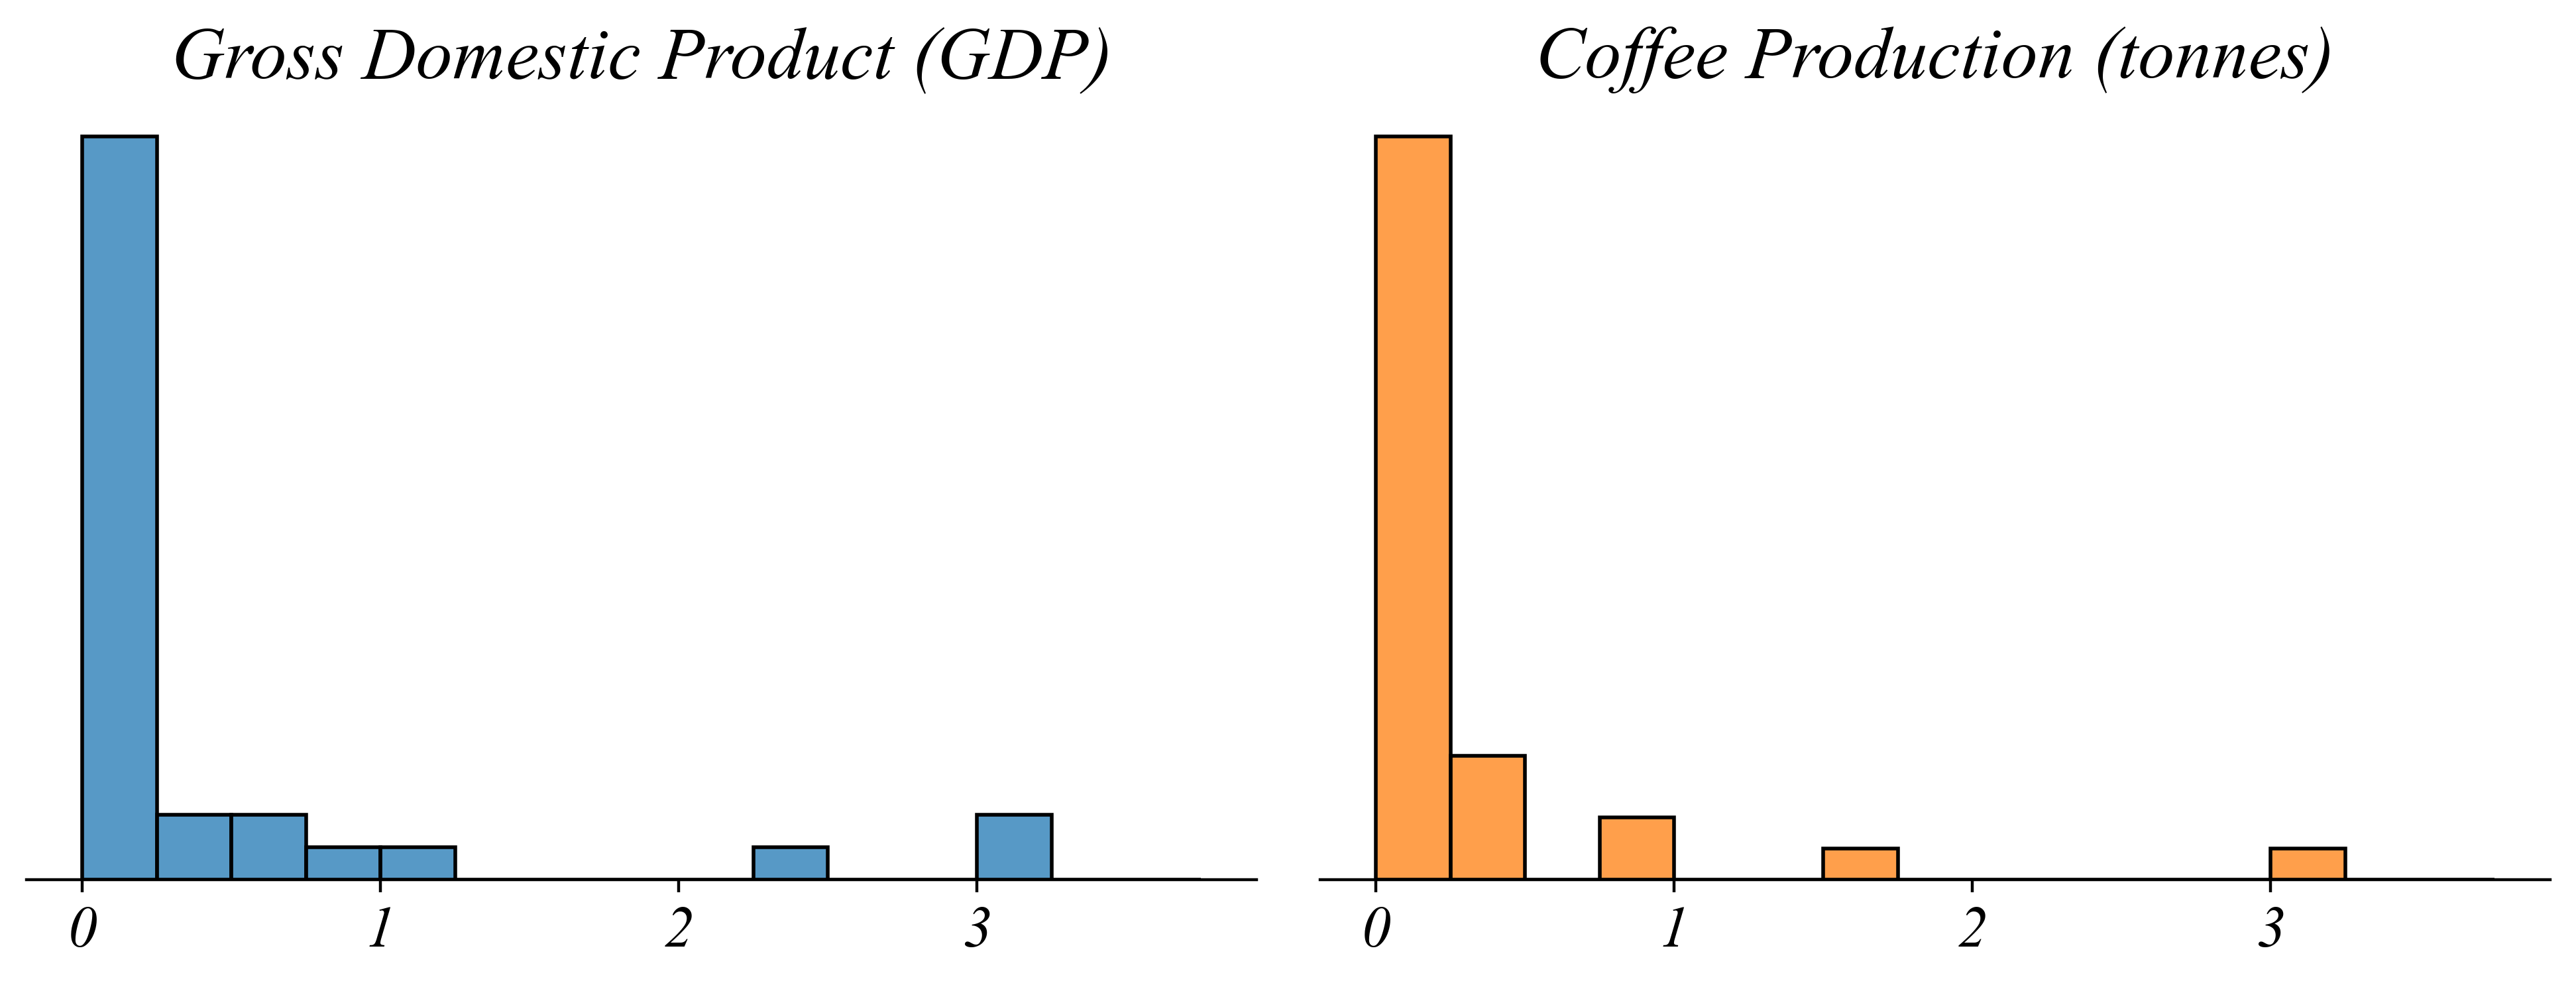

In [6]:
import numpy as np

# Load Dataset
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
bins = np.arange(0, 4, 1/4)

# Figure and Styling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(data, x='GDP', bins=bins, color='C0', ax=ax1)
ax1.set_xlabel('')
ax1.set_yticks([])
ax1.set_ylabel('')
ax1.set_title('Gross Domestic Product (GDP)')
sns.despine(ax=ax1, left=True)

sns.histplot(data, x='coffee_prod', bins=bins, color='C1', ax=ax2)
ax2.set_xlabel('')
ax2.set_yticks([])
ax2.set_ylabel('')
ax2.set_title('Coffee Production (tonnes)')
sns.despine(ax=ax2, left=True)

plt.tight_layout()

# Save Figure
plt.savefig('i/c_01.png')

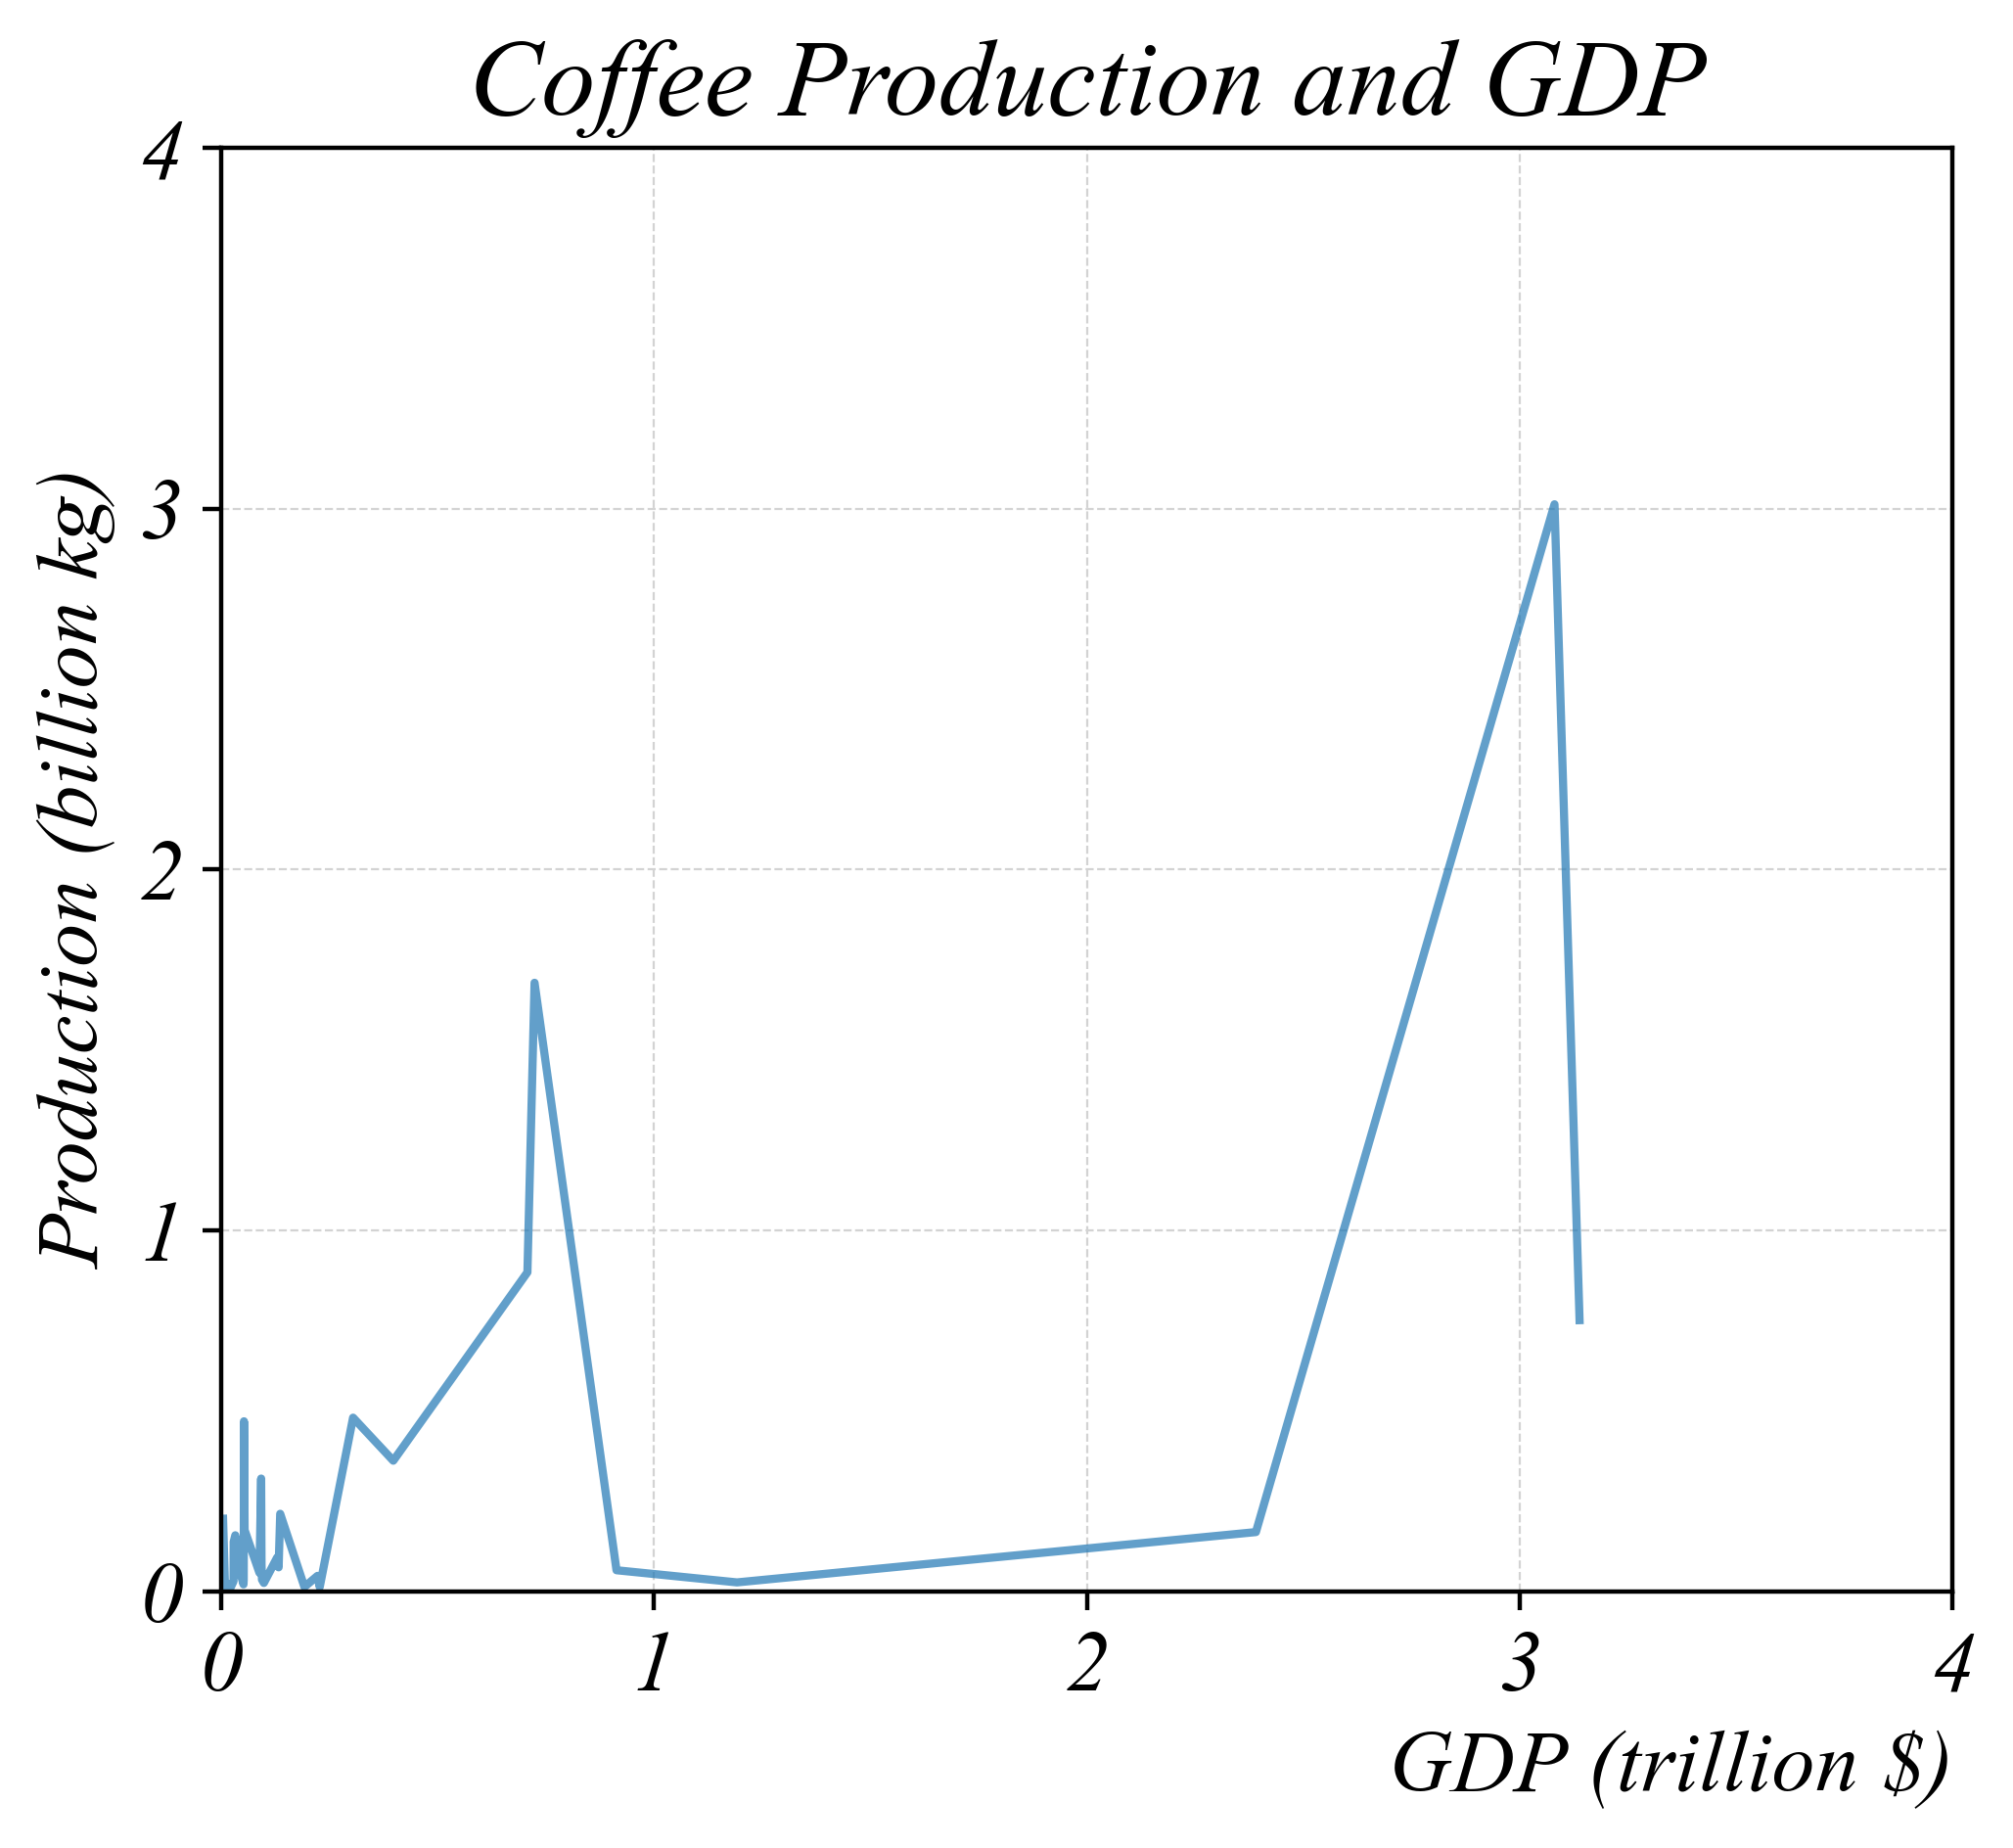

In [7]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.lineplot(data, x='GDP', y='coffee_prod', alpha=0.7)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_02.png')

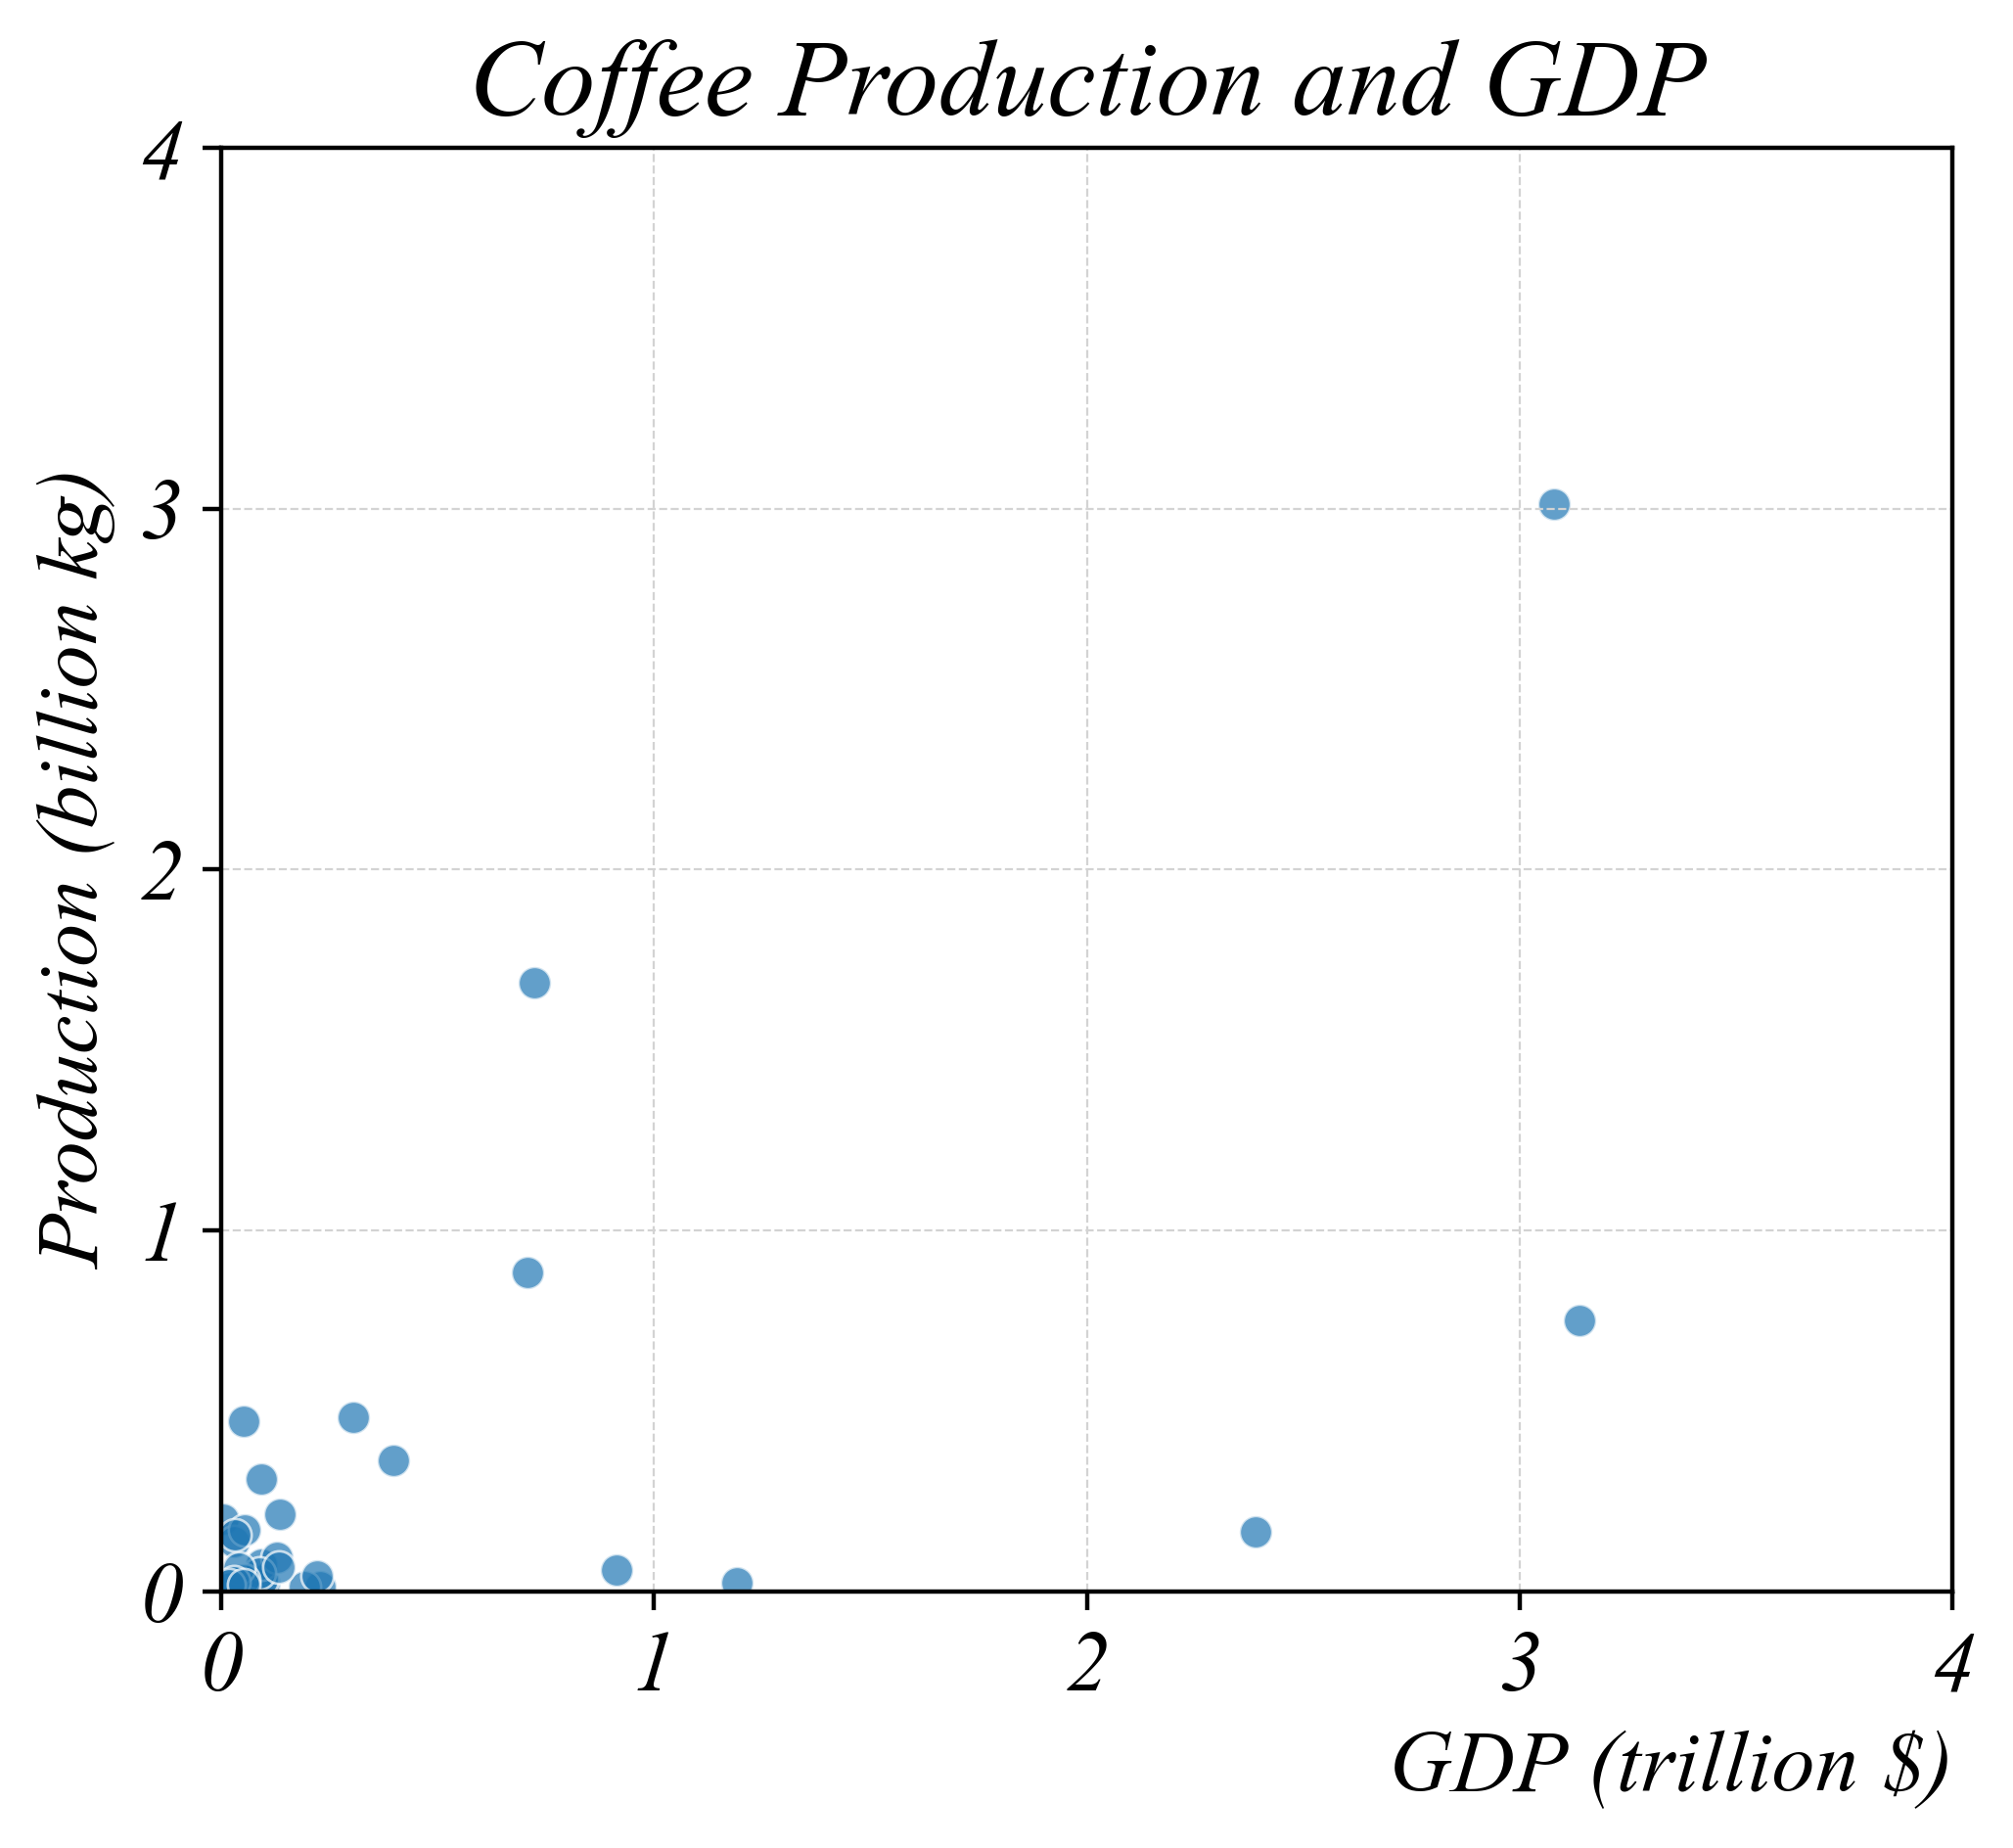

In [8]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='GDP', y='coffee_prod', alpha=0.7)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_03.png')

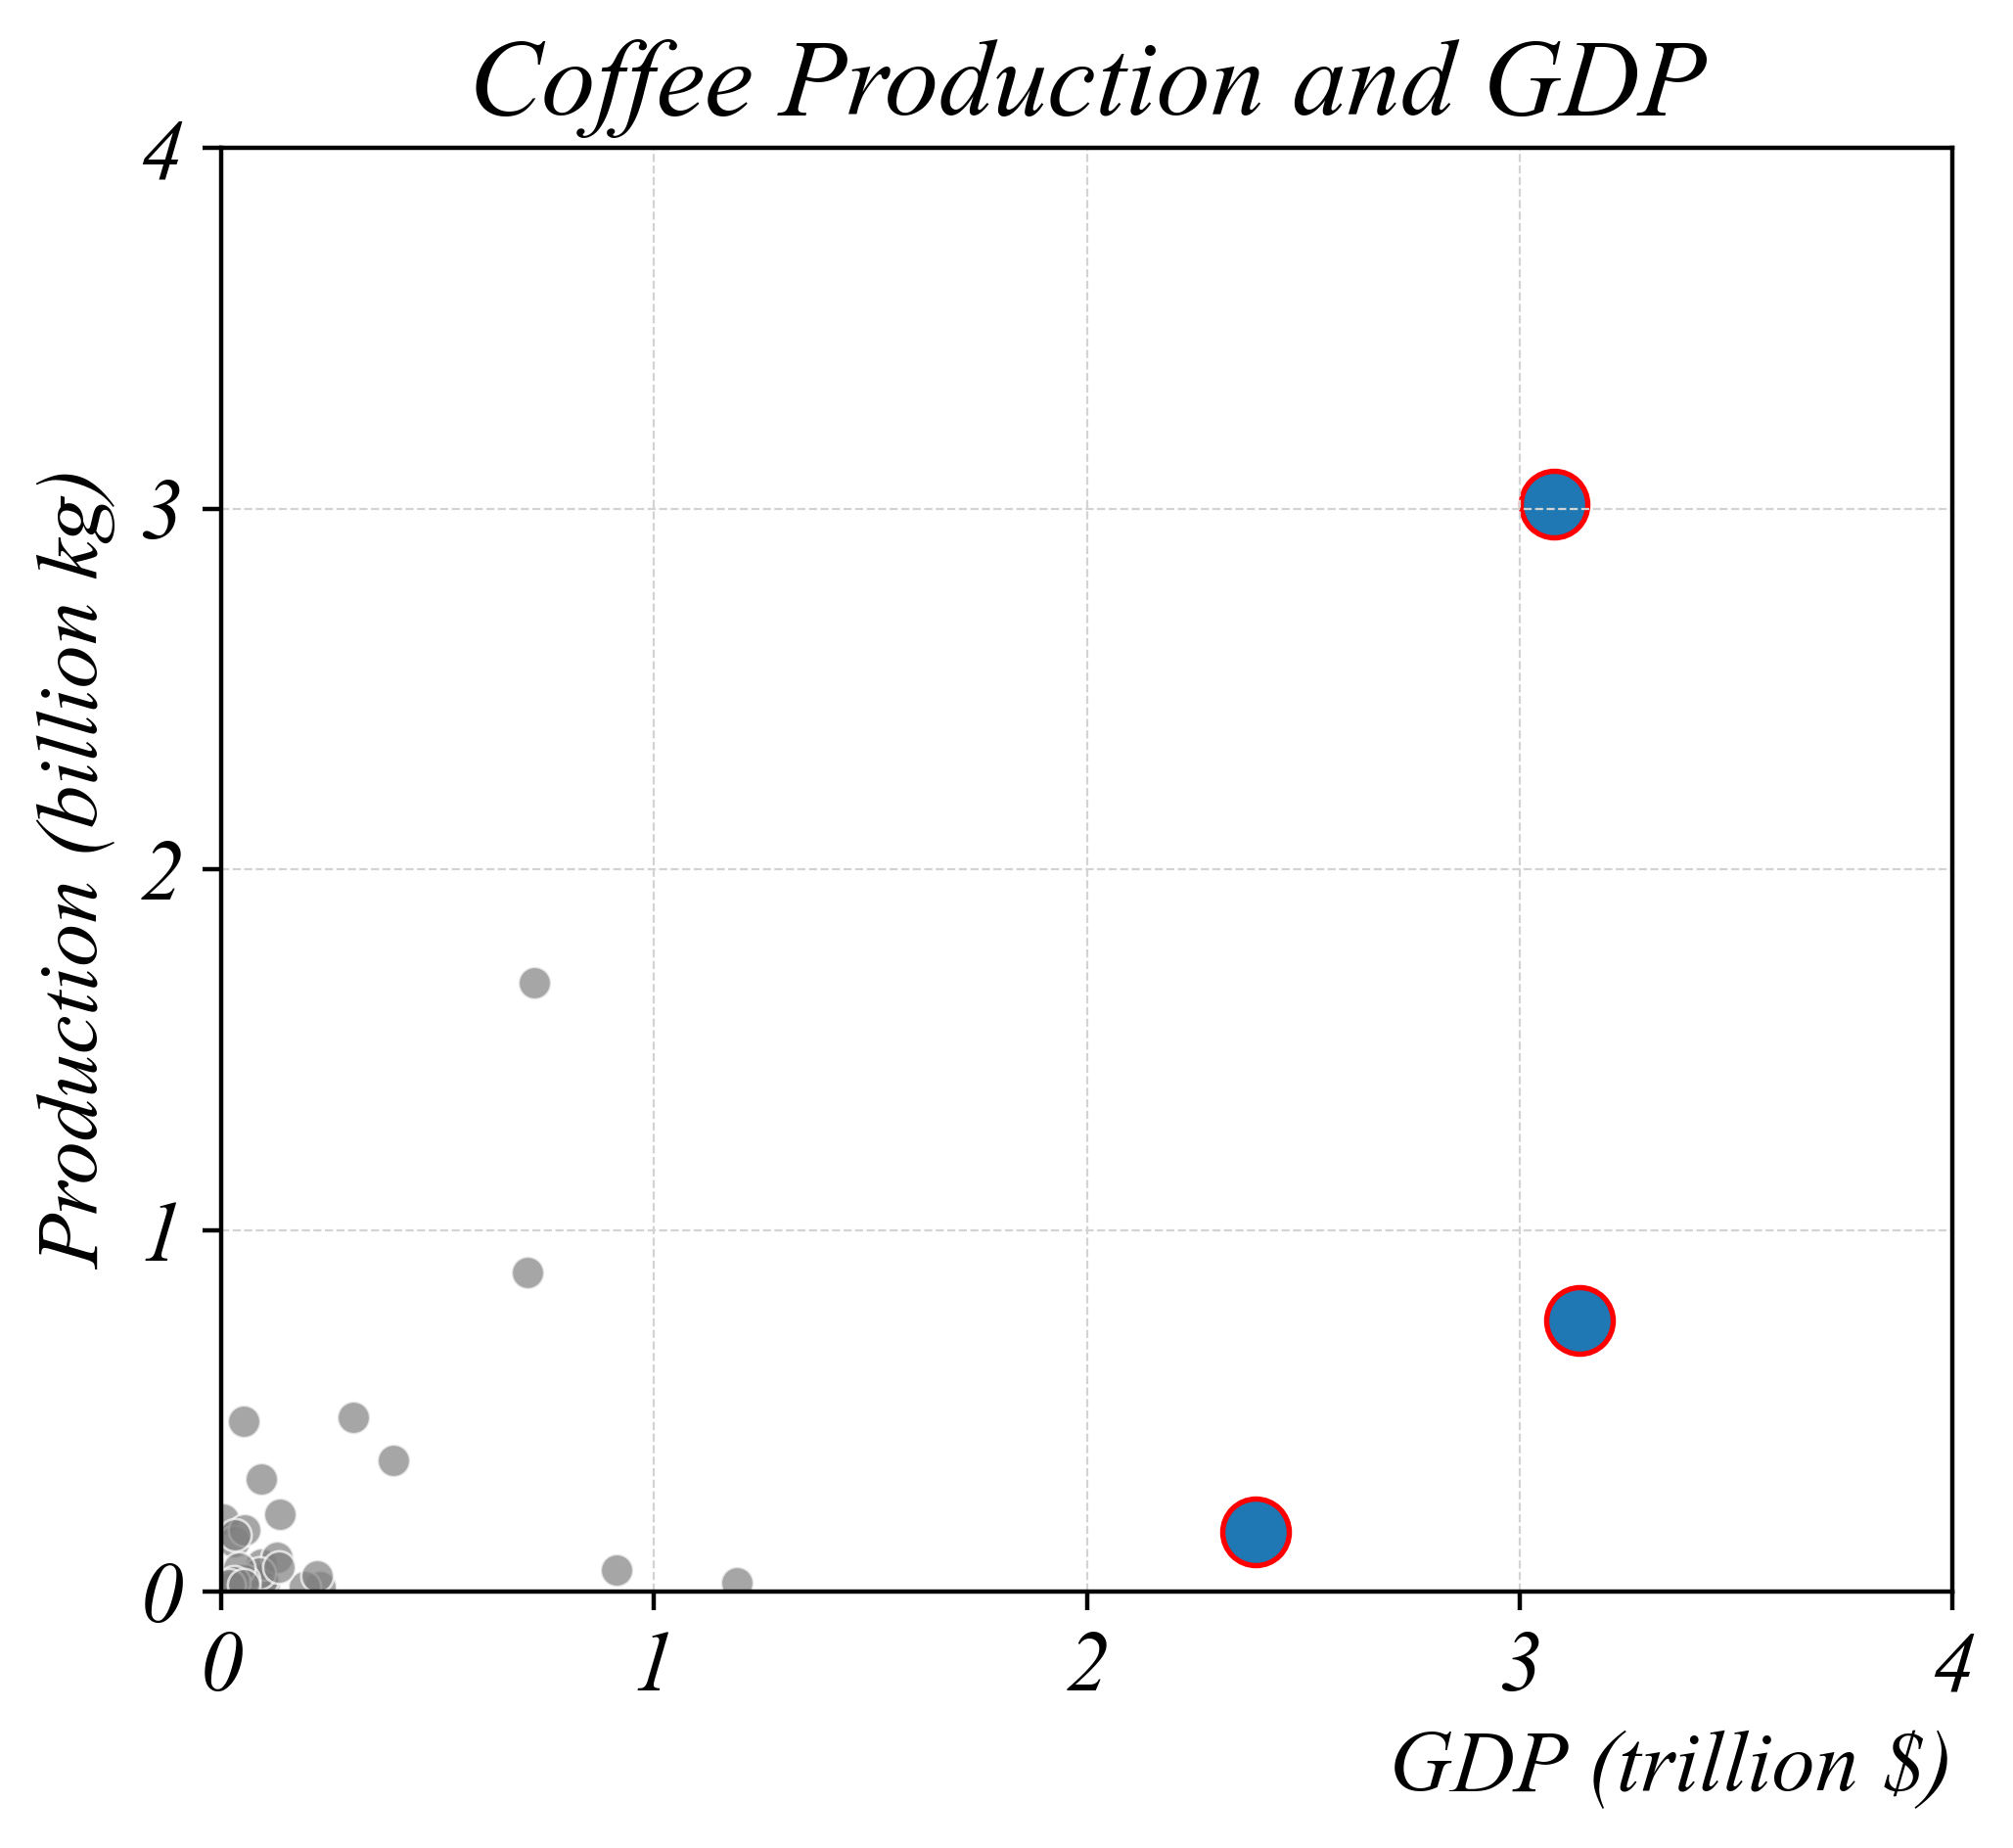

In [9]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
high_gdp = data[data.GDP > 2]
ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='GDP', y='coffee_prod', color='grey', alpha=0.7)
sns.scatterplot(high_gdp, x='GDP', y='coffee_prod', edgecolors='red', alpha=1, s=150)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_04.png')

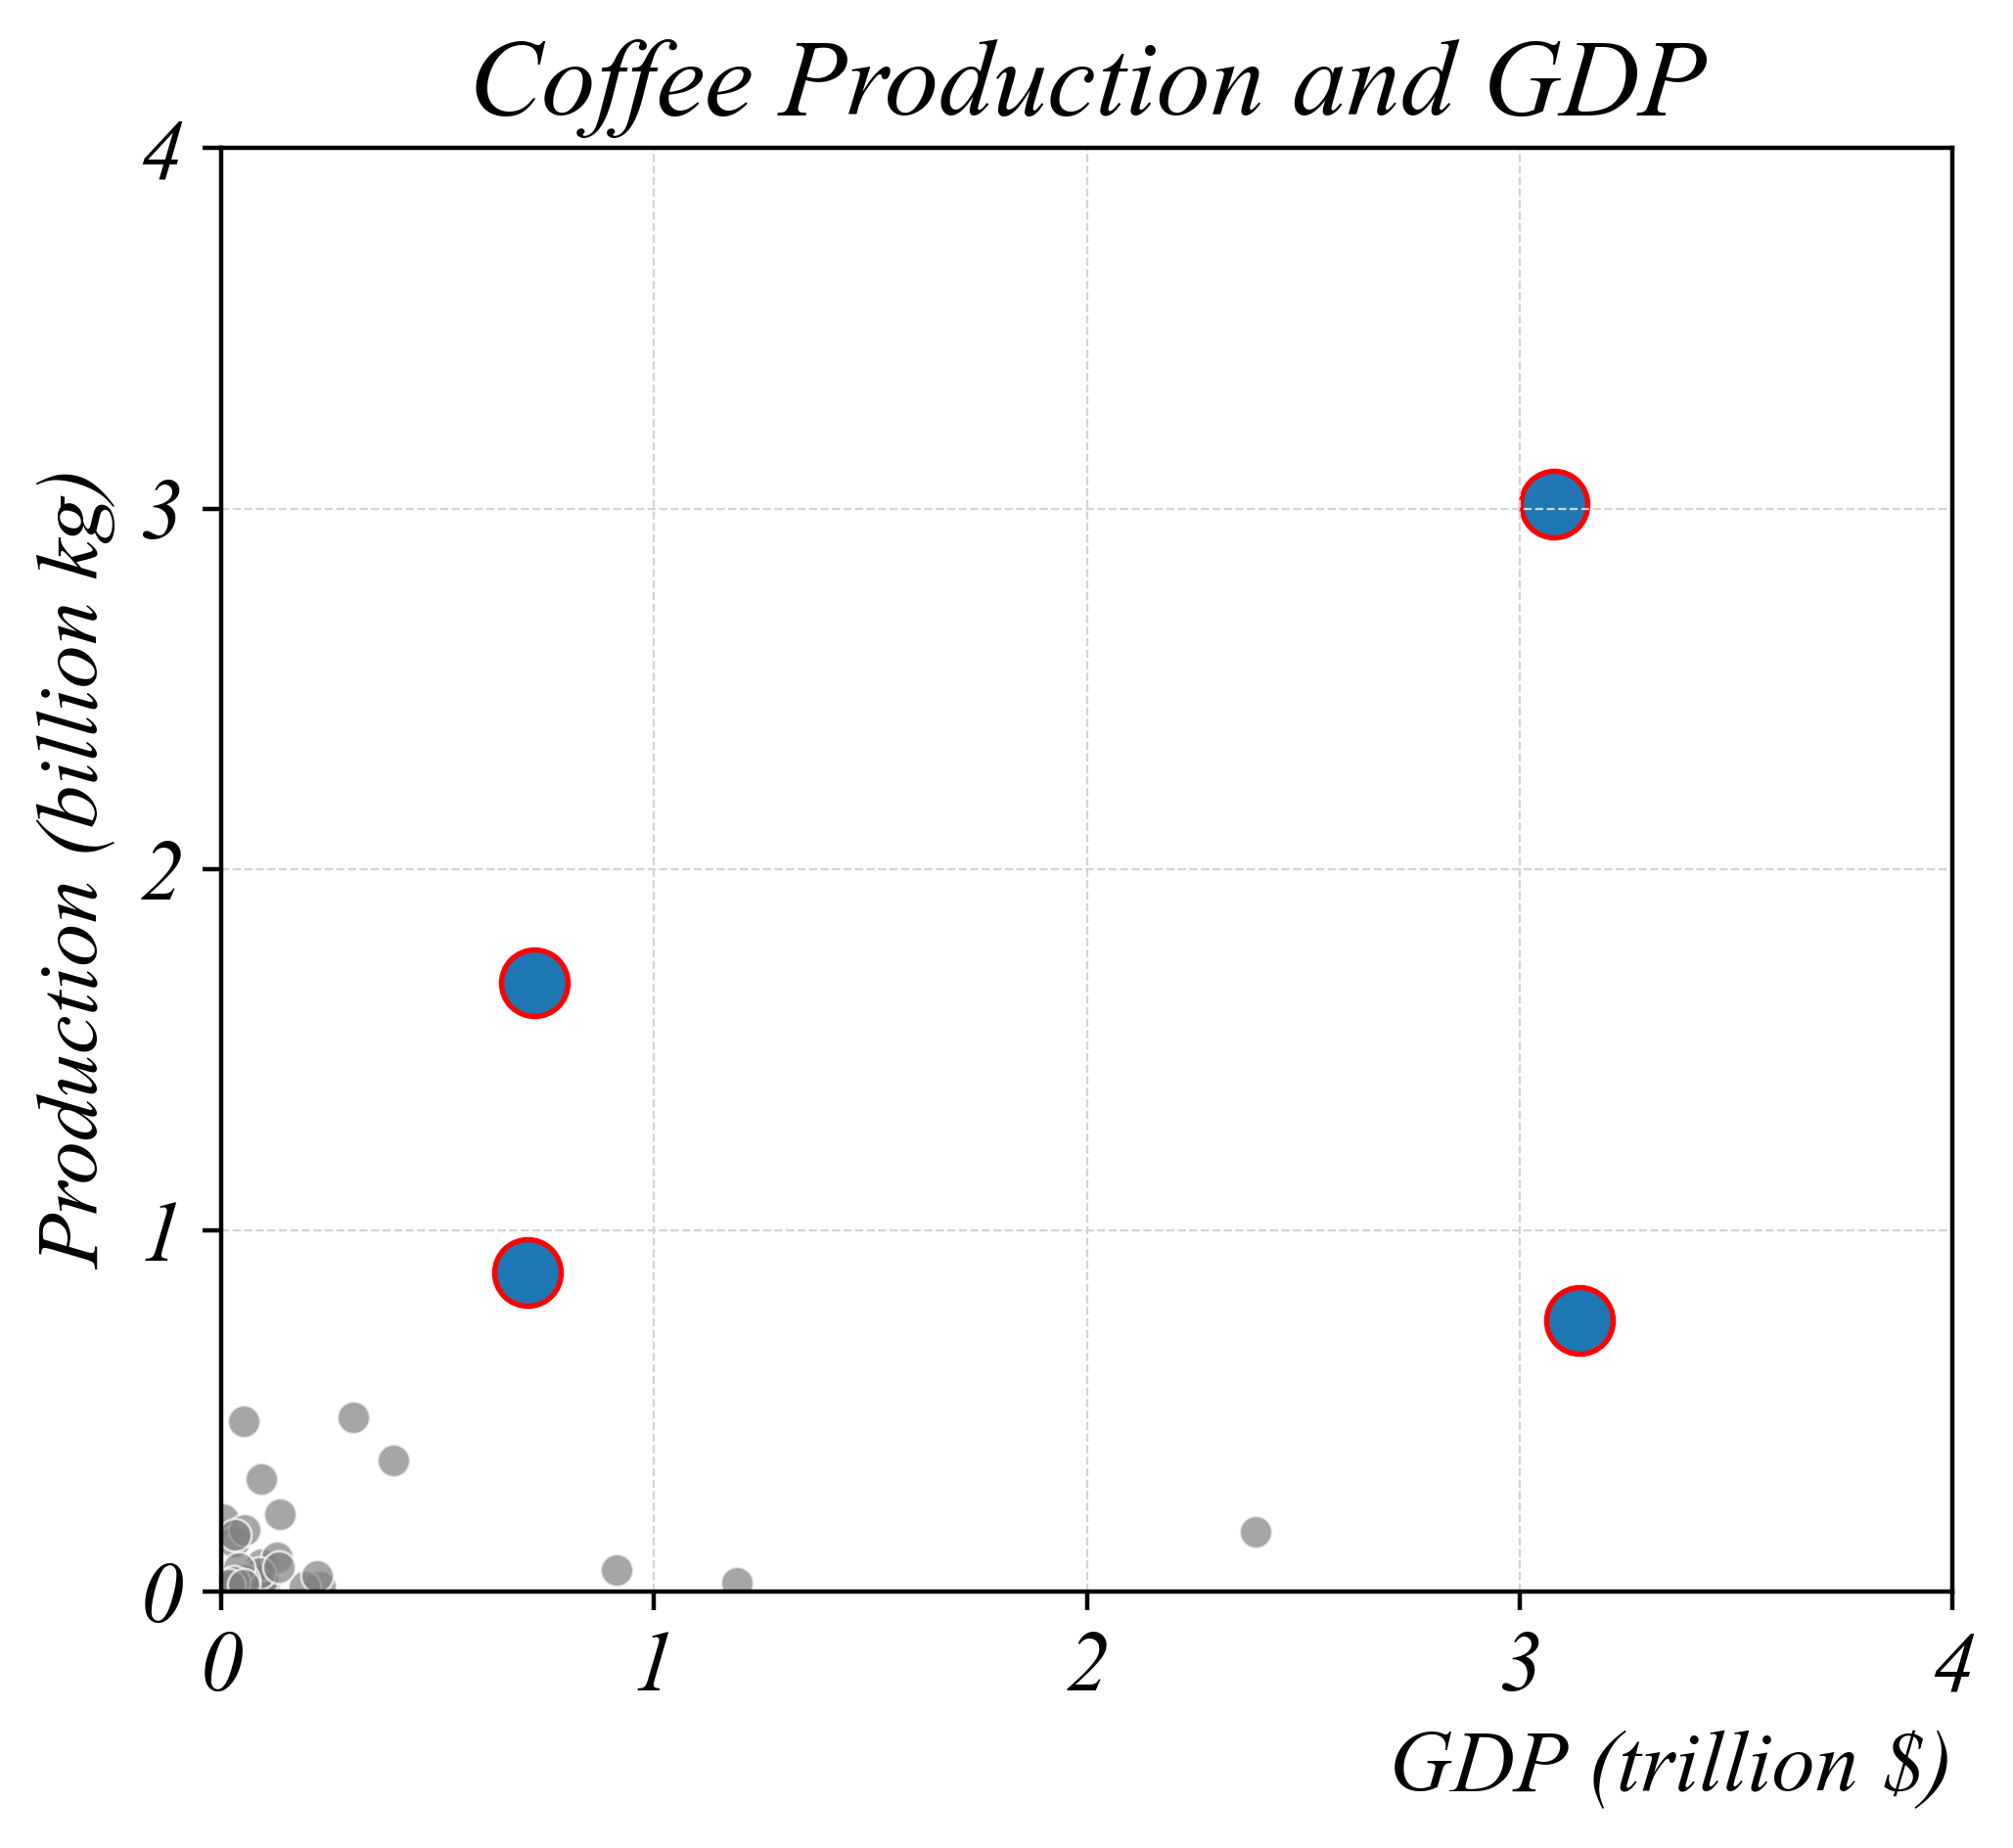

In [10]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
high_production = data[data.coffee_prod > 0.5]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='GDP', y='coffee_prod', color='grey', alpha=0.7)
sns.scatterplot(high_production, x='GDP', y='coffee_prod', edgecolors='red', alpha=1, s=150)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_05.png')

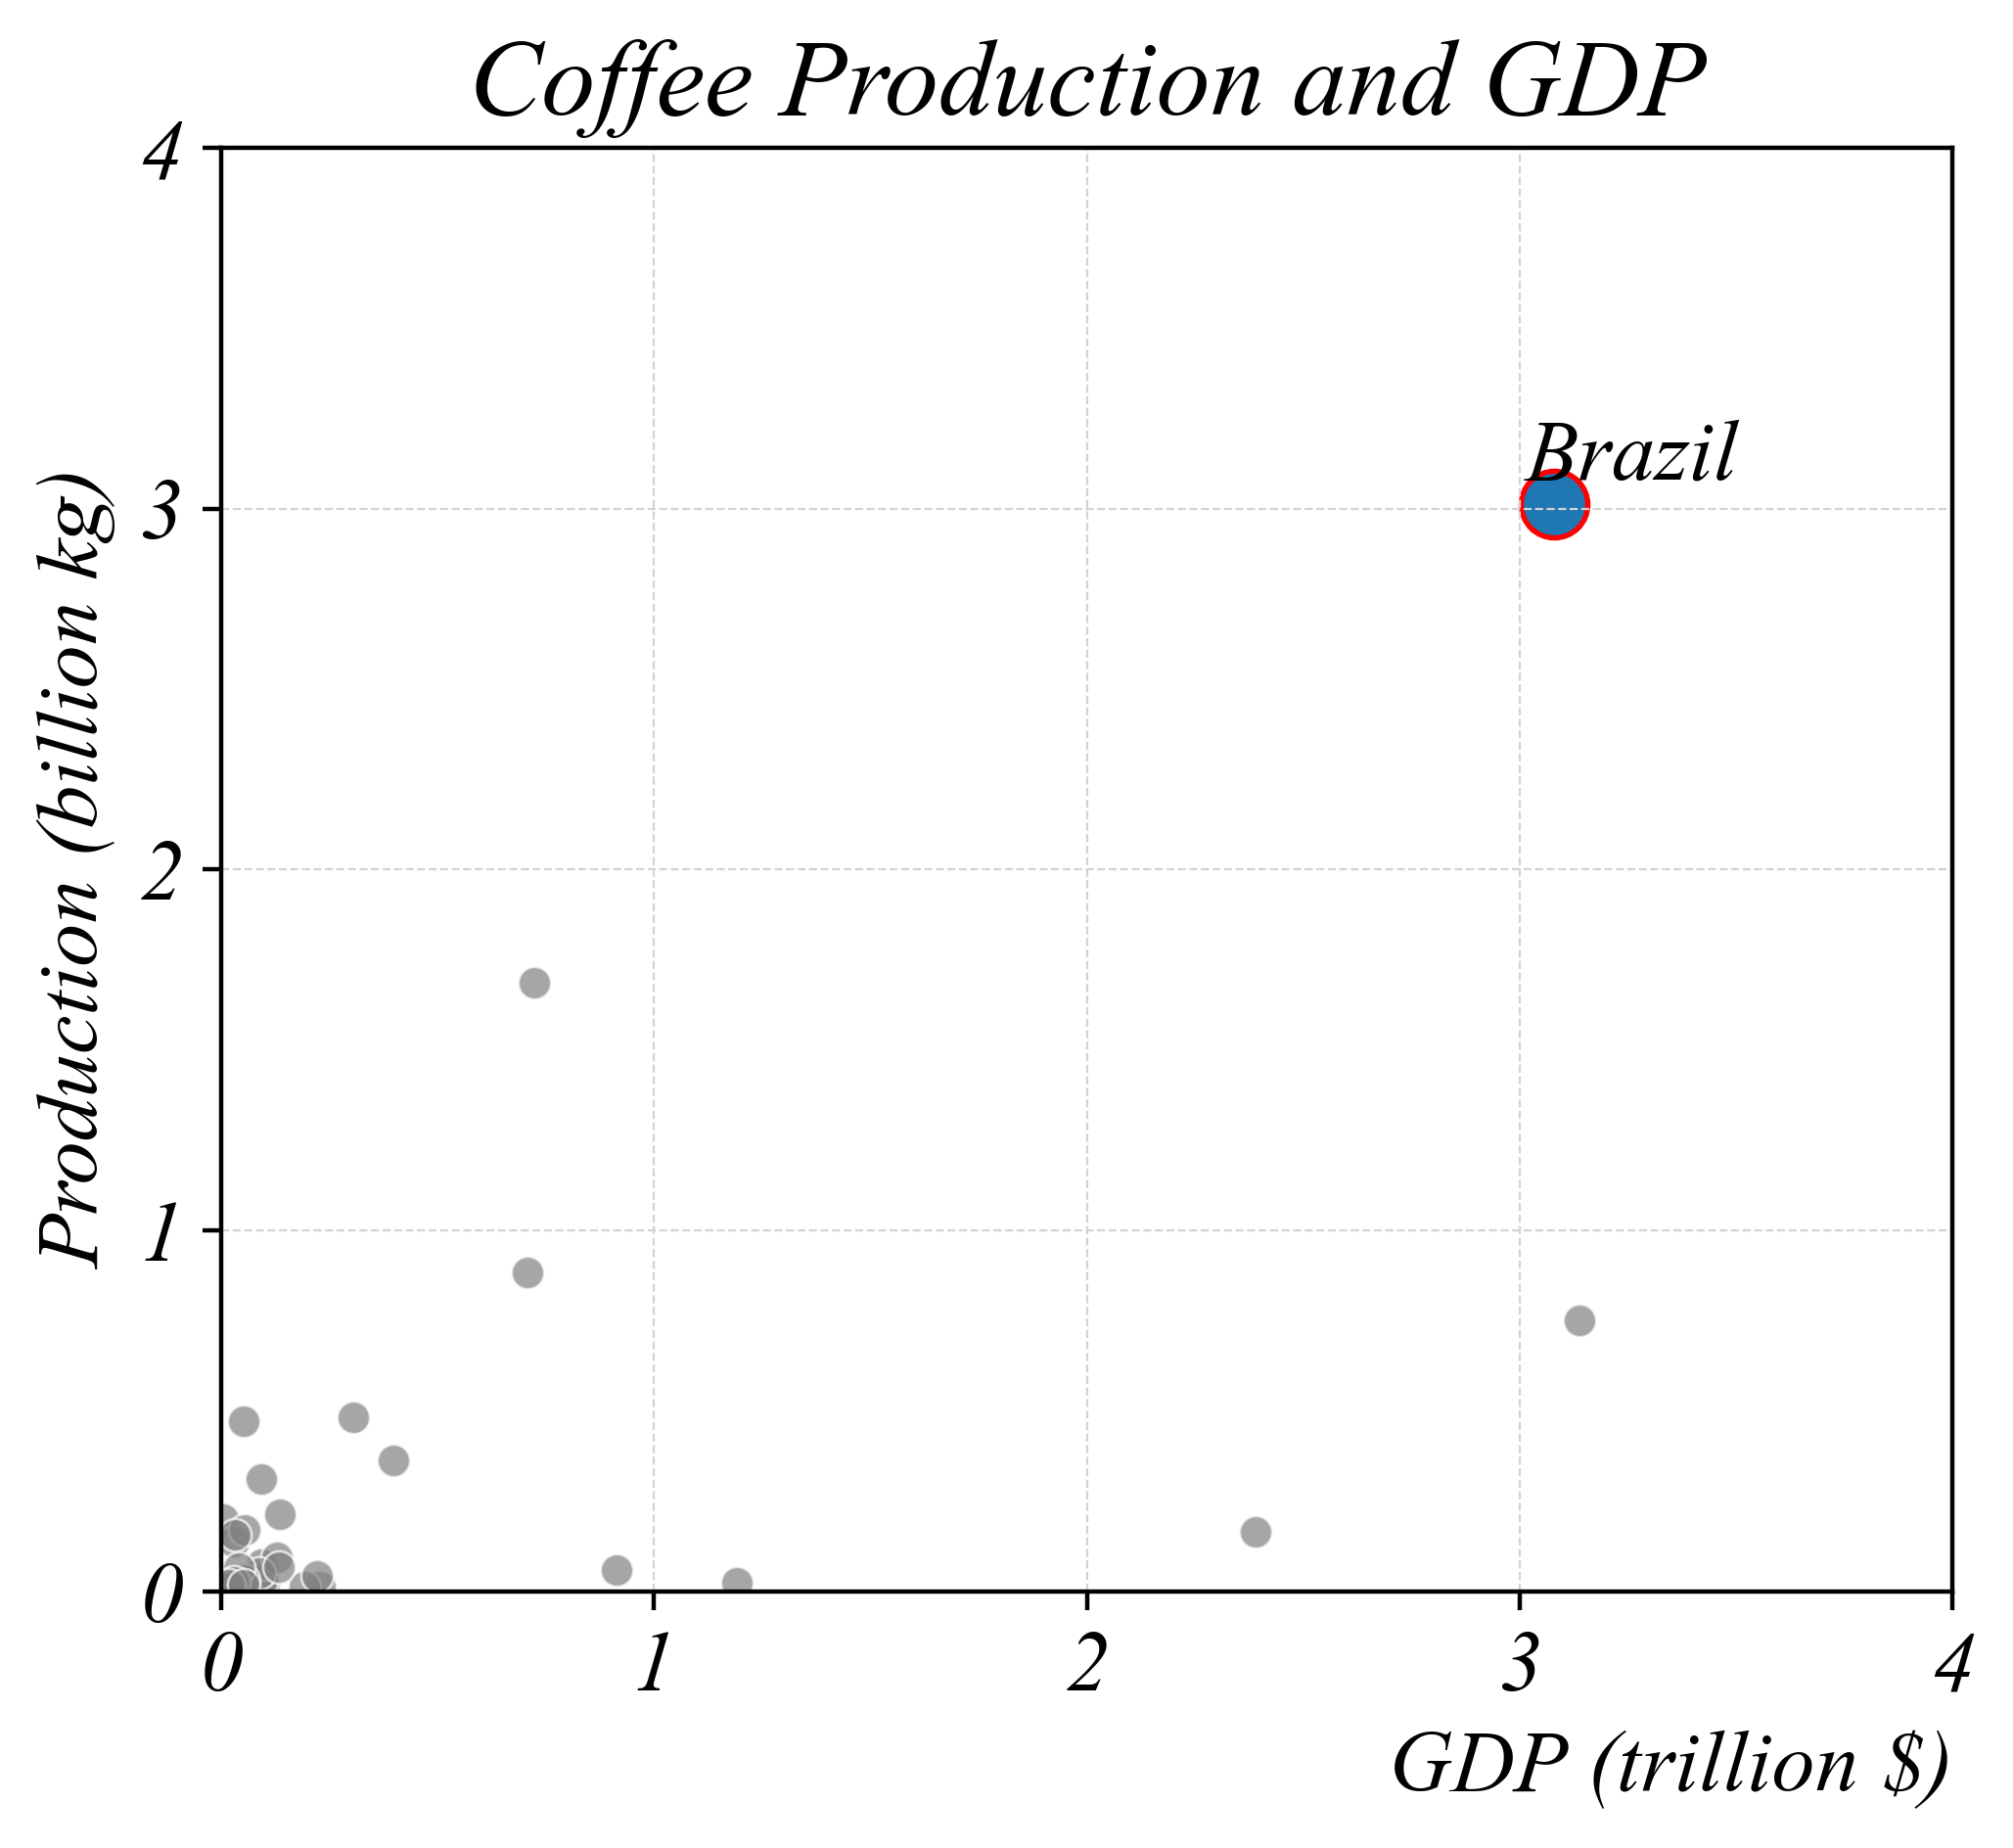

In [11]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
brazil = data[data.coffee_prod == data.coffee_prod.max()]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='GDP', y='coffee_prod', color='grey', alpha=0.7)
sns.scatterplot(brazil, x='GDP', y='coffee_prod', edgecolors='red', alpha=1, s=150)
plt.annotate('Brazil',(brazil.coffee_prod.values[0], brazil.GDP.values[0]))

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_06.png')

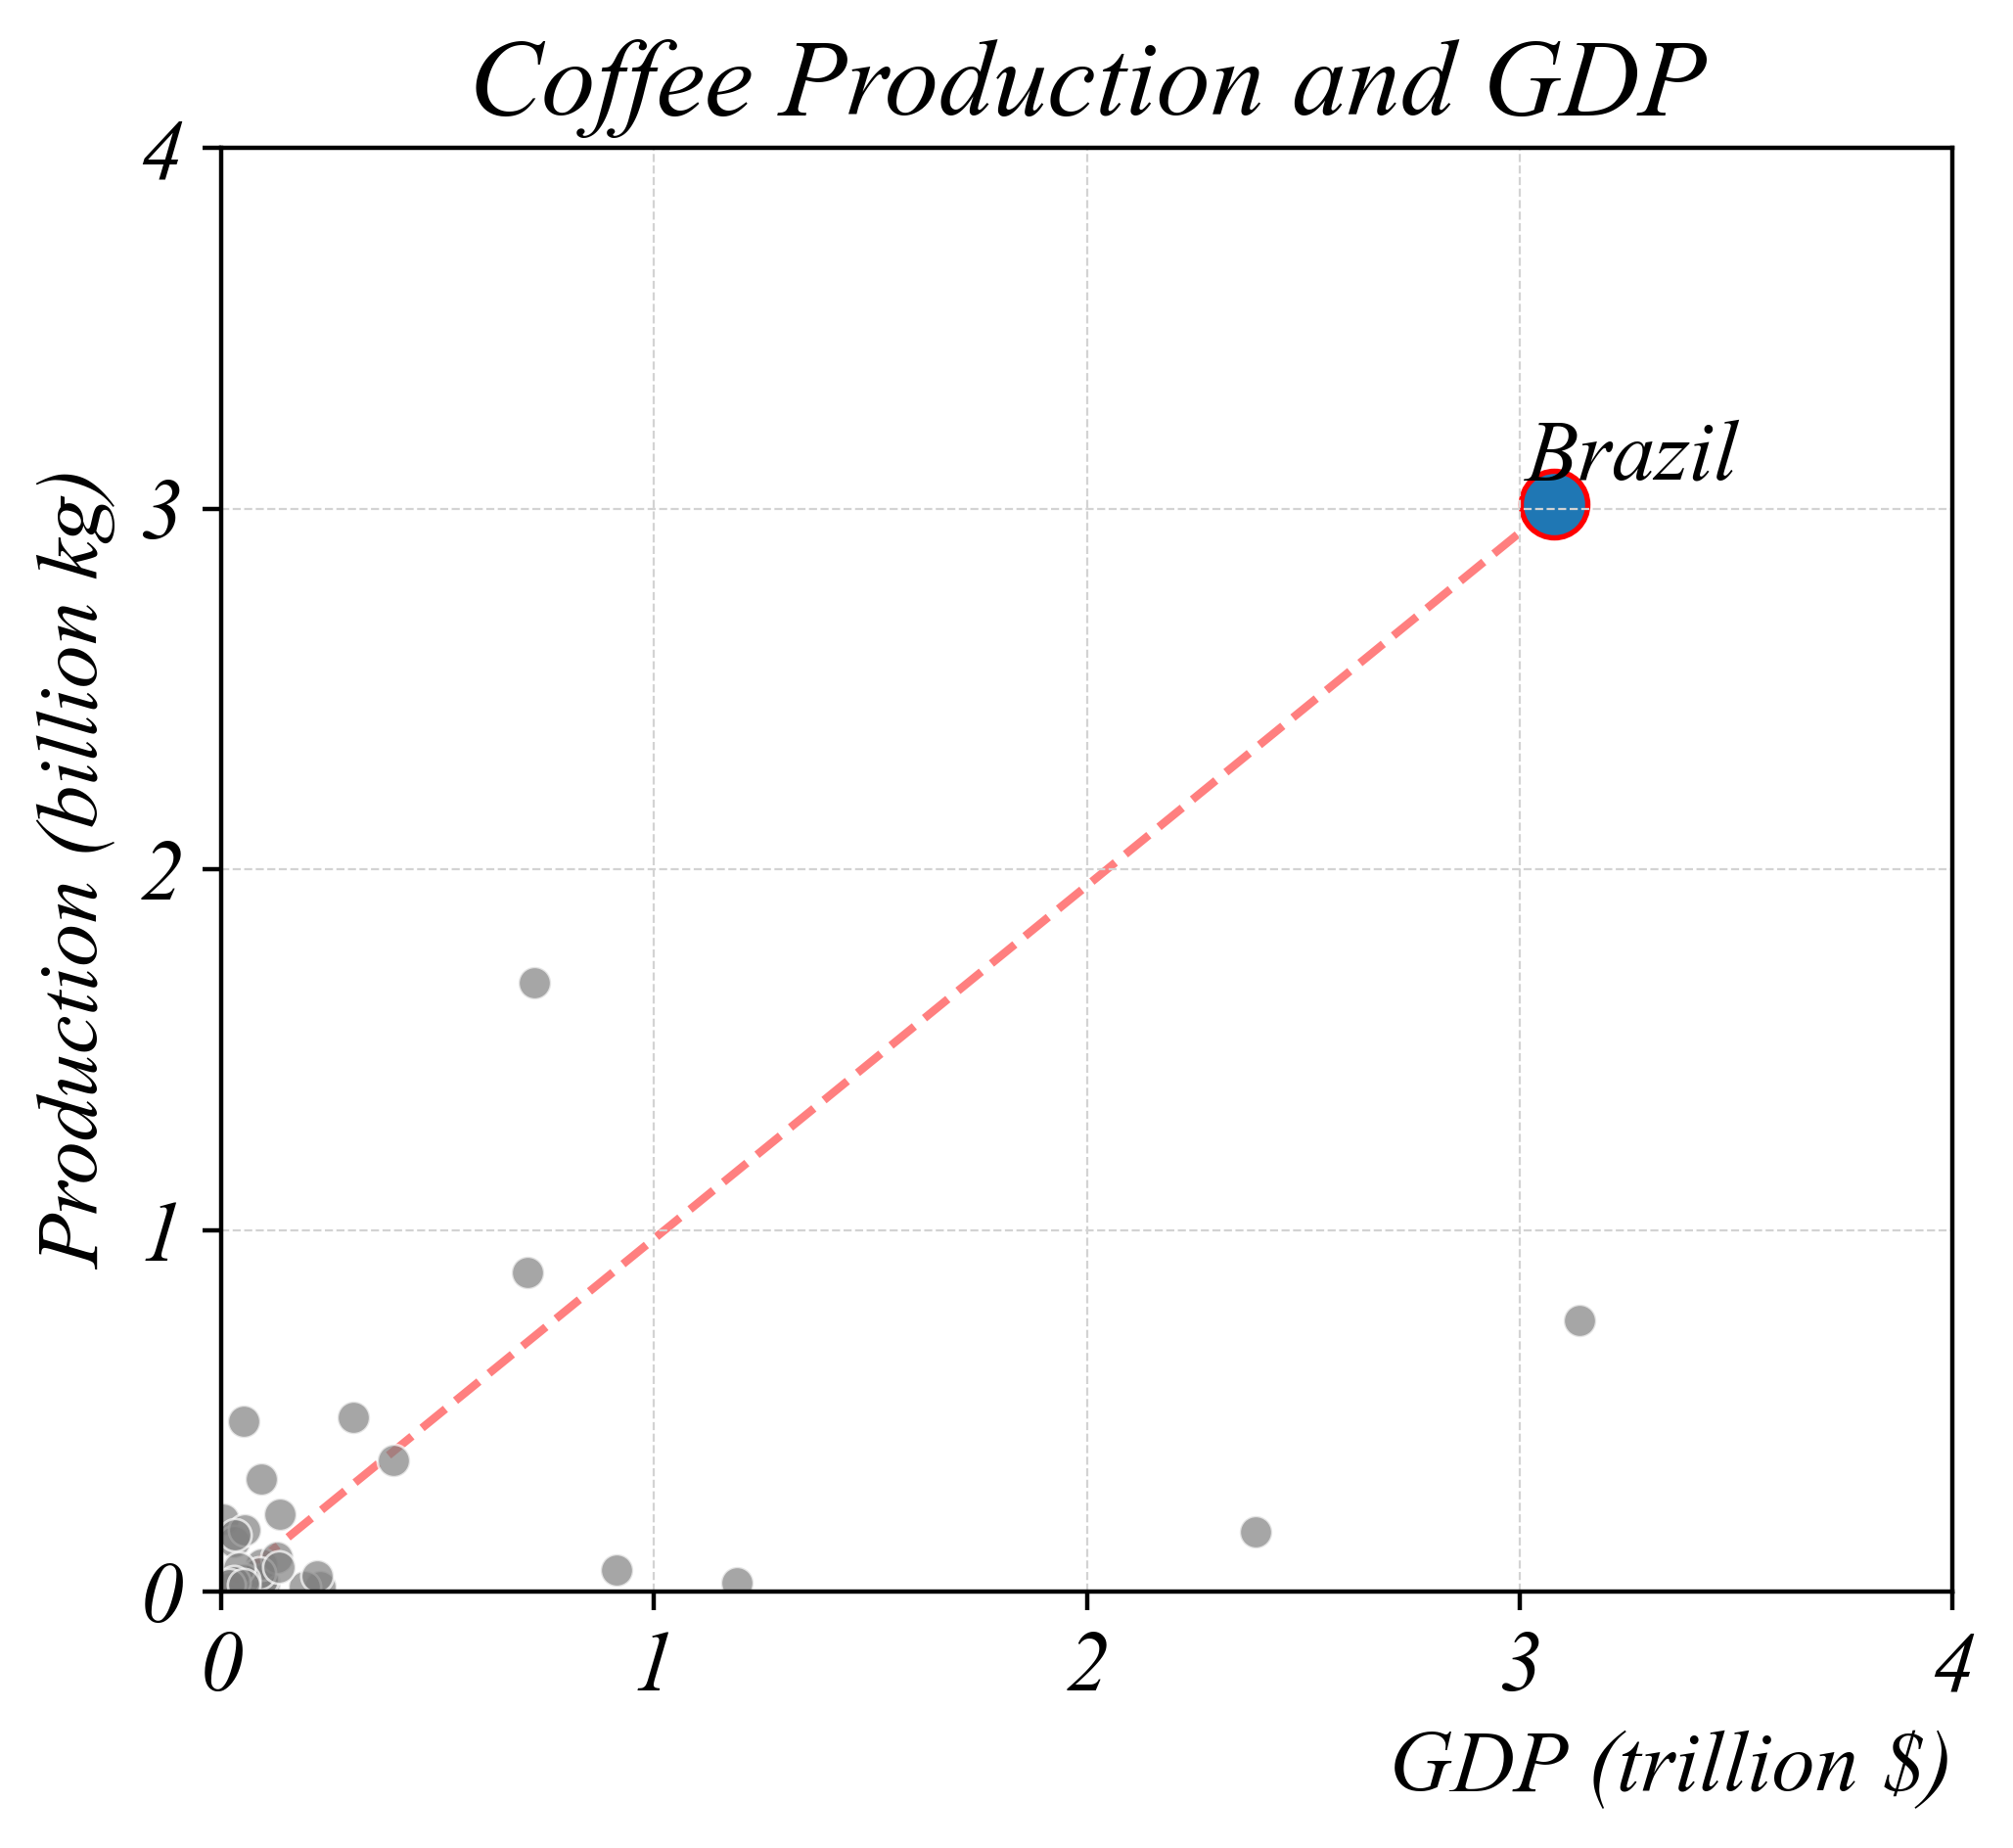

In [12]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
brazil = data[data.coffee_prod == data.coffee_prod.max()]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='GDP', y='coffee_prod', color='grey', alpha=0.7)
sns.scatterplot(brazil, x='GDP', y='coffee_prod', edgecolors='red', alpha=1, s=150)

# Annotation
plt.annotate('Brazil',(brazil.coffee_prod.values[0], brazil.GDP.values[0]))
plt.plot([0,brazil.GDP.values[0]],[0,brazil.coffee_prod.values[0]], linestyle='--', color='red', zorder=-1, alpha=0.5)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_07.png')

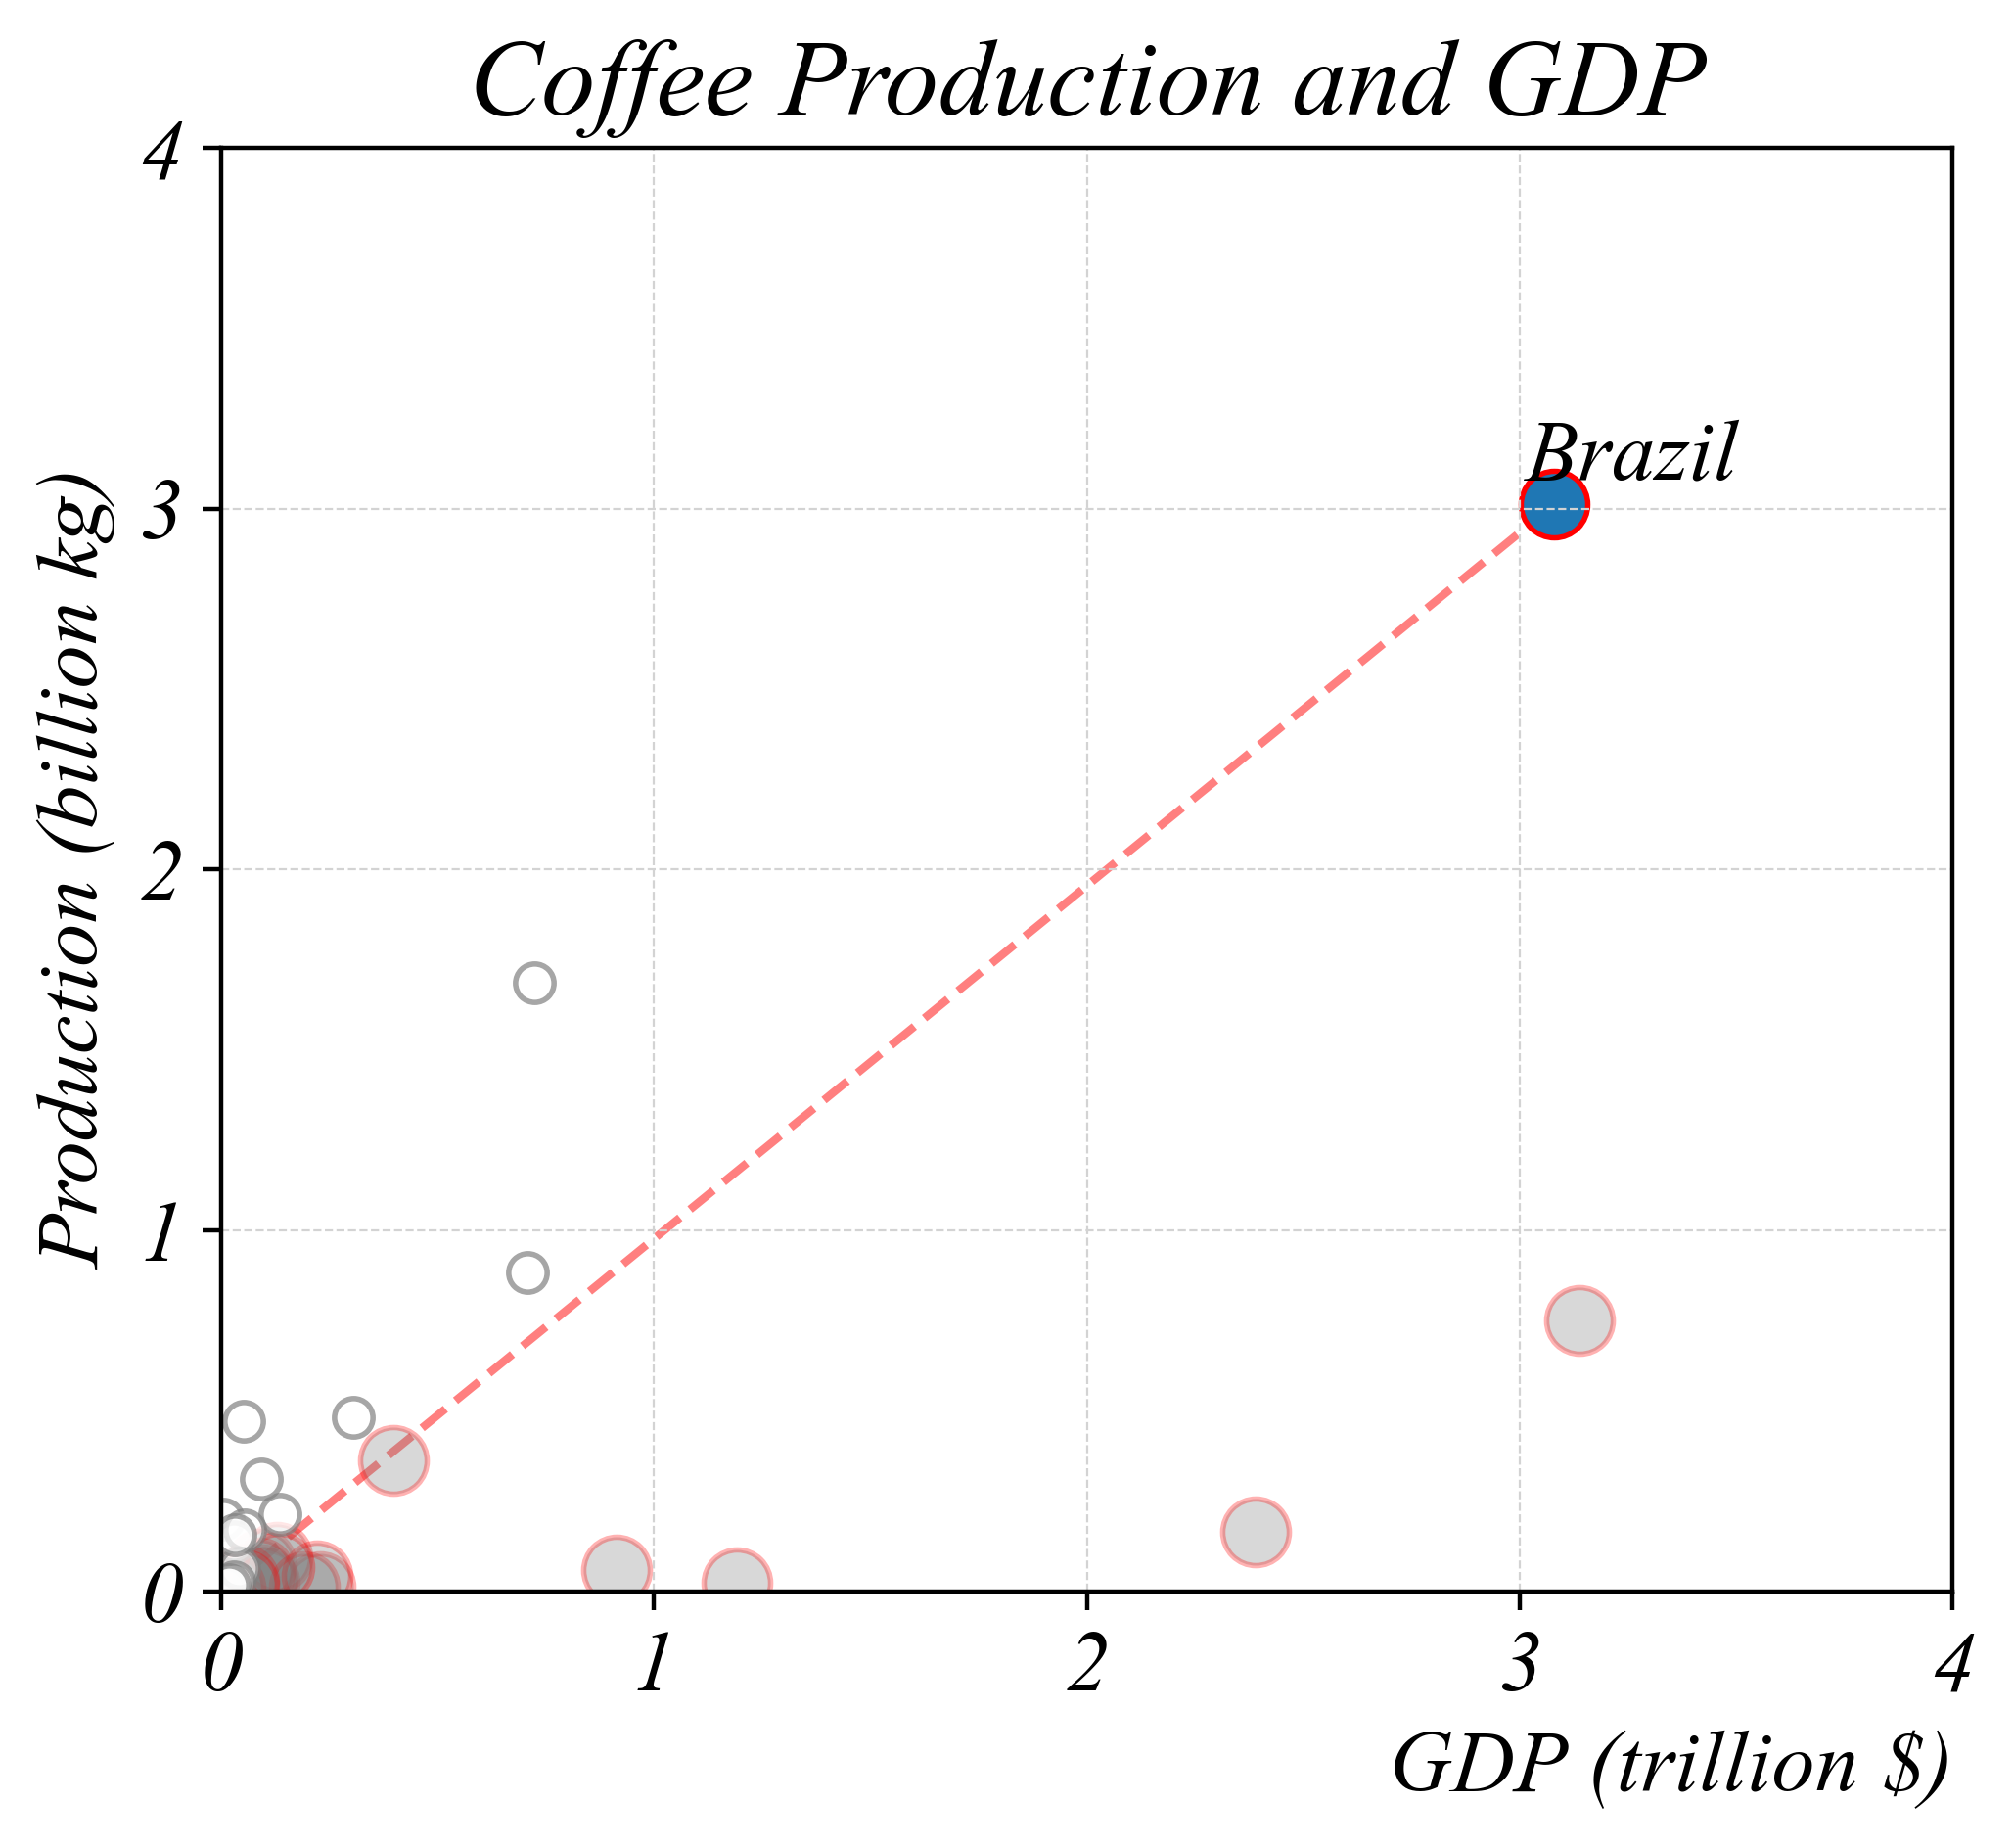

In [13]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['brazil_ratio'] = data['GDP']/data['coffee_prod']

brazil = data[data.coffee_prod == data.coffee_prod.max()]
brazil_gdp = brazil.GDP.values[0]
brazil_tonnes = brazil.coffee_prod.values[0]

greater = data[data['brazil_ratio'] > brazil_gdp/brazil_tonnes]
lower = data[data['brazil_ratio'] < brazil_gdp/brazil_tonnes]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(brazil, x='GDP', y='coffee_prod', edgecolors='red', alpha=1, s=150)
plt.scatter(greater['GDP'], greater['coffee_prod'], color='grey', edgecolors='red', alpha=0.3, s=150)
plt.scatter(lower['GDP'], lower['coffee_prod'], color='white', edgecolors='grey', alpha=0.7, s=50)

# Annotation
plt.annotate('Brazil',(brazil.coffee_prod.values[0], brazil.GDP.values[0]))
plt.plot([0,brazil.GDP.values[0]],[0,brazil.coffee_prod.values[0]], linestyle='--', color='red', zorder=-1, alpha=0.5)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_08.png')

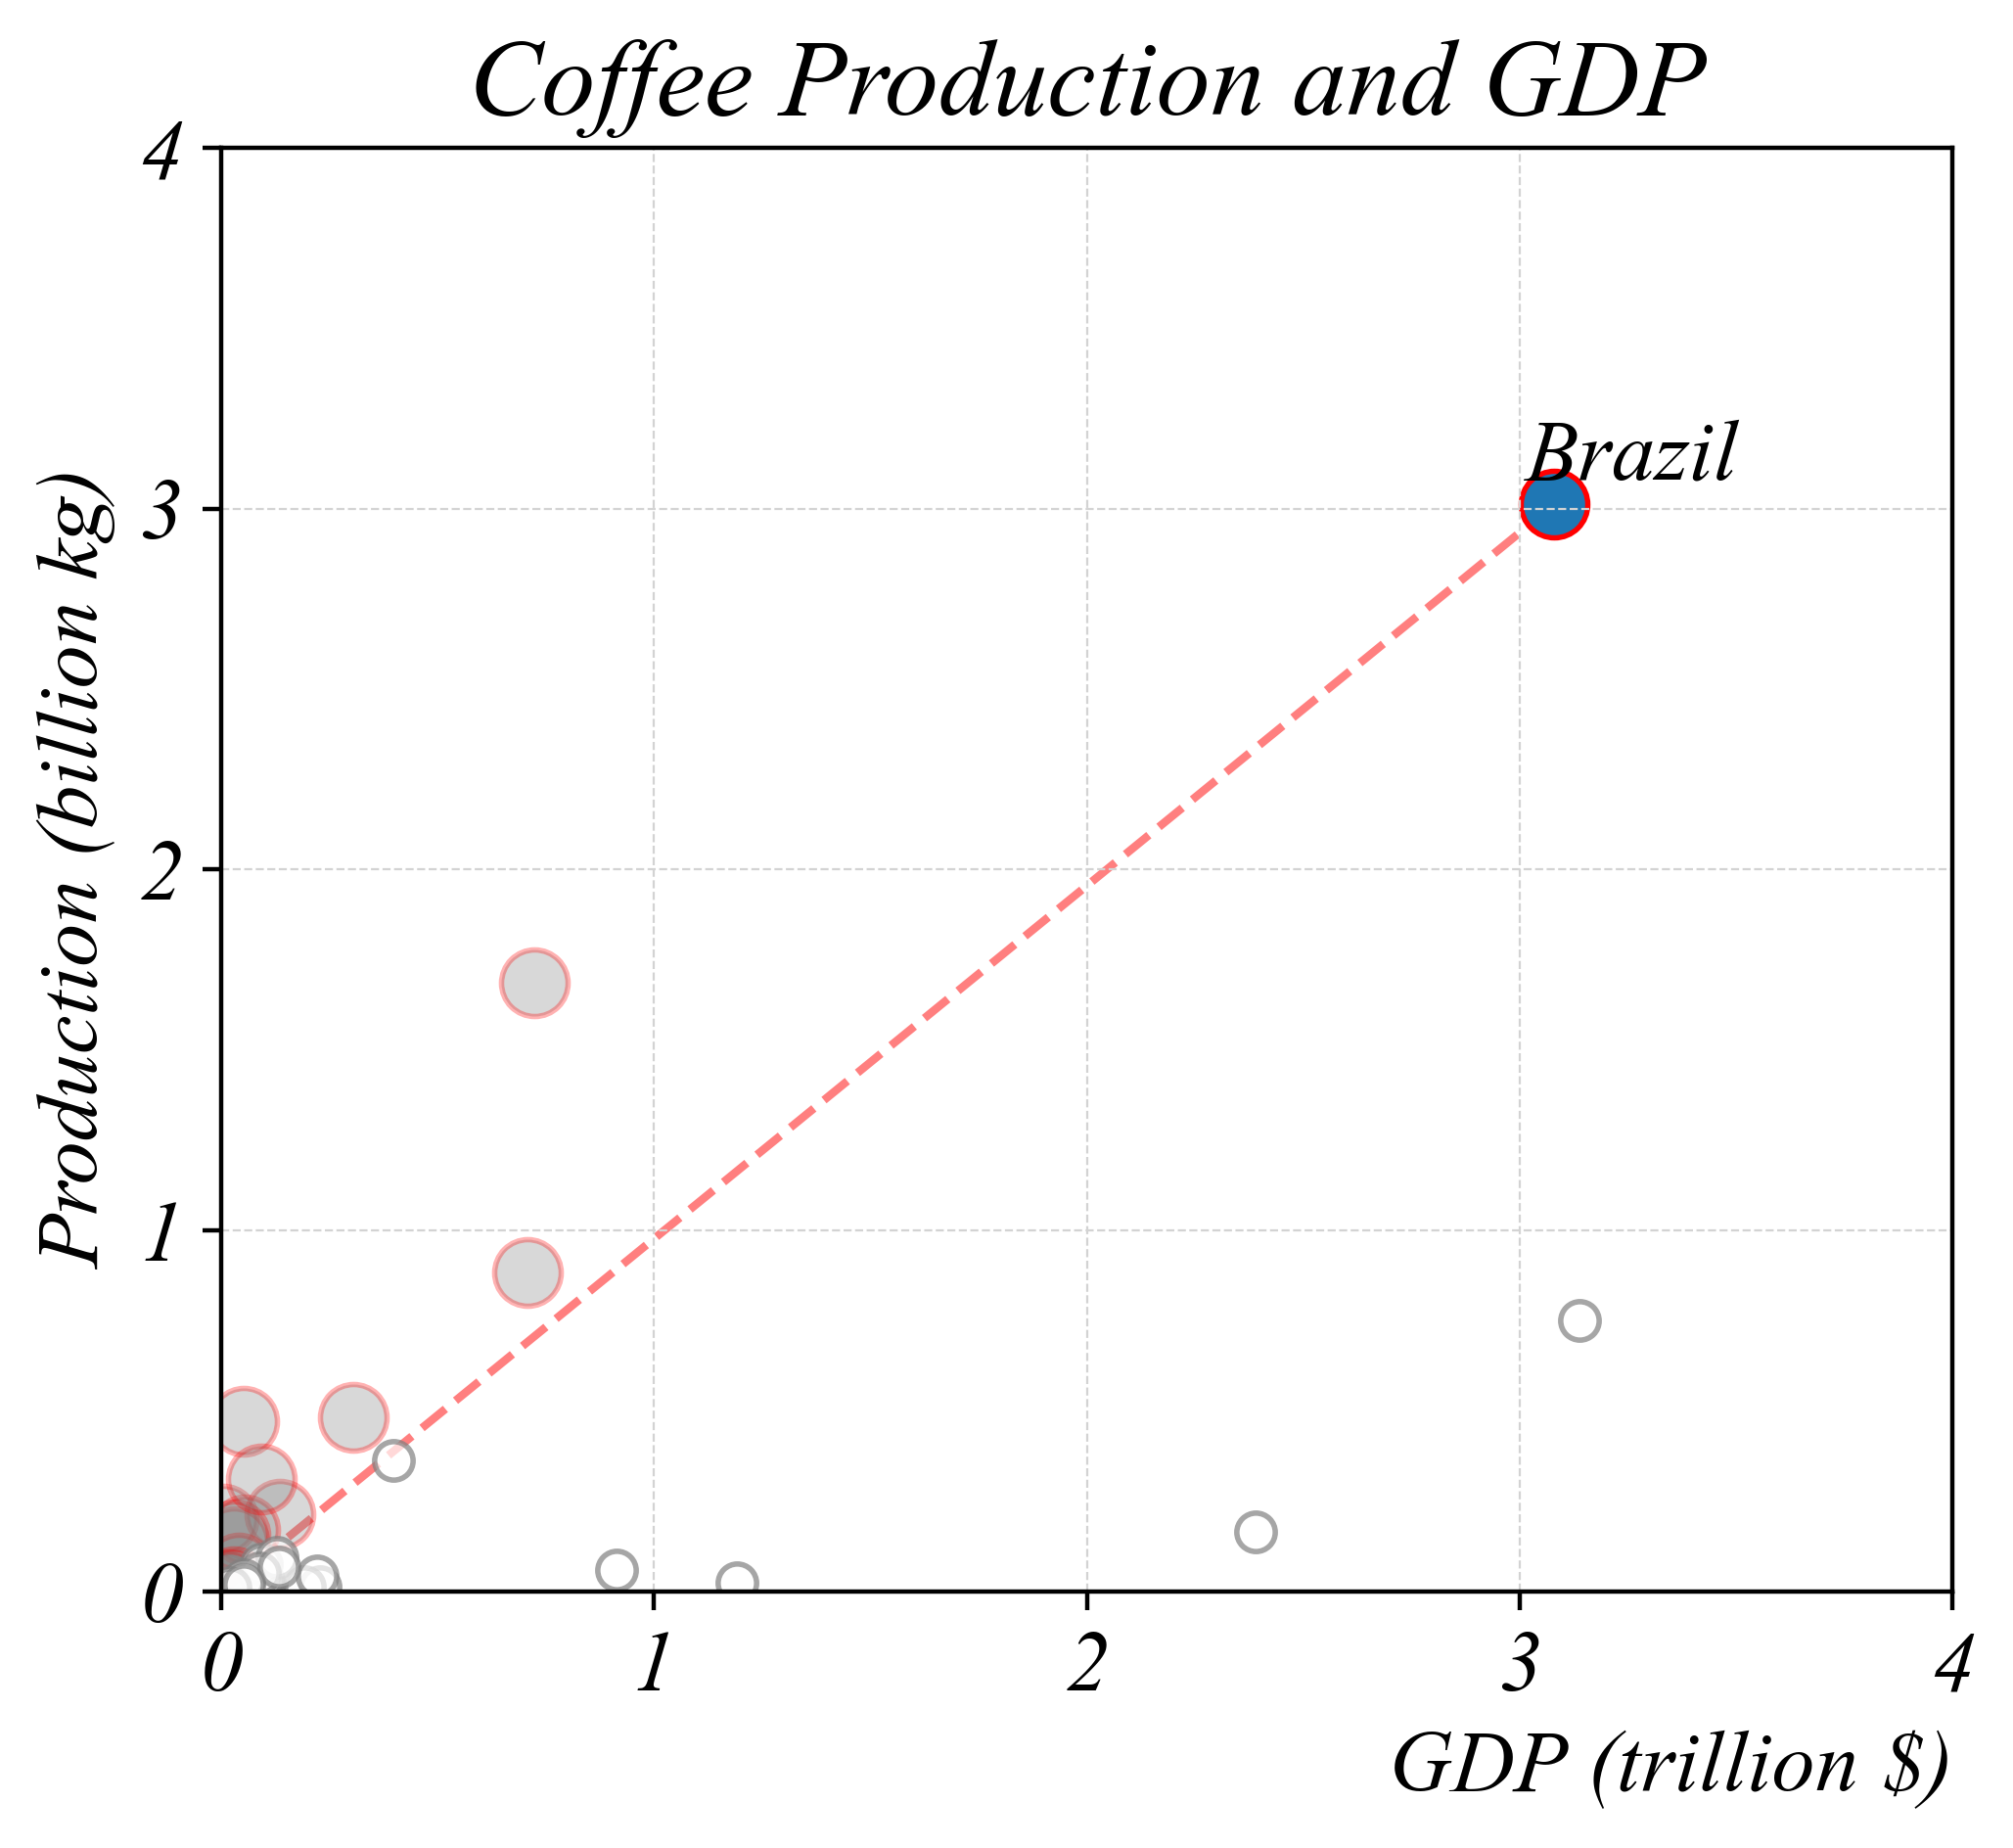

In [14]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['brazil_ratio'] = data['GDP']/data['coffee_prod']

brazil = data[data.coffee_prod == data.coffee_prod.max()]
brazil_gdp = brazil.GDP.values[0]
brazil_tonnes = brazil.coffee_prod.values[0]

greater = data[data['brazil_ratio'] > brazil_gdp/brazil_tonnes]
lower = data[data['brazil_ratio'] < brazil_gdp/brazil_tonnes]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(brazil, x='GDP', y='coffee_prod', edgecolors='red', alpha=1, s=150)
plt.scatter(lower['GDP'], lower['coffee_prod'], color='grey', edgecolors='red', alpha=0.3, s=150)
plt.scatter(greater['GDP'], greater['coffee_prod'], color='white', edgecolors='grey', alpha=0.7, s=50)

# Annotation
plt.annotate('Brazil',(brazil.coffee_prod.values[0], brazil.GDP.values[0]))
plt.plot([0,brazil.GDP.values[0]],[0,brazil.coffee_prod.values[0]], linestyle='--', color='red', zorder=-1, alpha=0.5)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_09.png')

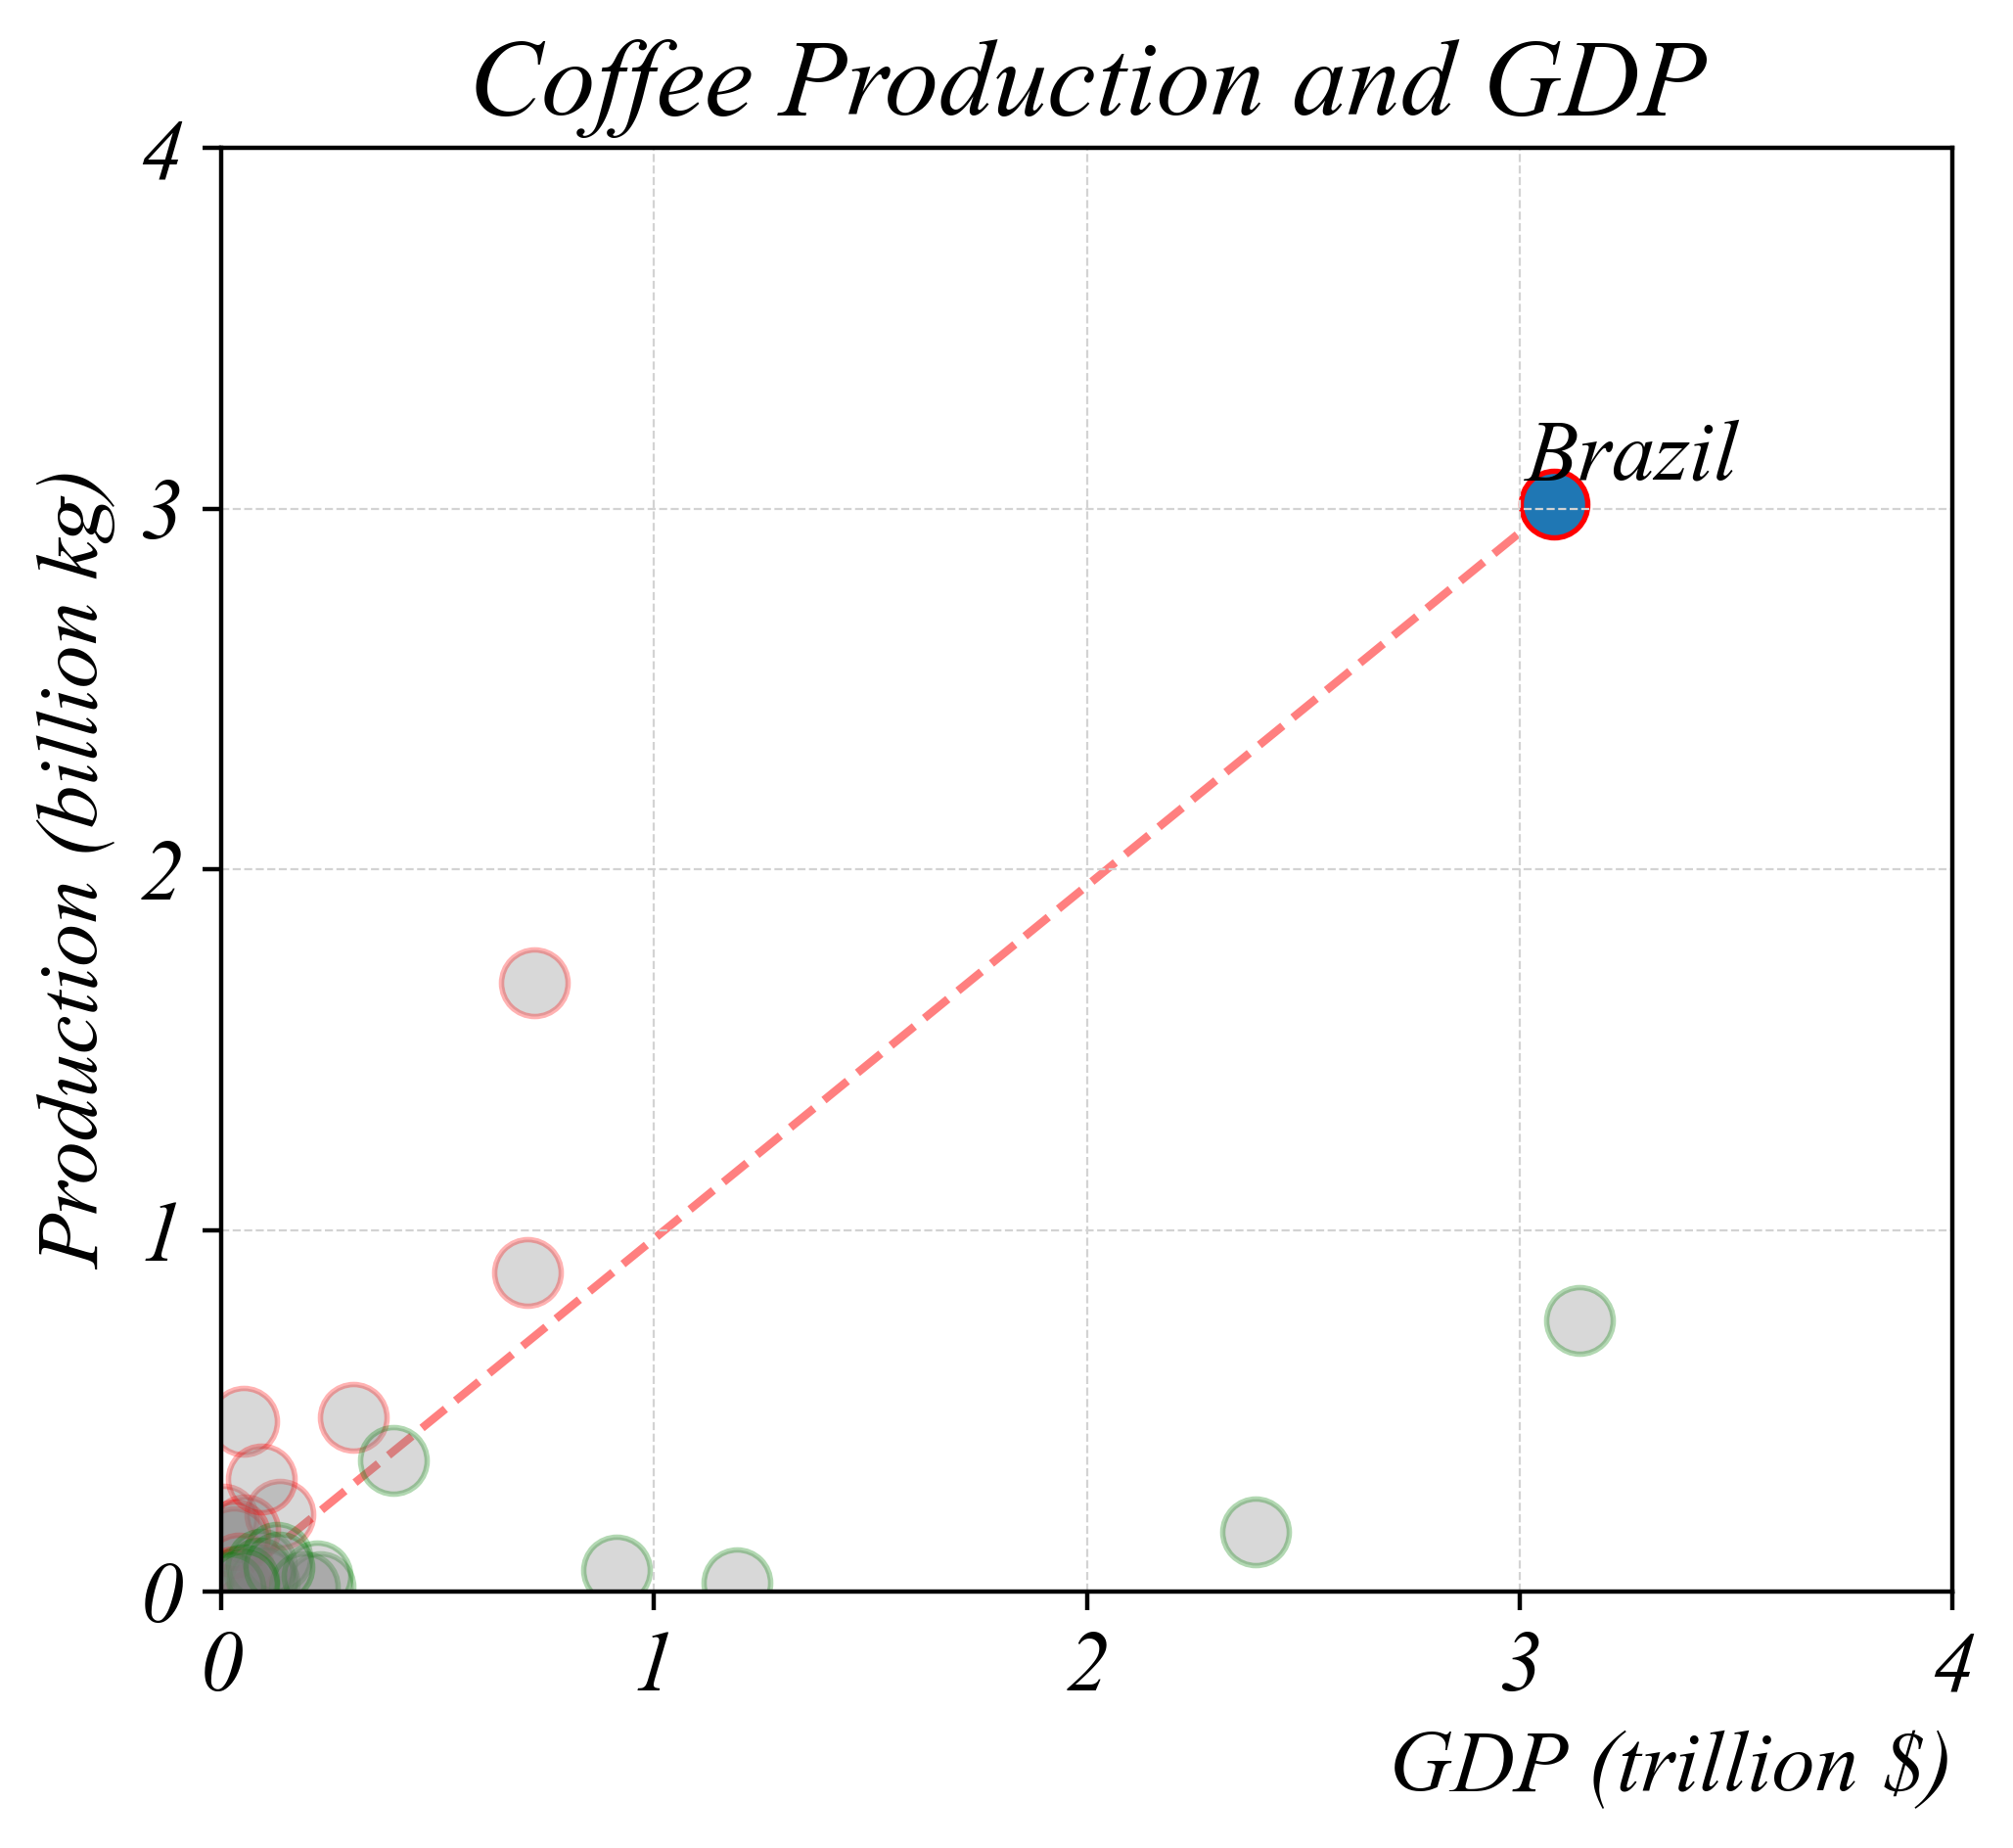

In [15]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['brazil_ratio'] = data['GDP']/data['coffee_prod']

brazil = data[data.coffee_prod == data.coffee_prod.max()]
brazil_gdp = brazil.GDP.values[0]
brazil_tonnes = brazil.coffee_prod.values[0]

greater = data[data['brazil_ratio'] > brazil_gdp/brazil_tonnes]
lower = data[data['brazil_ratio'] < brazil_gdp/brazil_tonnes]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(brazil, x='GDP', y='coffee_prod', edgecolors='red', alpha=1, s=150)
plt.scatter(lower['GDP'], lower['coffee_prod'], color='grey', edgecolors='red', alpha=0.3, s=150)
plt.scatter(greater['GDP'], greater['coffee_prod'], color='grey', edgecolors='green', alpha=0.3, s=150)

# Annotation
plt.annotate('Brazil',(brazil.coffee_prod.values[0], brazil.GDP.values[0]))
plt.plot([0,brazil.GDP.values[0]],[0,brazil.coffee_prod.values[0]], linestyle='--', color='red', zorder=-1, alpha=0.5)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_10_a.png')

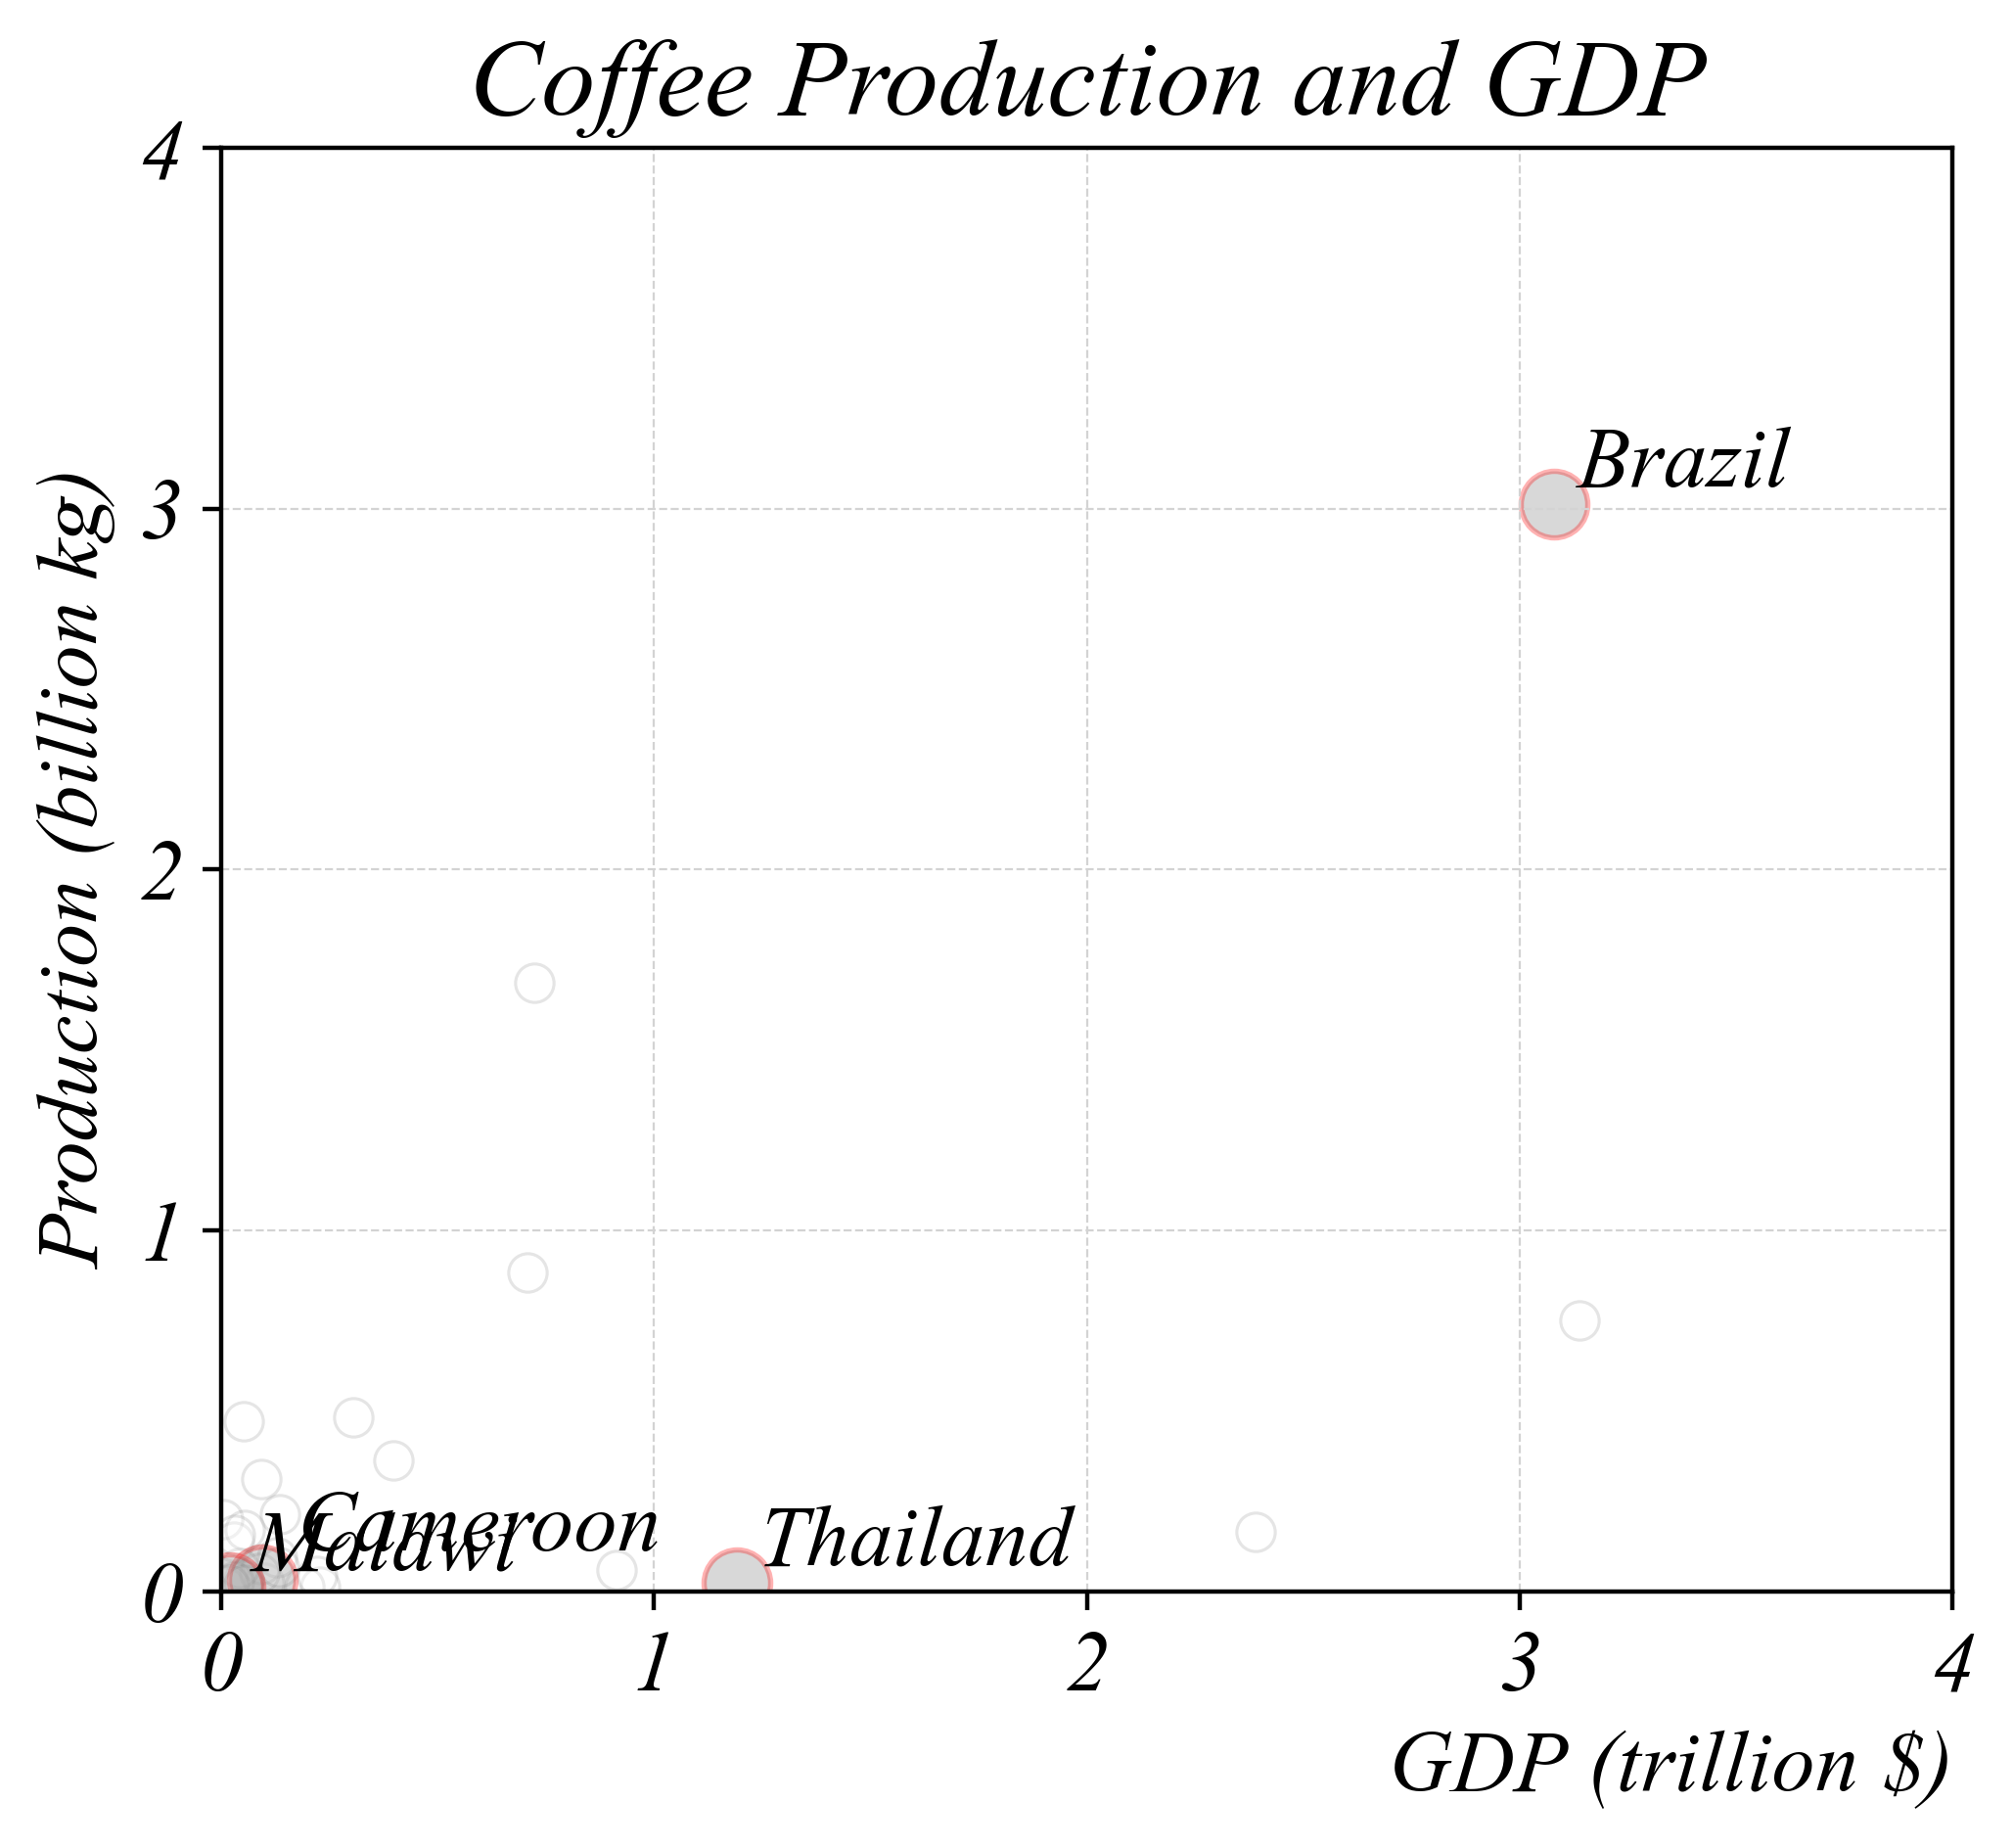

In [16]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]

subset_list = ['BRA', 'THA', 'MWI', 'CMR']
other_data = data[~data.Code.isin(subset_list)]
subset = data[data.Code.isin(subset_list)]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(other_data, x='GDP', y='coffee_prod', color='white', edgecolors='grey', alpha=0.2, s=50)
sns.scatterplot(subset, x='GDP', y='coffee_prod', color='grey', edgecolors='red', alpha=0.3, s=150)

# Annotation
for index, row in subset.iterrows():
    row_gdp = row.GDP
    row_tonnes = row.coffee_prod
    row_entity = row.Entity
    if row_entity != 'Cameroon':
        plt.annotate(row_entity,(row_gdp, row_tonnes),xytext=(row_gdp+0.05, row_tonnes+0.05))
    else:
        plt.annotate(row_entity,(row_gdp, row_tonnes),xytext=(row_gdp+0.08, row_tonnes+0.08))

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
plt.xticks(ticks)
plt.xlim(0,4)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_10.png')

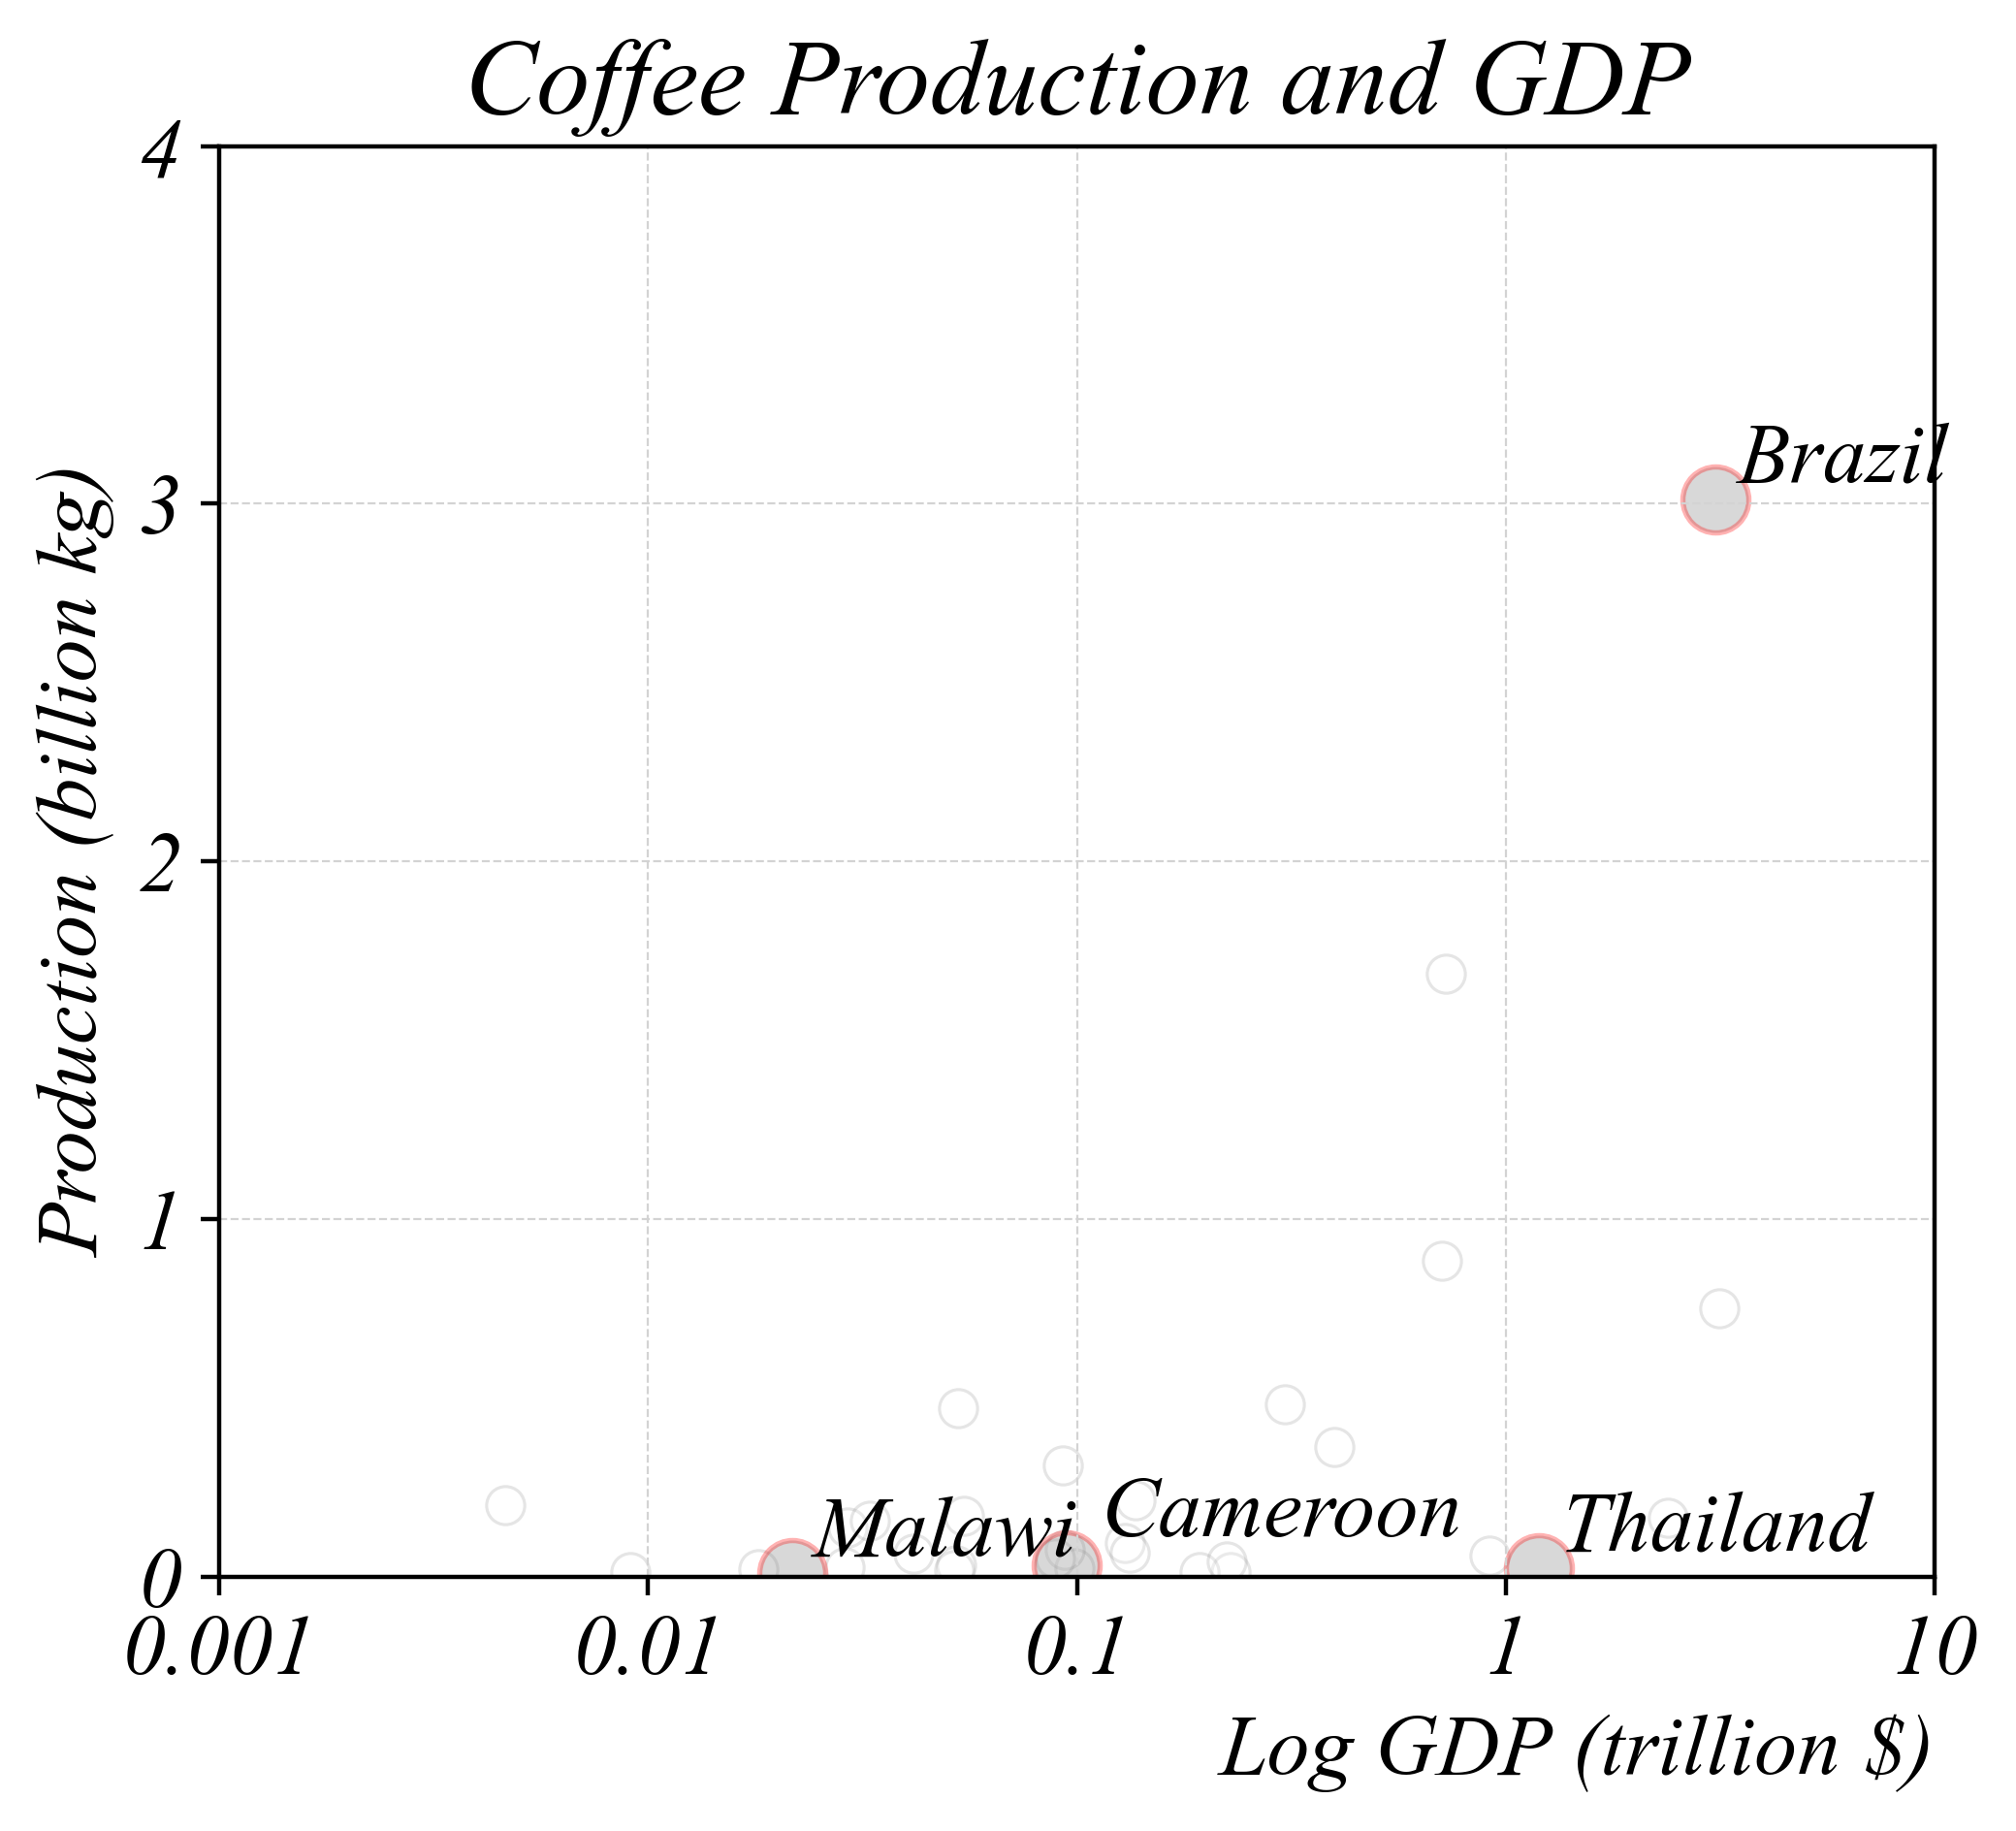

In [17]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)

subset_list = ['BRA', 'THA', 'MWI', 'CMR']
other_data = data[~data.Code.isin(subset_list)]
subset = data[data.Code.isin(subset_list)]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(other_data, x='log10_GDP', y='coffee_prod', color='white', edgecolors='grey', alpha=0.2, s=50)
sns.scatterplot(subset, x='log10_GDP', y='coffee_prod', color='grey', edgecolors='red', alpha=0.3, s=150)

# Annotation
for index, row in subset.iterrows():
    row_gdp = row.log10_GDP
    row_tonnes = row.coffee_prod
    row_entity = row.Entity
    if row_entity != 'Cameroon':
        plt.annotate(row_entity,(row_gdp, row_tonnes),xytext=(row_gdp+0.05, row_tonnes+0.05))
    else:
        plt.annotate(row_entity,(row_gdp, row_tonnes),xytext=(row_gdp+0.08, row_tonnes+0.08))

# Styling
plt.xlabel('Log GDP (trillion $)', loc='right')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
plt.xticks(ticks=x_ticks, labels=x_ticks_labels)

plt.ylabel('Production (billion kg)')
plt.yticks(ticks)
plt.ylim(0,4)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_11.png')

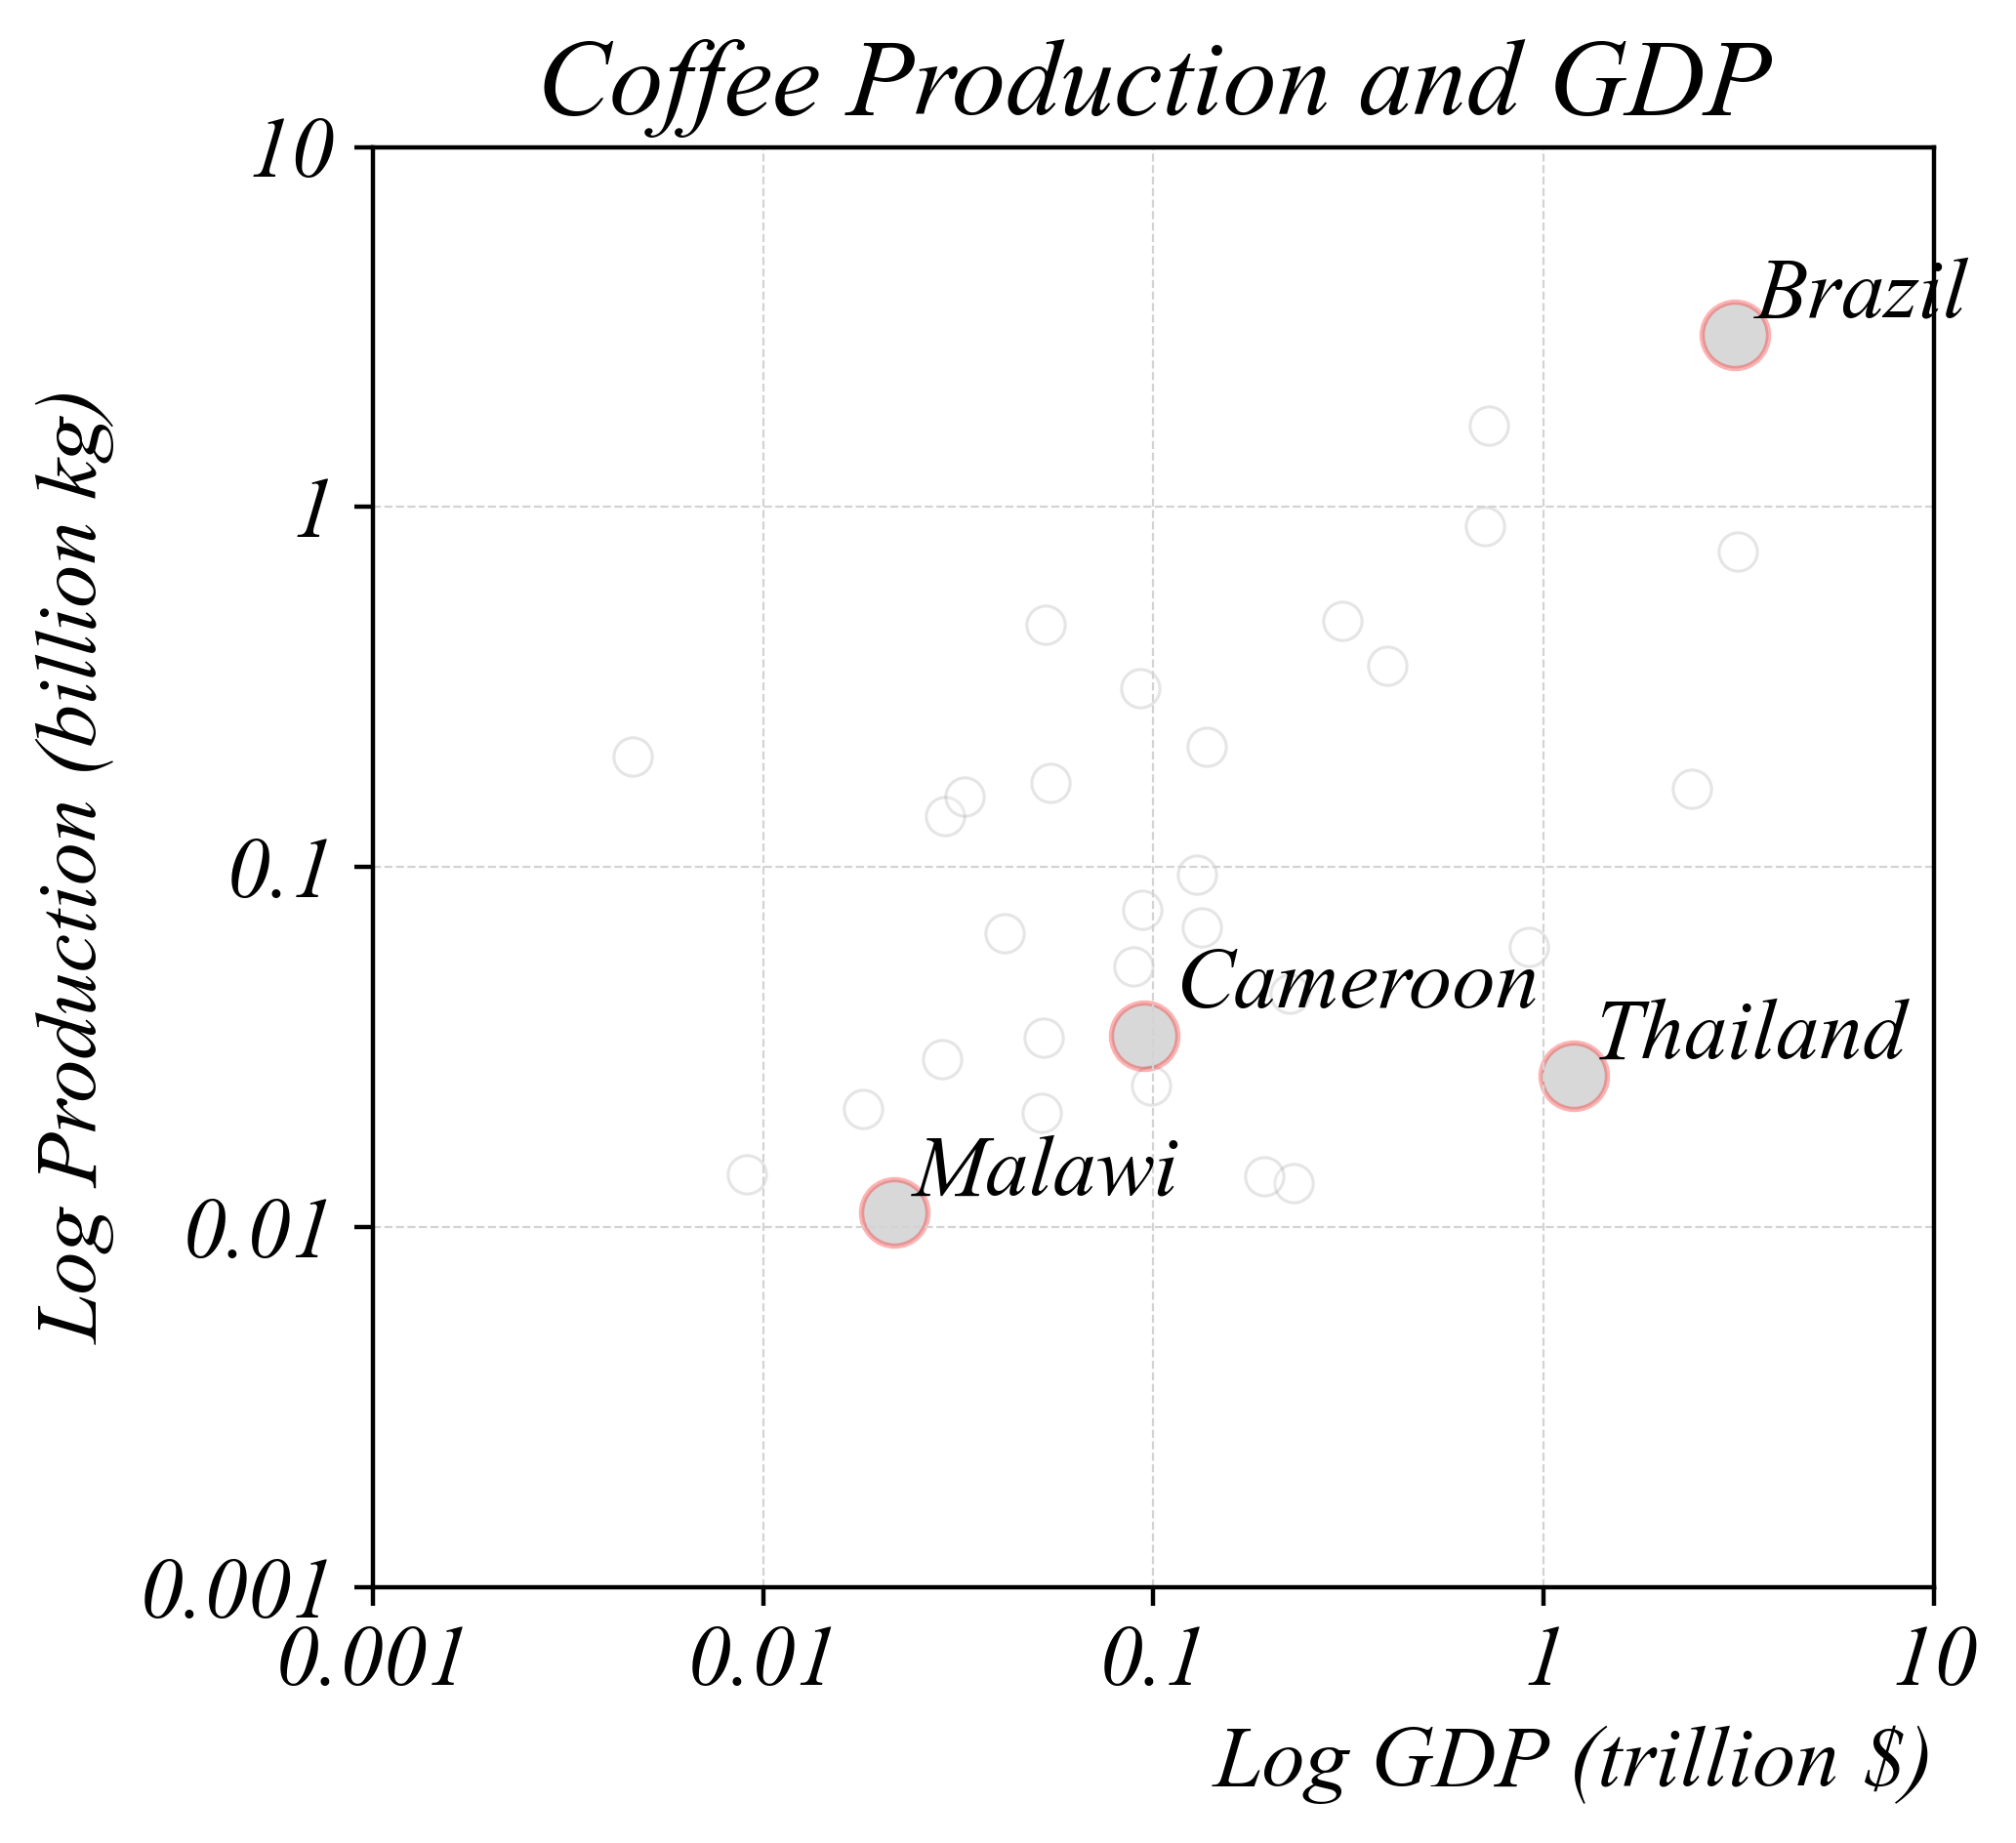

In [18]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)
data['log10_Tonnes'] = np.log10(data['coffee_prod'].replace(0, np.nan) + 1e-10)

subset_list = ['BRA', 'THA', 'MWI', 'CMR']
other_data = data[~data.Code.isin(subset_list)]
subset = data[data.Code.isin(subset_list)]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(other_data, x='log10_GDP', y='log10_Tonnes', color='white', edgecolors='grey', alpha=0.2, s=50)
sns.scatterplot(subset, x='log10_GDP', y='log10_Tonnes', color='grey', edgecolors='red', alpha=0.3, s=150)

# Annotation
for index, row in subset.iterrows():
    row_gdp = row.log10_GDP
    row_tonnes = row.log10_Tonnes
    row_entity = row.Entity
    if row_entity != 'Cameroon':
        plt.annotate(row_entity,(row_gdp, row_tonnes),xytext=(row_gdp+0.05, row_tonnes+0.05))
    else:
        plt.annotate(row_entity,(row_gdp, row_tonnes),xytext=(row_gdp+0.08, row_tonnes+0.08))

# Styling
plt.xlabel('Log GDP (trillion $)', loc='right')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
plt.xticks(ticks=x_ticks, labels=x_ticks_labels)

plt.ylabel('Log Production (billion kg)')
y_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
y_ticks = np.log10(y_ticks_labels)
plt.yticks(ticks=y_ticks, labels=y_ticks_labels)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_12.png')

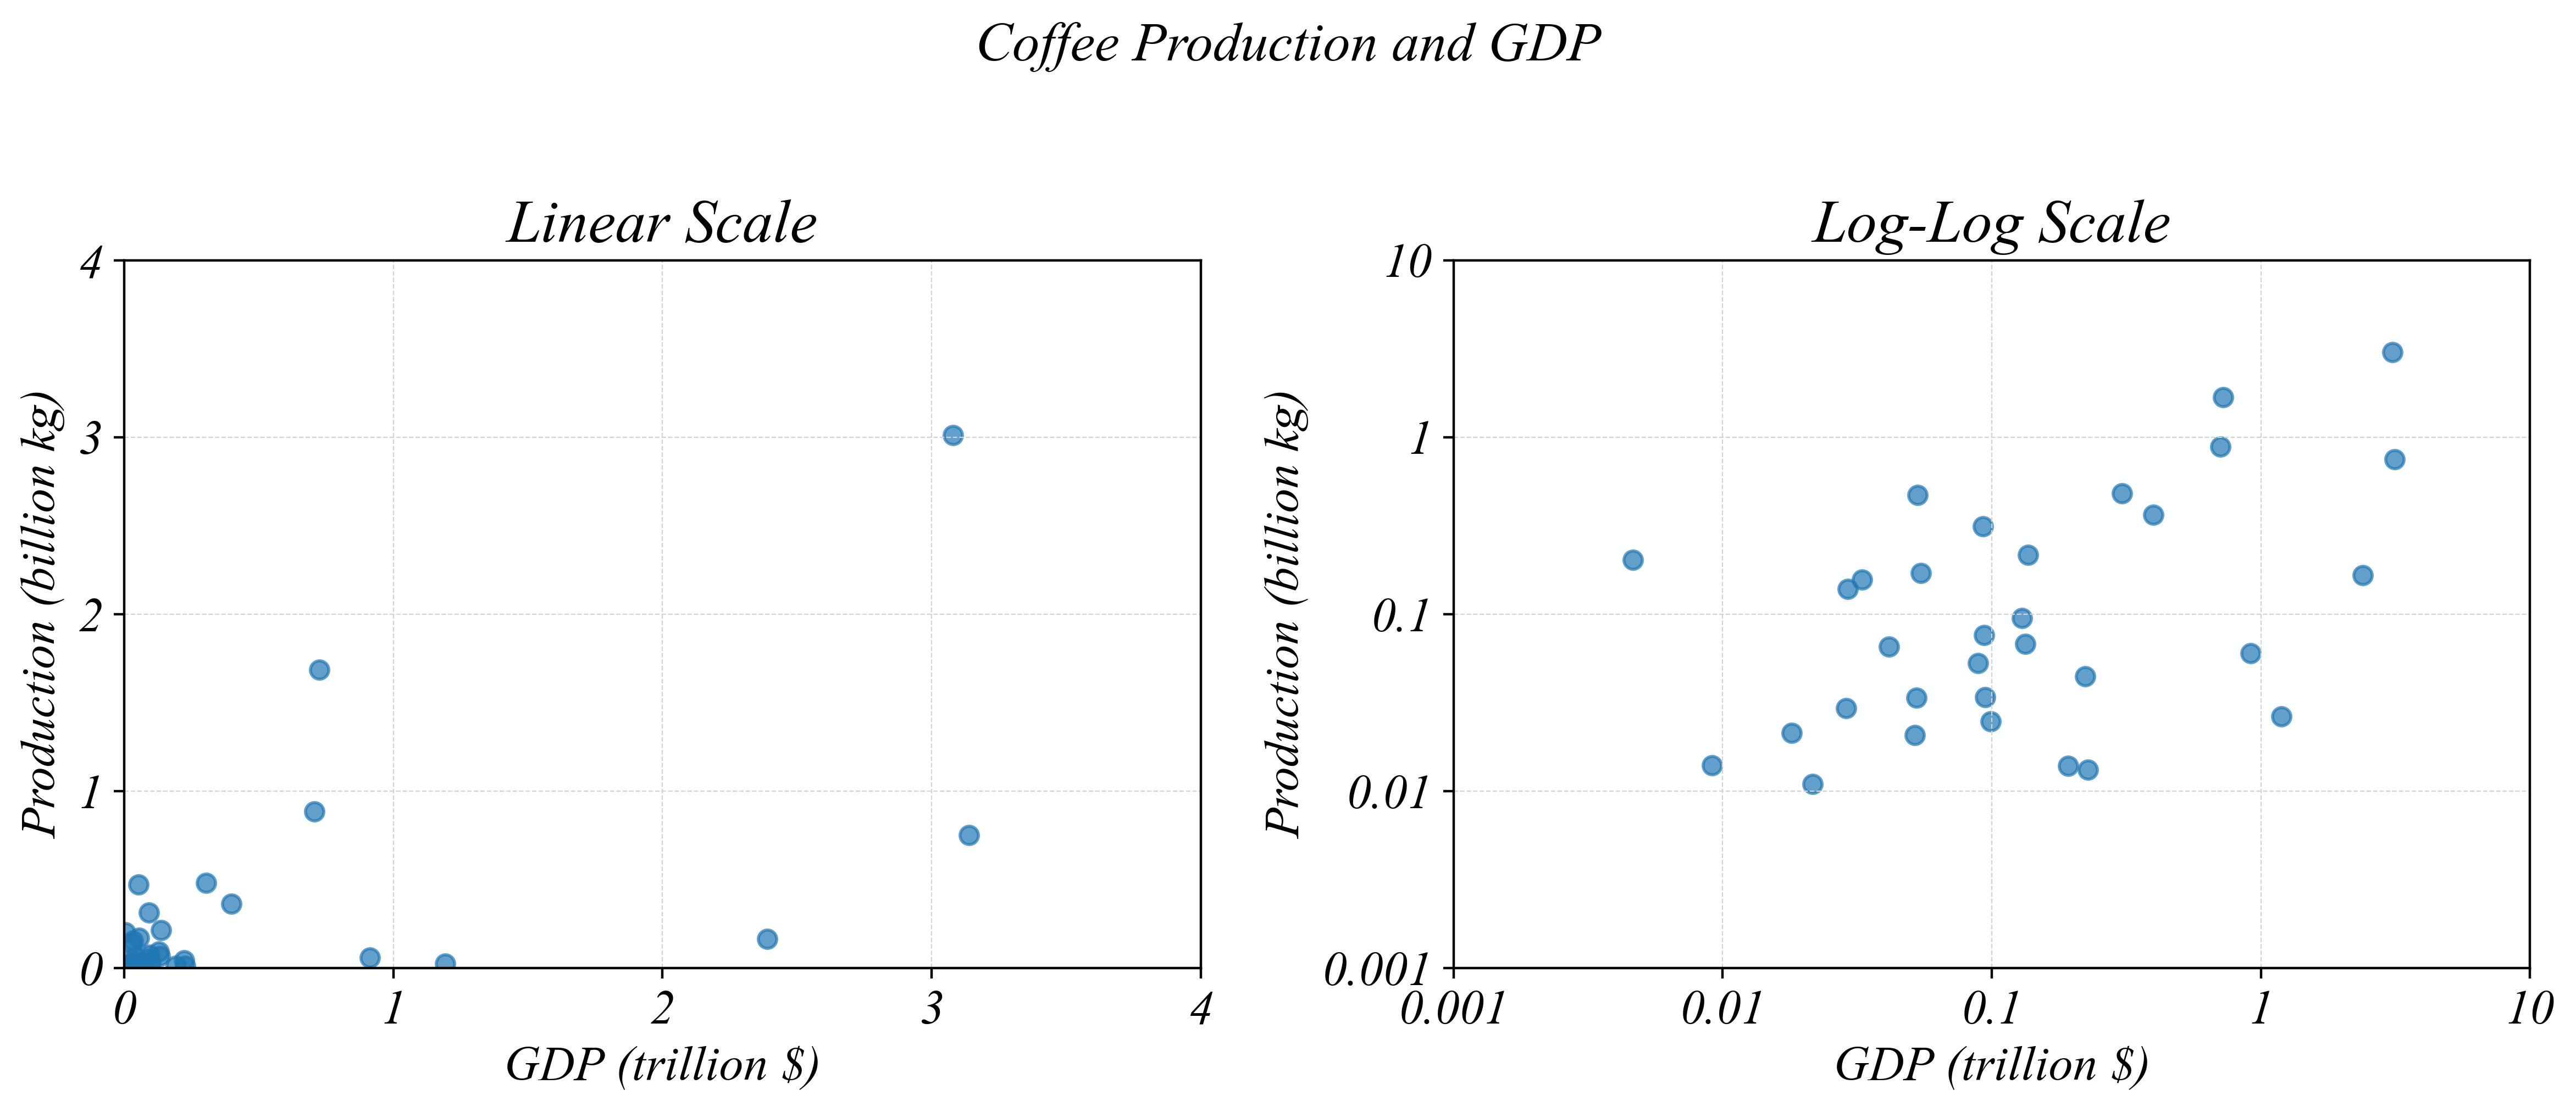

In [19]:
# Figure: Side-by-side comparison of Linear vs Log-Log scale
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)
data['log10_Tonnes'] = np.log10(data['coffee_prod'].replace(0, np.nan) + 1e-10)

ticks = [0,1,2,3,4]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left subplot: Linear scale
ax1.scatter(data['GDP'], data['coffee_prod'], alpha=0.7)
ax1.set_xlabel('GDP (trillion $)')
ax1.set_xticks(ticks)
ax1.set_xlim(0,4)
ax1.set_ylabel('Production (billion kg)')
ax1.set_yticks(ticks)
ax1.set_ylim(0,4)
ax1.set_title('Linear Scale')
ax1.grid(True, color='lightgray', linestyle='--', linewidth=0.4)

# Right subplot: Log-Log scale
ax2.scatter(data['log10_GDP'], data['log10_Tonnes'], alpha=0.7)
ax2.set_xlabel('GDP (trillion $)')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(x_ticks_labels)
ax2.set_ylabel('Production (billion kg)')
y_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
y_ticks = np.log10(y_ticks_labels)
ax2.set_yticks(y_ticks)
ax2.set_yticklabels(y_ticks_labels)
ax2.set_title('Log-Log Scale')
ax2.grid(True, color='lightgray', linestyle='--', linewidth=0.4)

plt.suptitle('Coffee Production and GDP', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('i/c_03_12.png', dpi=300, bbox_inches='tight')

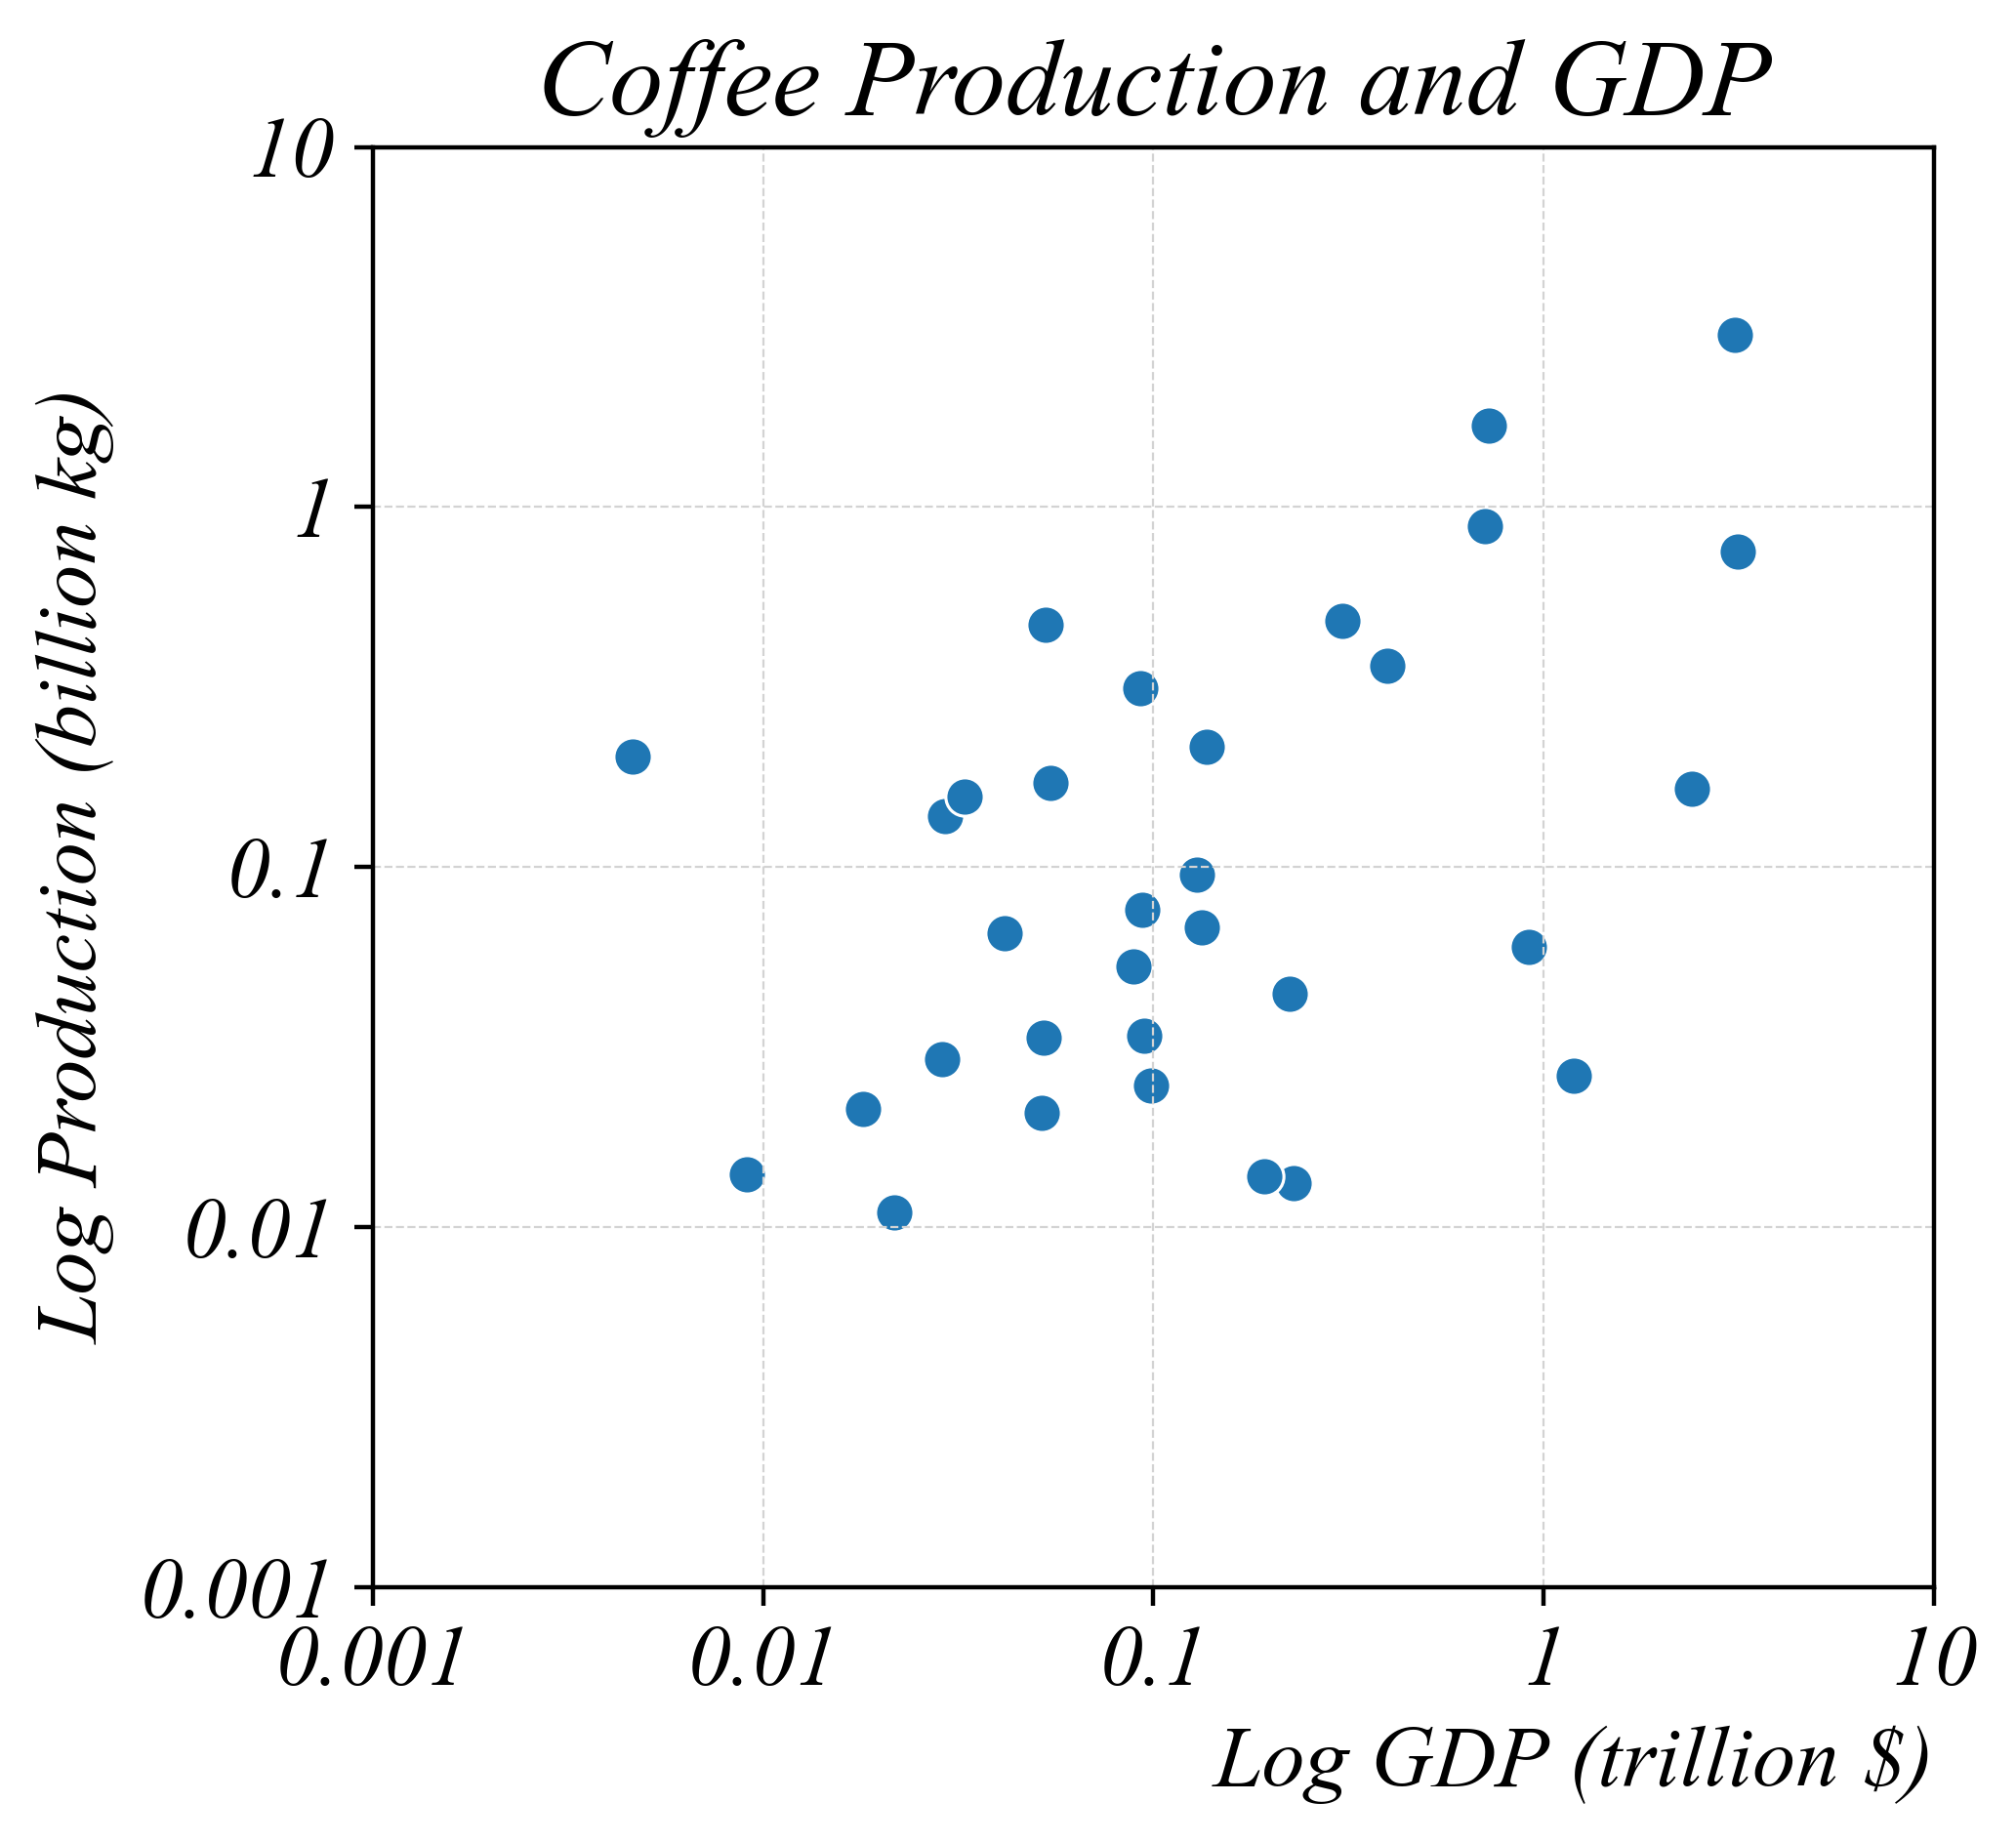

In [20]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)
data['log10_Tonnes'] = np.log10(data['coffee_prod'].replace(0, np.nan) + 1e-10)

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='log10_GDP', y='log10_Tonnes', color='C0', s=50)

# Styling
plt.xlabel('Log GDP (trillion $)', loc='right')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
plt.xticks(ticks=x_ticks, labels=x_ticks_labels)

plt.ylabel('Log Production (billion kg)')
y_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
y_ticks = np.log10(y_ticks_labels)
plt.yticks(ticks=y_ticks, labels=y_ticks_labels)
plt.title('Coffee Production and GDP')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_13.png')

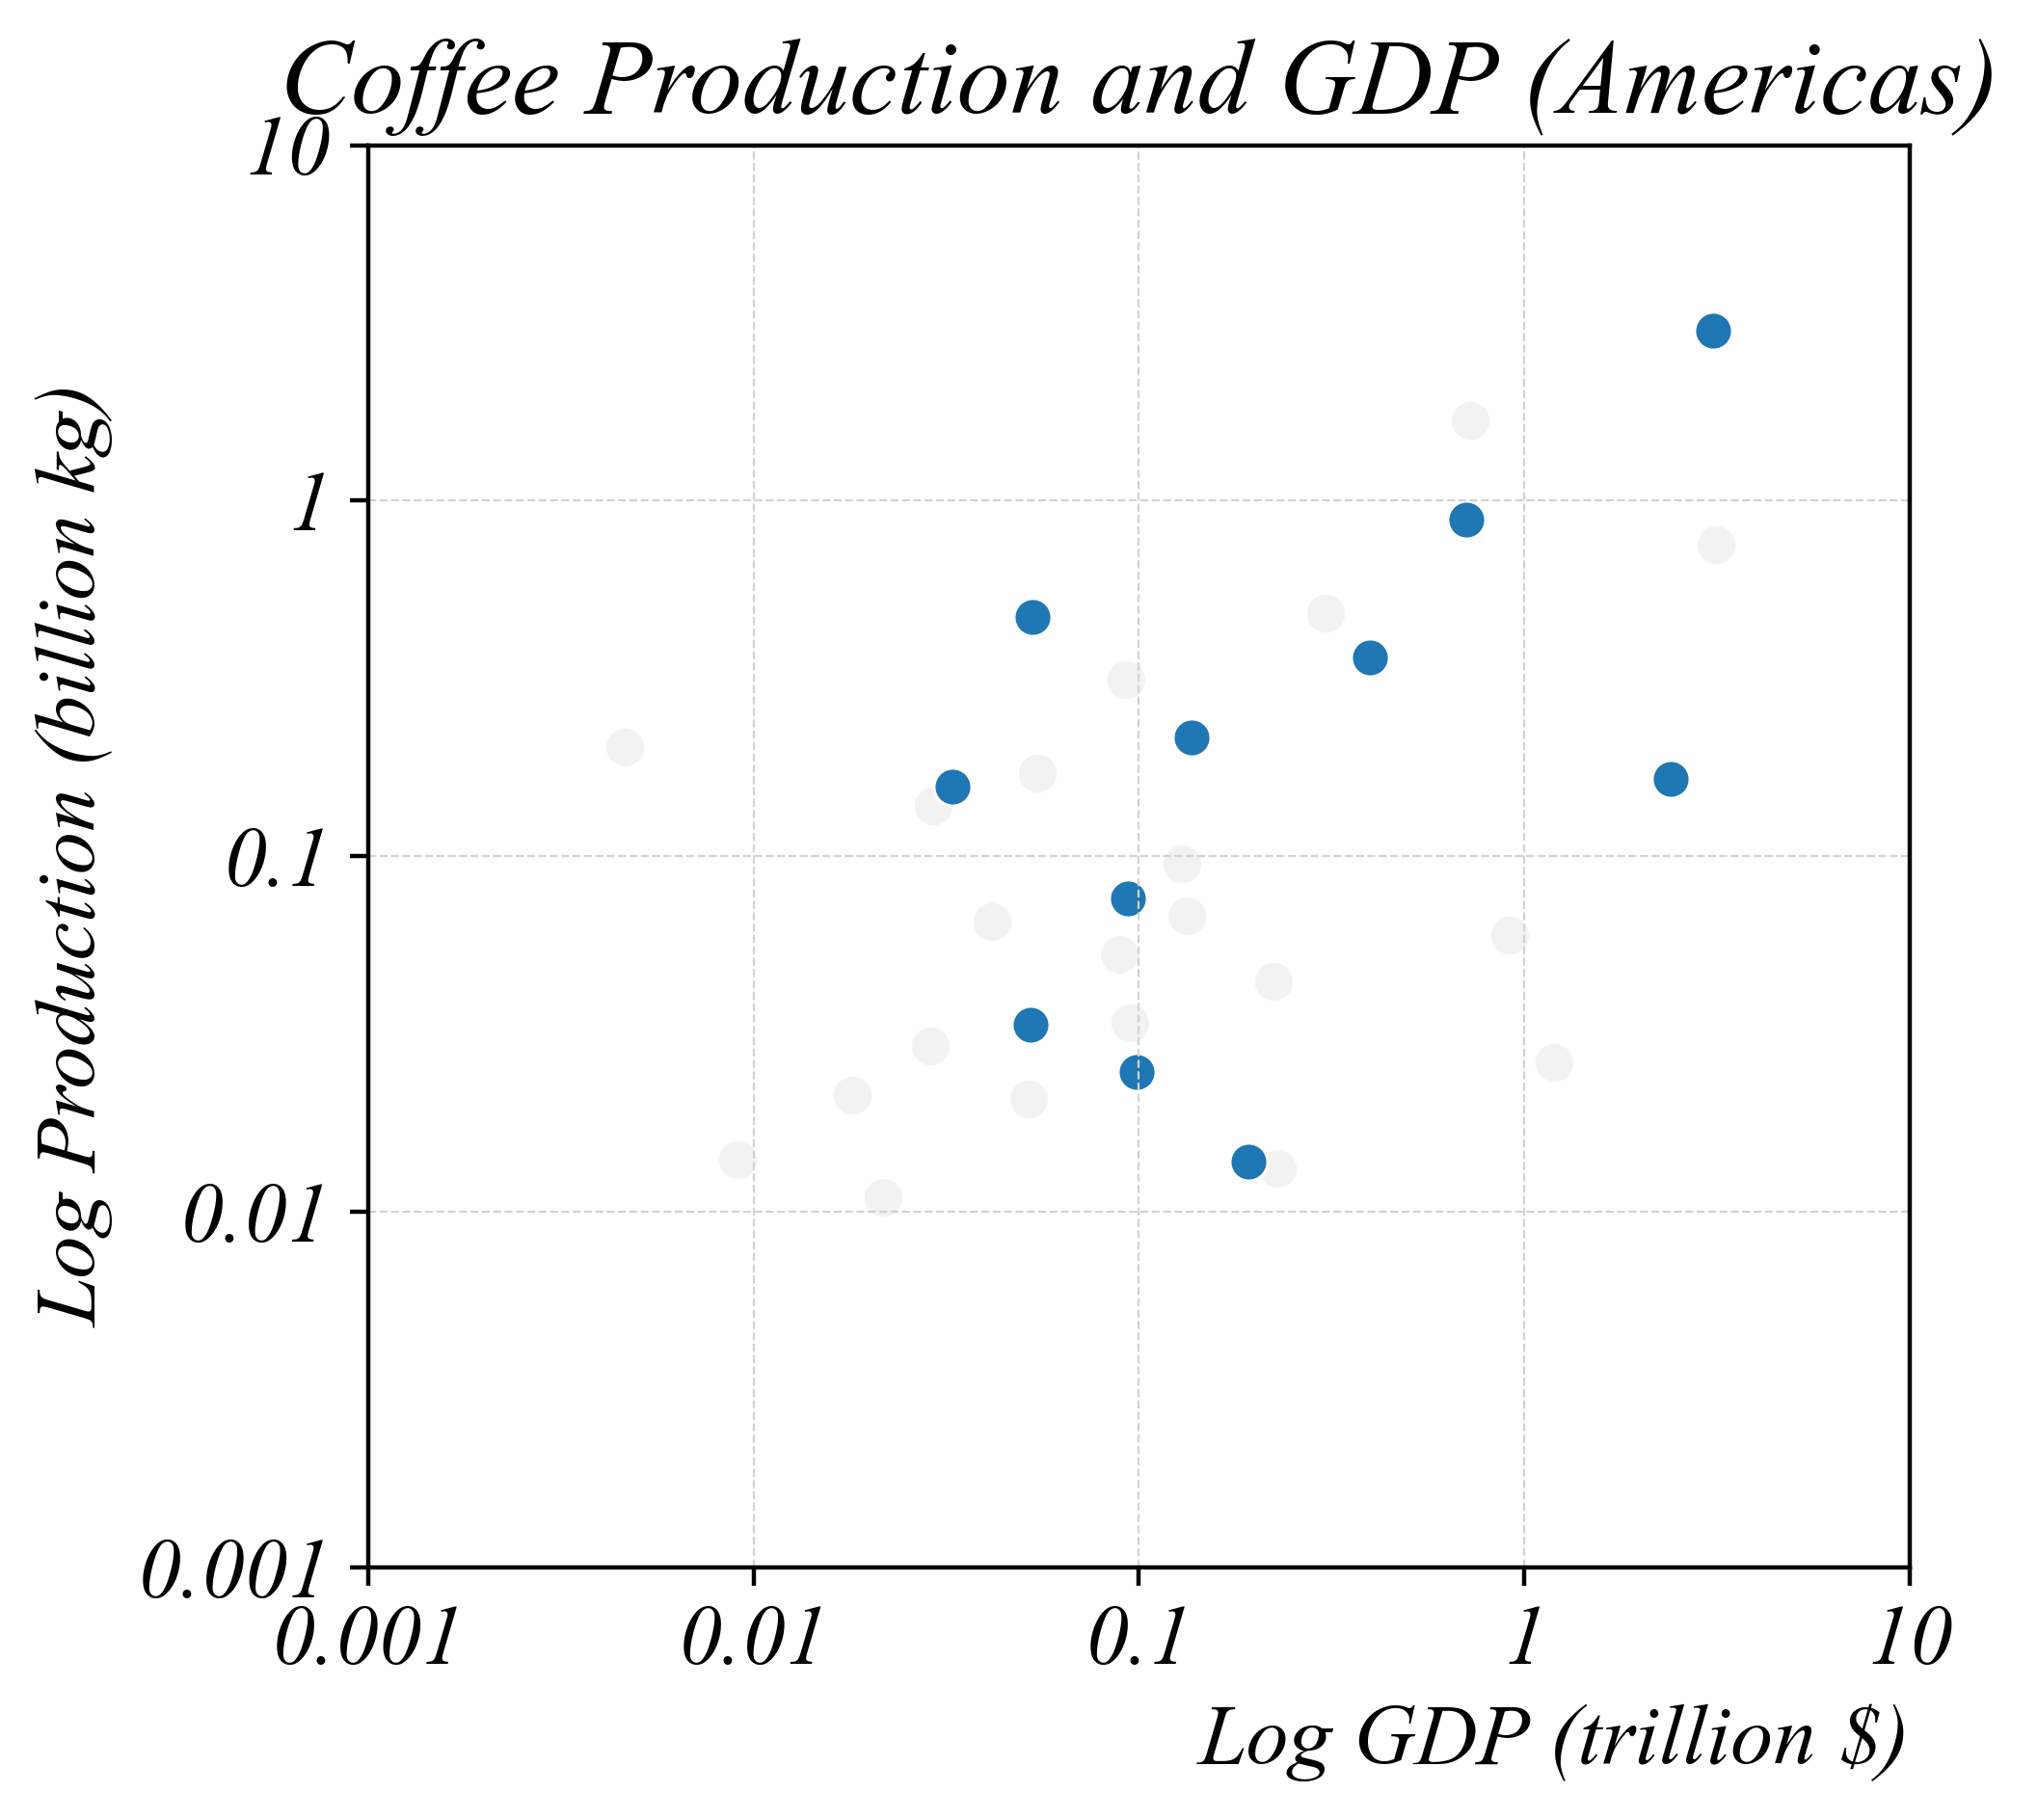

In [21]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)
data['log10_Tonnes'] = np.log10(data['coffee_prod'].replace(0, np.nan) + 1e-10)

americas = ['Bolivia', 'Brazil', 'Colombia', 'Costa Rica', 'Dominican Republic', 'El Salvador', 'Guatemala',
       'Honduras', 'Mexico', 'Nicaragua', 'Peru']
america_data = data[data.Entity.isin(americas)]

ticks = [0,1,2,3,4]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='log10_GDP', y='log10_Tonnes', color='grey', alpha=0.1, s=50)
sns.scatterplot(america_data, x='log10_GDP', y='log10_Tonnes', color='C0', s=50)

# Styling
plt.xlabel('Log GDP (trillion $)', loc='right')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
plt.xticks(ticks=x_ticks, labels=x_ticks_labels)

plt.ylabel('Log Production (billion kg)')
y_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
y_ticks = np.log10(y_ticks_labels)
plt.yticks(ticks=y_ticks, labels=y_ticks_labels)
plt.title('Coffee Production and GDP (Americas)')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_14.png')

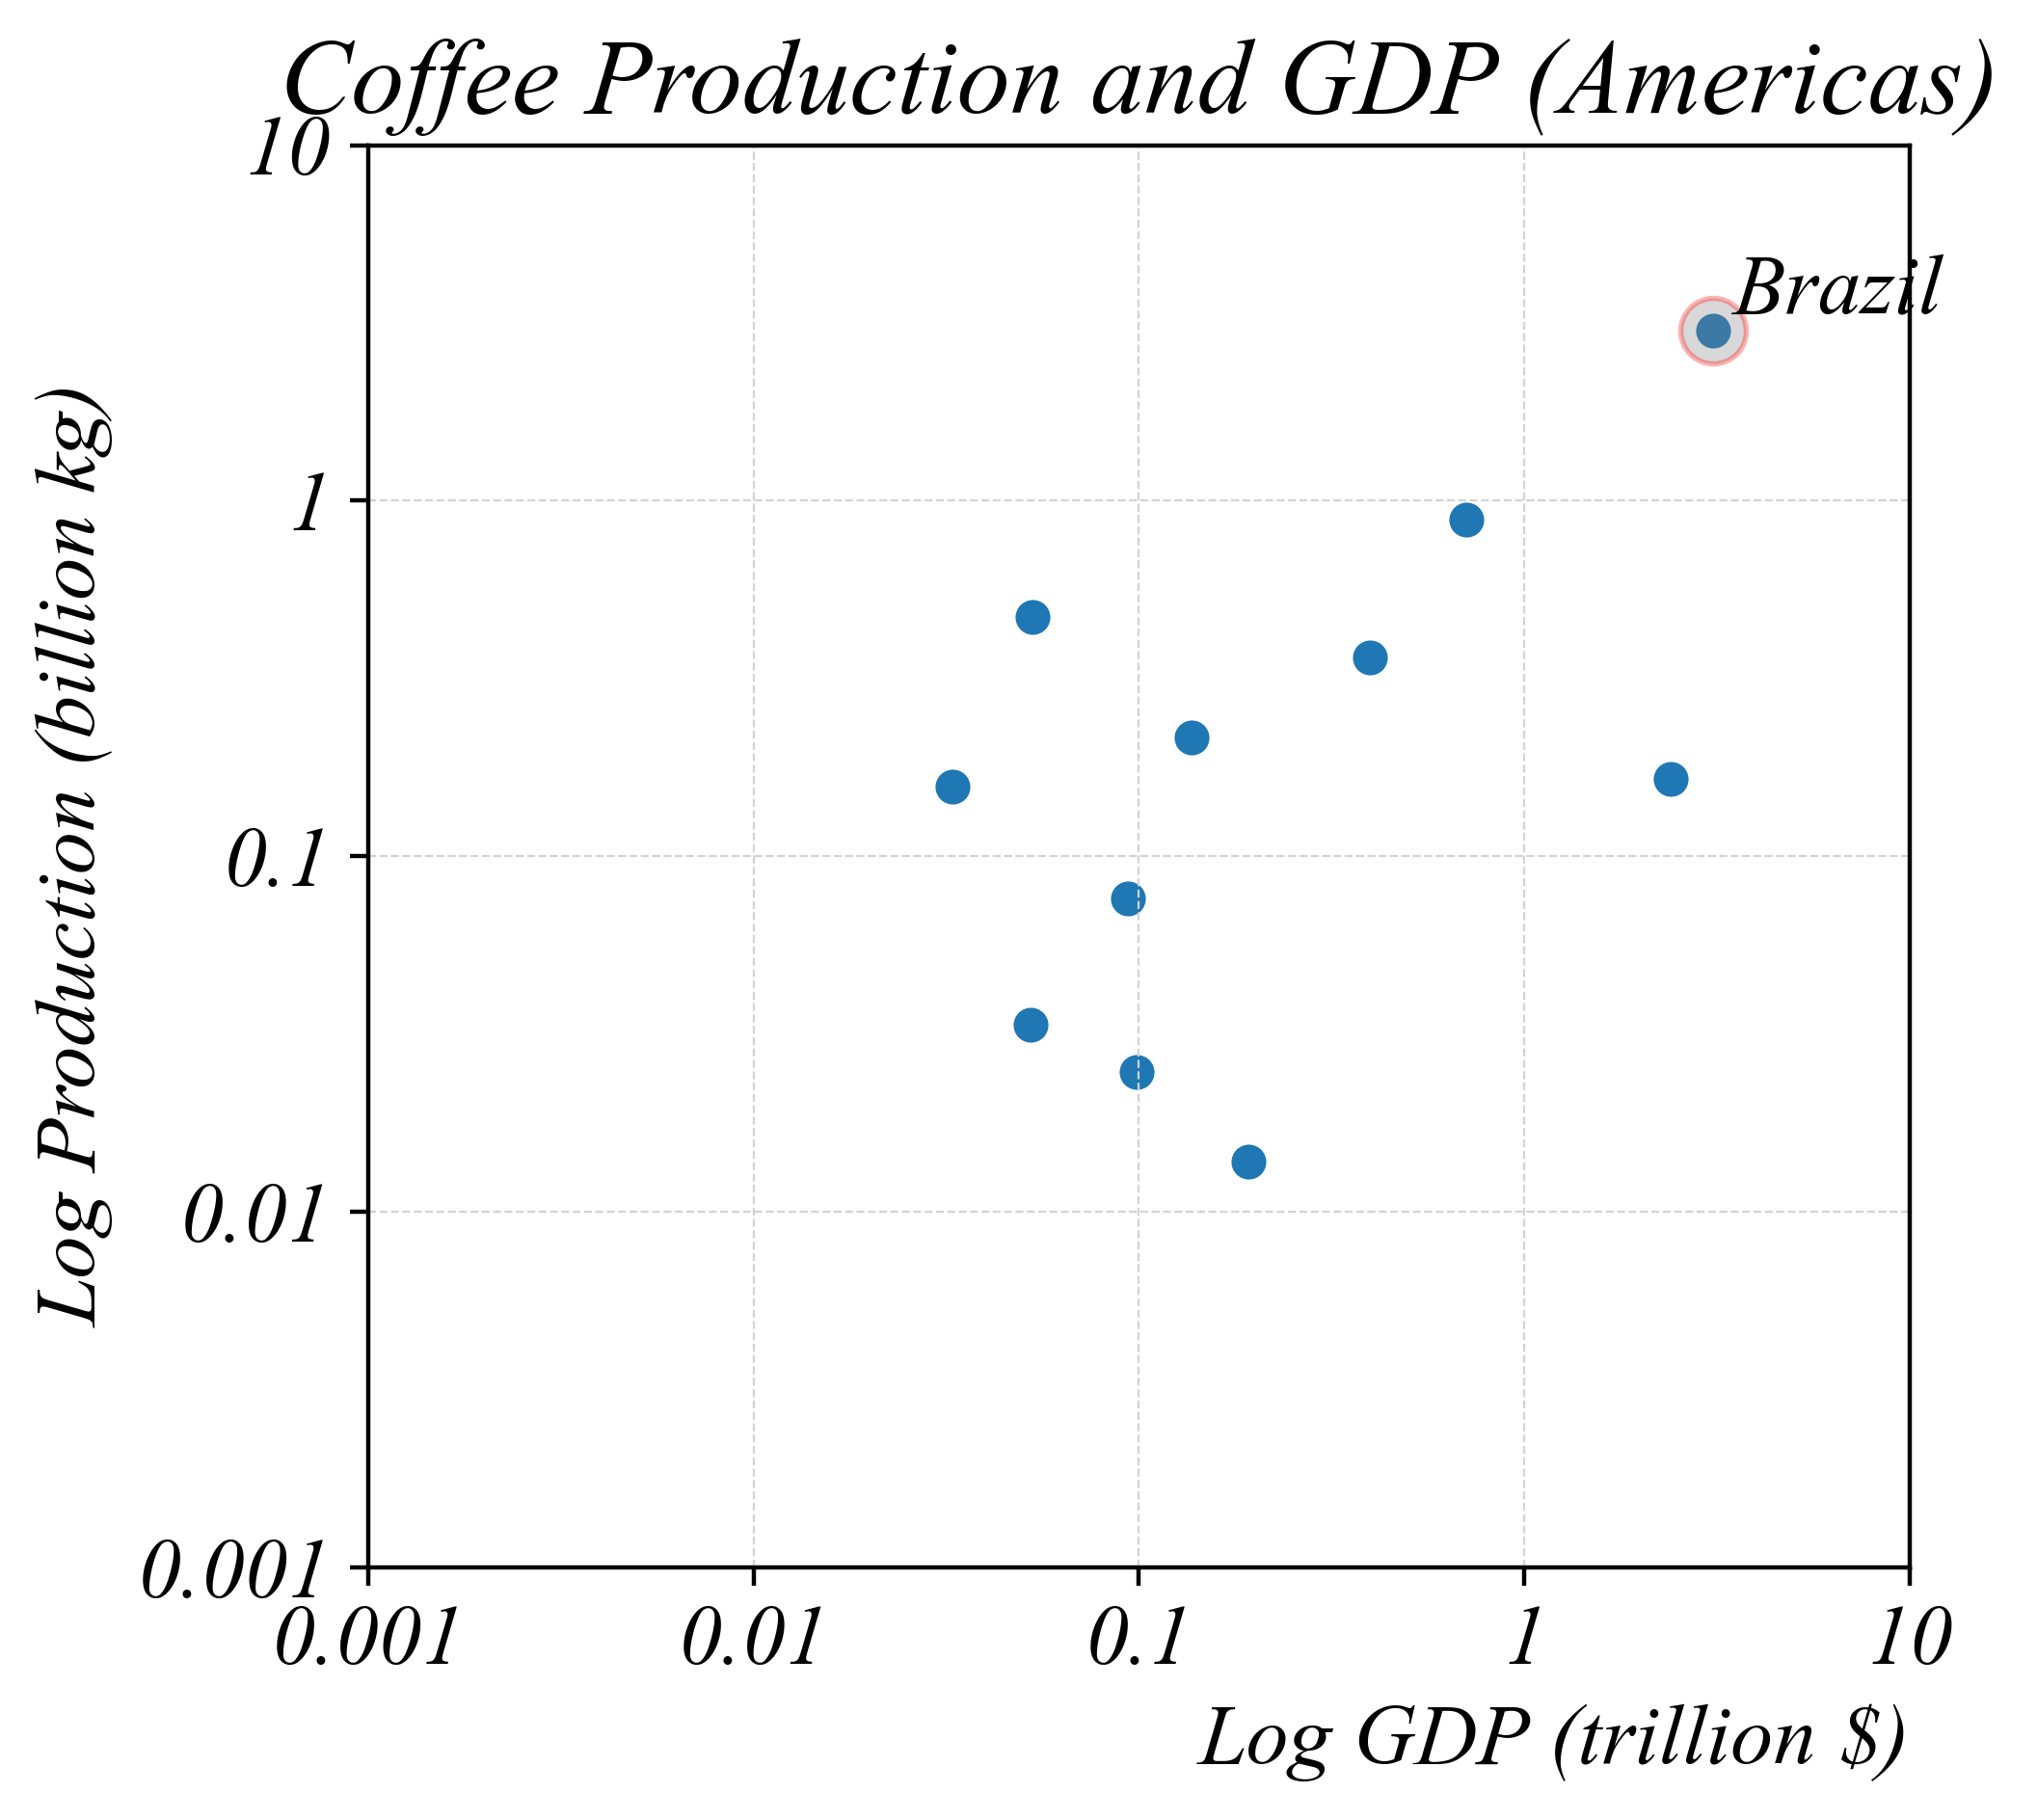

In [22]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)
data['log10_Tonnes'] = np.log10(data['coffee_prod'].replace(0, np.nan) + 1e-10)

americas = ['Bolivia', 'Brazil', 'Colombia', 'Costa Rica', 'Dominican Republic', 'El Salvador', 'Guatemala',
       'Honduras', 'Mexico', 'Nicaragua', 'Peru']
america_data = data[data.Entity.isin(americas)]

america_max = america_data[america_data.log10_Tonnes == america_data.log10_Tonnes.max()]

row_gdp = america_max.iloc[0].log10_GDP
row_tonnes = america_max.iloc[0].log10_Tonnes
row_entity = america_max.iloc[0].Entity

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(america_data, x='log10_GDP', y='log10_Tonnes', color='C0', s=50)
sns.scatterplot(america_max, x='log10_GDP', y='log10_Tonnes', color='grey', edgecolors='red', alpha=0.3, s=150)

# Annotation
plt.annotate(row_entity,(row_gdp, row_tonnes),xytext=(row_gdp+0.05, row_tonnes+0.05))

# Styling
plt.xlabel('Log GDP (trillion $)', loc='right')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
plt.xticks(ticks=x_ticks, labels=x_ticks_labels)

plt.ylabel('Log Production (billion kg)')
y_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
y_ticks = np.log10(y_ticks_labels)
plt.yticks(ticks=y_ticks, labels=y_ticks_labels)
plt.title('Coffee Production and GDP (Americas)')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_15.png')

/var/folders/v7/n92bbkrn50x_rhkvsgm29llc0000gn/T/ipykernel_80456/1784404148.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  america_data['GDP_dif'] = np.abs(america_data.log10_GDP - row_gdp)


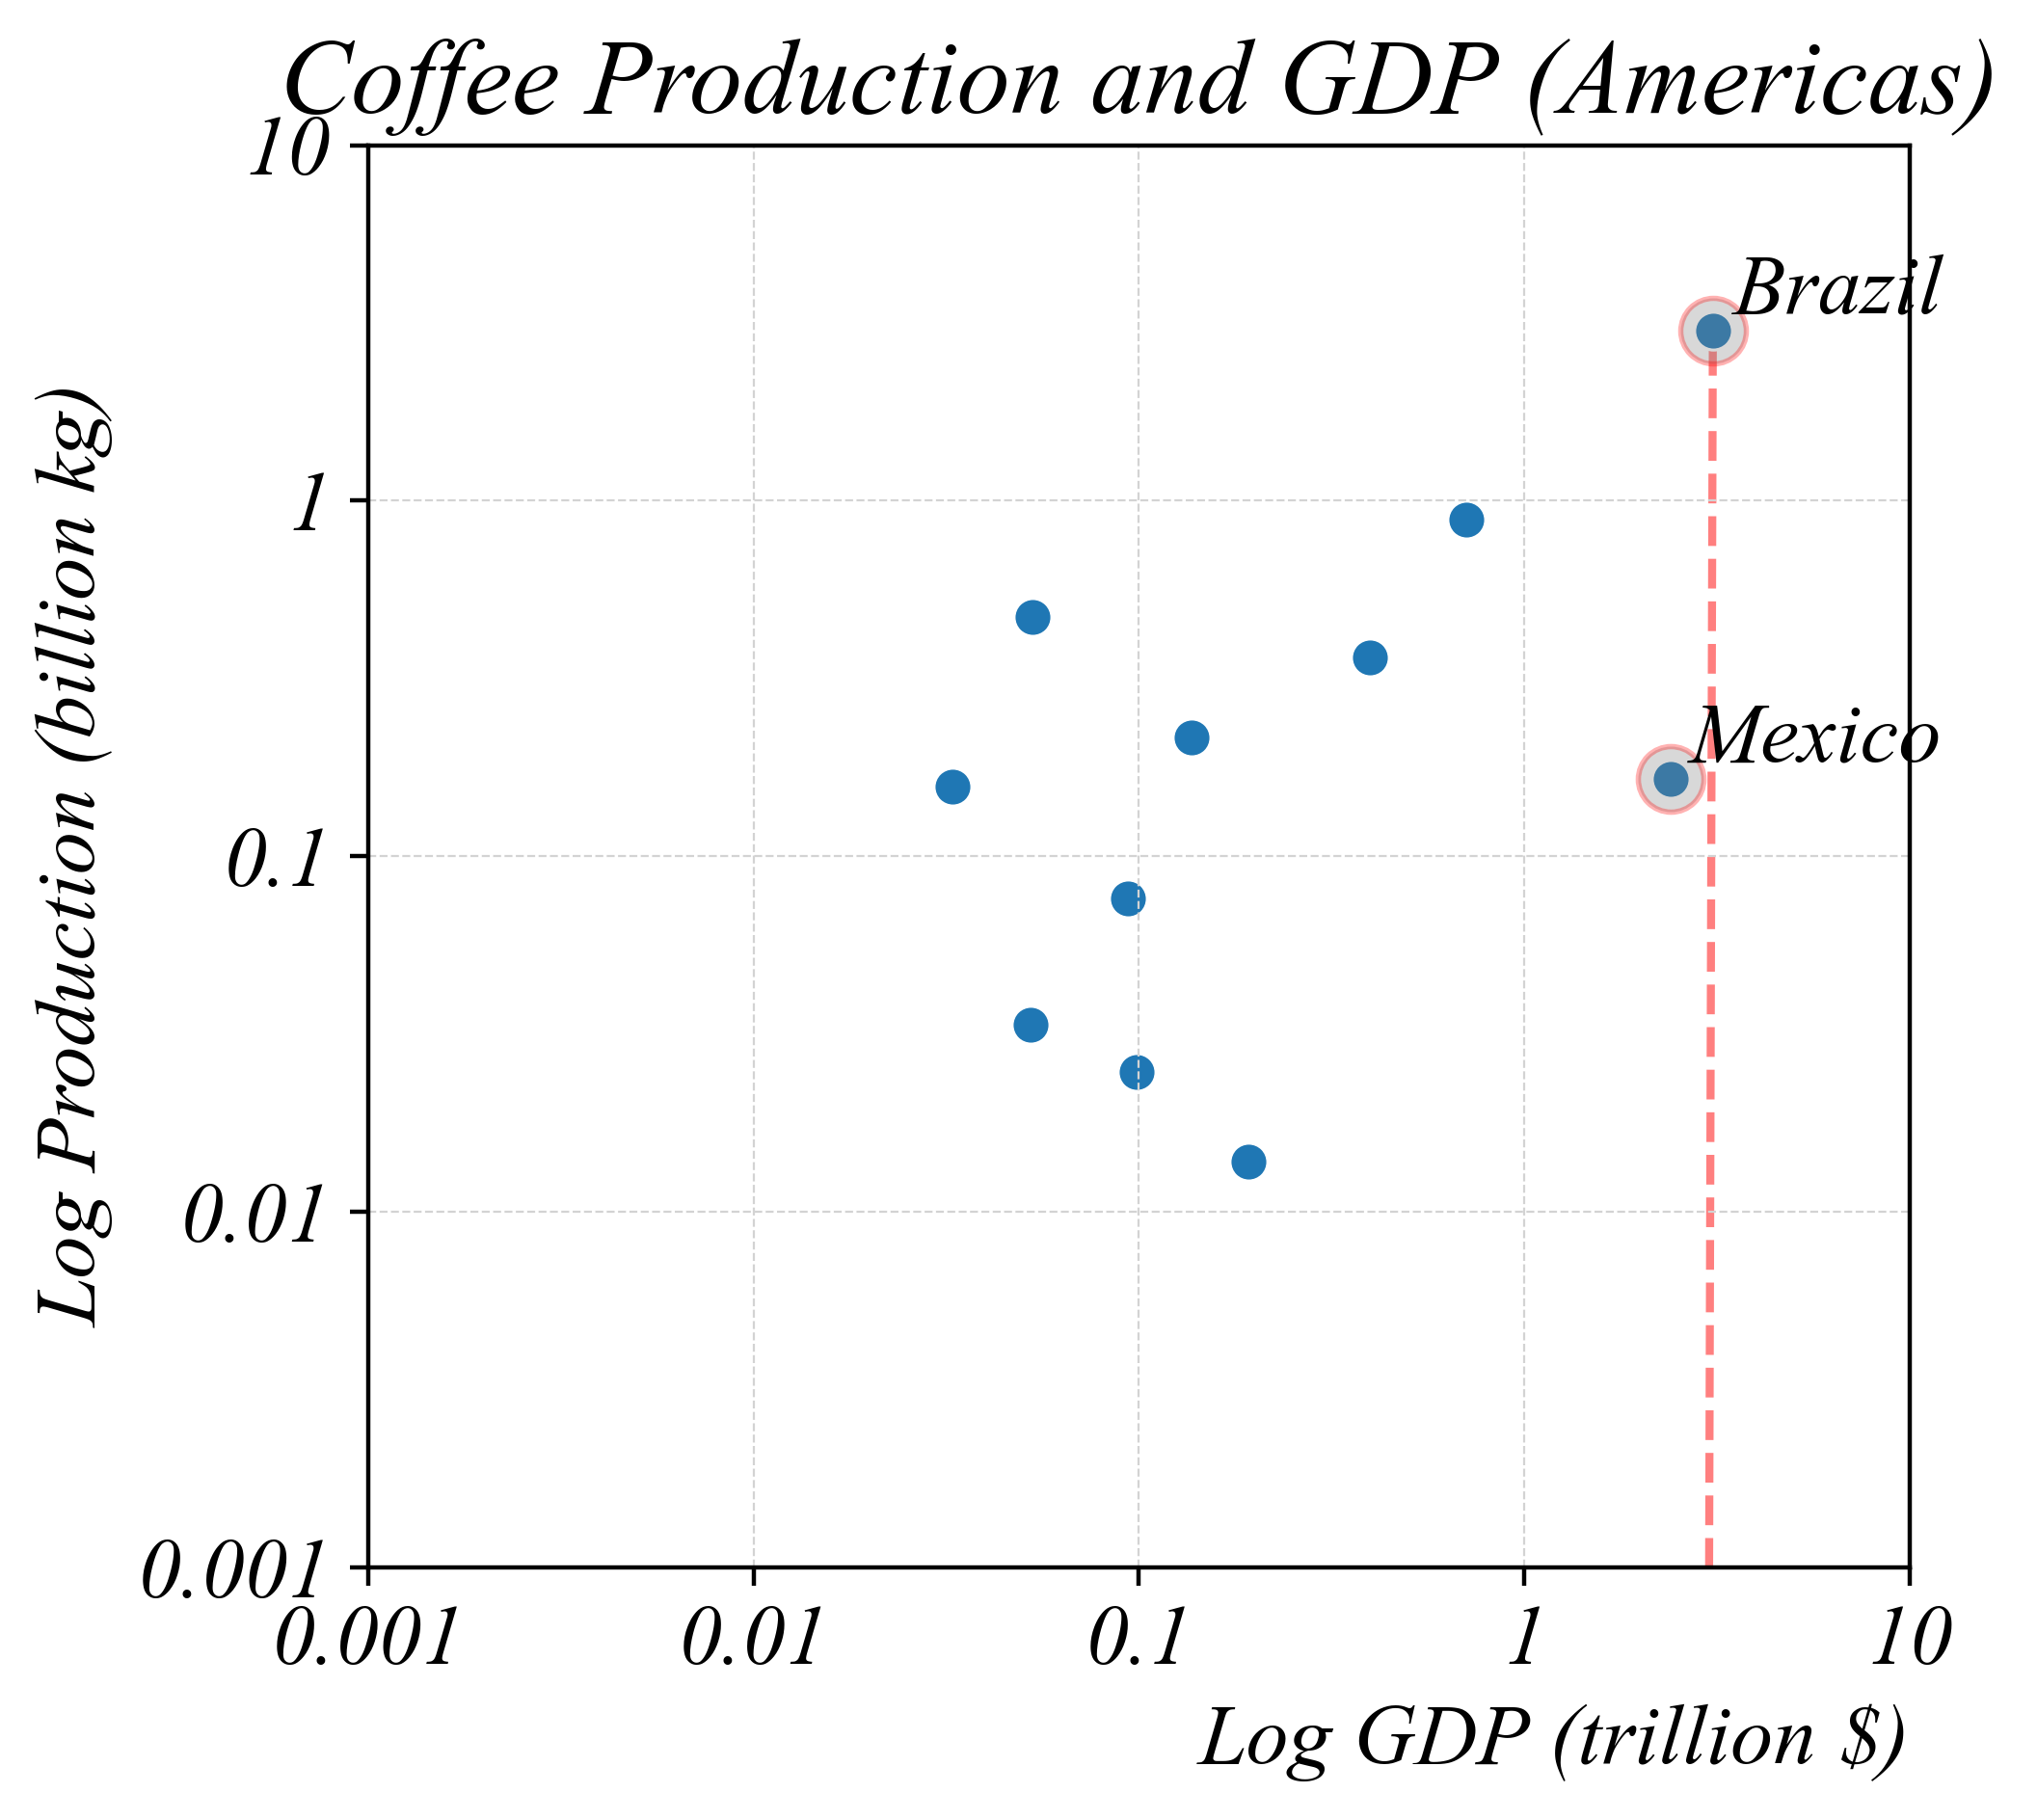

In [23]:
# Data
data = pd.read_csv('../../data/Beans_GDP.csv')
data = data[data['Year'] == 2019]
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)
data['log10_Tonnes'] = np.log10(data['coffee_prod'].replace(0, np.nan) + 1e-10)

americas = ['Bolivia', 'Brazil', 'Colombia', 'Costa Rica', 'Dominican Republic', 'El Salvador', 'Guatemala',
       'Honduras', 'Mexico', 'Nicaragua', 'Peru']
america_data = data[data.Entity.isin(americas)]

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(america_data, x='log10_GDP', y='log10_Tonnes', color='C0', s=50)

america_max = america_data[america_data.log10_Tonnes == america_data.log10_Tonnes.max()]

row_gdp = america_max.iloc[0].log10_GDP
row_tonnes = america_max.iloc[0].log10_Tonnes
row_entity = america_max.iloc[0].Entity

sns.scatterplot(america_max, x='log10_GDP', y='log10_Tonnes', color='grey', edgecolors='red', alpha=0.3, s=150)
plt.annotate(row_entity,(row_gdp, row_tonnes),xytext=(row_gdp+0.05, row_tonnes+0.05))

plt.plot([row_tonnes,row_gdp],[-3,row_gdp], linestyle='--', color='red', zorder=-1, alpha=0.5)

america_data['GDP_dif'] = np.abs(america_data.log10_GDP - row_gdp)
america_dif_min = america_data[america_data['GDP_dif'] == america_data[america_data['GDP_dif'] >0]['GDP_dif'].min()]
plt.scatter(america_dif_min['log10_GDP'], america_dif_min['log10_Tonnes'], color='grey', edgecolors='red', alpha=0.3, s=150)

row_gdp = america_dif_min.iloc[0].log10_GDP
row_tonnes = america_dif_min.iloc[0].log10_Tonnes
row_entity = america_dif_min.iloc[0].Entity

plt.annotate(row_entity,(row_gdp, row_tonnes),xytext=(row_gdp+0.05, row_tonnes+0.05))

# Styling
plt.xlabel('Log GDP (trillion $)', loc='right')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
plt.xticks(ticks=x_ticks, labels=x_ticks_labels)

plt.ylabel('Log Production (billion kg)')
y_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
y_ticks = np.log10(y_ticks_labels)
plt.yticks(ticks=y_ticks, labels=y_ticks_labels)
plt.ylim(-3,1)
plt.title('Coffee Production and GDP (Americas)')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.tight_layout()

# Save Figure
plt.savefig('i/c_16.png')

## Size and Shape Encoding

Adding population and continent to show how to encode additional variables in scatterplots.

In [24]:
# Create enhanced dataset with population and continent
data = pd.read_csv('../../data/Beans_GDP_2019.csv')
data.rename(columns={"coffee_prod": "coffee_prod"}, inplace=True)

# Add population (in millions) and continent for each country
pop_continent = {
    'AGO': {'pop': 32.9, 'continent': 'Africa'},      # Angola
    'BOL': {'pop': 11.7, 'continent': 'Americas'},    # Bolivia
    'BRA': {'pop': 211.0, 'continent': 'Americas'},   # Brazil
    'BDI': {'pop': 11.9, 'continent': 'Africa'},      # Burundi
    'CMR': {'pop': 26.5, 'continent': 'Africa'},      # Cameroon
    'CAF': {'pop': 4.8, 'continent': 'Africa'},       # Central African Republic
    'COL': {'pop': 50.3, 'continent': 'Americas'},    # Colombia
    'CRI': {'pop': 5.1, 'continent': 'Americas'},     # Costa Rica
    'CIV': {'pop': 26.4, 'continent': 'Africa'},      # Cote d'Ivoire
    'COD': {'pop': 89.6, 'continent': 'Africa'},      # DR Congo
    'DOM': {'pop': 10.8, 'continent': 'Americas'},    # Dominican Republic
    'SLV': {'pop': 6.5, 'continent': 'Americas'},     # El Salvador
    'ETH': {'pop': 115.0, 'continent': 'Africa'},     # Ethiopia
    'GTM': {'pop': 17.9, 'continent': 'Americas'},    # Guatemala
    'GIN': {'pop': 13.1, 'continent': 'Africa'},      # Guinea
    'HND': {'pop': 10.0, 'continent': 'Americas'},    # Honduras
    'IDN': {'pop': 273.5, 'continent': 'Asia'},       # Indonesia
    'KEN': {'pop': 53.8, 'continent': 'Africa'},      # Kenya
    'LAO': {'pop': 7.3, 'continent': 'Asia'},         # Laos
    'MDG': {'pop': 27.7, 'continent': 'Africa'},      # Madagascar
    'MWI': {'pop': 19.1, 'continent': 'Africa'},      # Malawi
    'MEX': {'pop': 128.9, 'continent': 'Americas'},   # Mexico
    'NIC': {'pop': 6.6, 'continent': 'Americas'},     # Nicaragua
    'PER': {'pop': 33.0, 'continent': 'Americas'},    # Peru
    'PHL': {'pop': 109.6, 'continent': 'Asia'},       # Philippines
    'RWA': {'pop': 13.0, 'continent': 'Africa'},      # Rwanda
    'TZA': {'pop': 59.7, 'continent': 'Africa'},      # Tanzania
    'THA': {'pop': 69.8, 'continent': 'Asia'},        # Thailand
    'TGO': {'pop': 8.3, 'continent': 'Africa'},       # Togo
    'UGA': {'pop': 45.7, 'continent': 'Africa'},      # Uganda
    'VNM': {'pop': 97.3, 'continent': 'Asia'},        # Vietnam
    'YEM': {'pop': 29.8, 'continent': 'Asia'},        # Yemen
}

data['population'] = data['Code'].map(lambda x: pop_continent.get(x, {}).get('pop', 0))
data['continent'] = data['Code'].map(lambda x: pop_continent.get(x, {}).get('continent', 'Unknown'))

# Save enhanced dataset
data.to_csv('../../data/Beans_GDP_2019_enhanced.csv', index=False)
print(data[['Entity', 'GDP', 'coffee_prod', 'population', 'continent']].head(10))

                         Entity       GDP  coffee_prod  population continent
0                        Angola  0.227856     0.013257        32.9    Africa
1                       Bolivia  0.098836     0.024841        11.7  Americas
2                        Brazil  3.080049     3.011745       211.0  Americas
3                       Burundi  0.009110     0.014059        11.9    Africa
4                      Cameroon  0.094488     0.034061        26.5    Africa
5      Central African Republic  0.004642     0.202753         4.8    Africa
6                      Colombia  0.707660     0.885120        50.3  Americas
7                    Costa Rica  0.093492     0.076385         5.1  Americas
8                 Cote d'Ivoire  0.129492     0.095204        26.4    Africa
9  Democratic Republic of Congo  0.088673     0.052940        89.6    Africa


In [25]:
# Create enhanced dataset with population and continent
data = pd.read_csv('../../data/Beans_GDP_1980_raw.csv', index_col=0)
data.rename(columns={"coffee_prod": "coffee_prod"}, inplace=True)
data.head()

# Add population (in millions) and continent for each country
pop_continent = {
    'AGO': {'pop': 32.9, 'continent': 'Africa'},      # Angola
    'BOL': {'pop': 11.7, 'continent': 'Americas'},    # Bolivia
    'BRA': {'pop': 211.0, 'continent': 'Americas'},   # Brazil
    'BDI': {'pop': 11.9, 'continent': 'Africa'},      # Burundi
    'CMR': {'pop': 26.5, 'continent': 'Africa'},      # Cameroon
    'CAF': {'pop': 4.8, 'continent': 'Africa'},       # Central African Republic
    'COL': {'pop': 50.3, 'continent': 'Americas'},    # Colombia
    'CRI': {'pop': 5.1, 'continent': 'Americas'},     # Costa Rica
    'CIV': {'pop': 26.4, 'continent': 'Africa'},      # Cote d'Ivoire
    'COD': {'pop': 89.6, 'continent': 'Africa'},      # DR Congo
    'DOM': {'pop': 10.8, 'continent': 'Americas'},    # Dominican Republic
    'SLV': {'pop': 6.5, 'continent': 'Americas'},     # El Salvador
    'ETH': {'pop': 115.0, 'continent': 'Africa'},     # Ethiopia
    'GTM': {'pop': 17.9, 'continent': 'Americas'},    # Guatemala
    'GIN': {'pop': 13.1, 'continent': 'Africa'},      # Guinea
    'HND': {'pop': 10.0, 'continent': 'Americas'},    # Honduras
    'IDN': {'pop': 273.5, 'continent': 'Asia'},       # Indonesia
    'KEN': {'pop': 53.8, 'continent': 'Africa'},      # Kenya
    'LAO': {'pop': 7.3, 'continent': 'Asia'},         # Laos
    'MDG': {'pop': 27.7, 'continent': 'Africa'},      # Madagascar
    'MWI': {'pop': 19.1, 'continent': 'Africa'},      # Malawi
    'MEX': {'pop': 128.9, 'continent': 'Americas'},   # Mexico
    'NIC': {'pop': 6.6, 'continent': 'Americas'},     # Nicaragua
    'PER': {'pop': 33.0, 'continent': 'Americas'},    # Peru
    'PHL': {'pop': 109.6, 'continent': 'Asia'},       # Philippines
    'RWA': {'pop': 13.0, 'continent': 'Africa'},      # Rwanda
    'TZA': {'pop': 59.7, 'continent': 'Africa'},      # Tanzania
    'THA': {'pop': 69.8, 'continent': 'Asia'},        # Thailand
    'TGO': {'pop': 8.3, 'continent': 'Africa'},       # Togo
    'UGA': {'pop': 45.7, 'continent': 'Africa'},      # Uganda
    'VNM': {'pop': 97.3, 'continent': 'Asia'},        # Vietnam
    'YEM': {'pop': 29.8, 'continent': 'Asia'},        # Yemen
}

data['population'] = data['Code'].map(lambda x: pop_continent.get(x, {}).get('pop', 0))
data['continent'] = data['Code'].map(lambda x: pop_continent.get(x, {}).get('continent', 'Unknown'))

# Save enhanced dataset
data.to_csv('../../data/Beans_GDP_1980.csv', index=True)
print(data[['Entity', 'GDP', 'coffee_prod', 'population', 'continent']].head(10))

                           Entity       GDP  coffee_prod  population continent
10                         Angola  0.028927     0.043260        32.9    Africa
150                       Bolivia  0.013809     0.020540        11.7  Americas
209                        Brazil  0.709314     1.061195       211.0  Americas
268                       Burundi  0.004061     0.018894        11.9    Africa
377                      Cameroon  0.020713     0.112207        26.5    Africa
477      Central African Republic  0.002507     0.016808         4.8    Africa
595                      Colombia  0.209898     0.724380        50.3  Americas
772                    Costa Rica  0.020820     0.106389         5.1  Americas
831                 Cote d'Ivoire  0.021423     0.249608        26.4    Africa
890  Democratic Republic of Congo  0.057590     0.089000        89.6    Africa


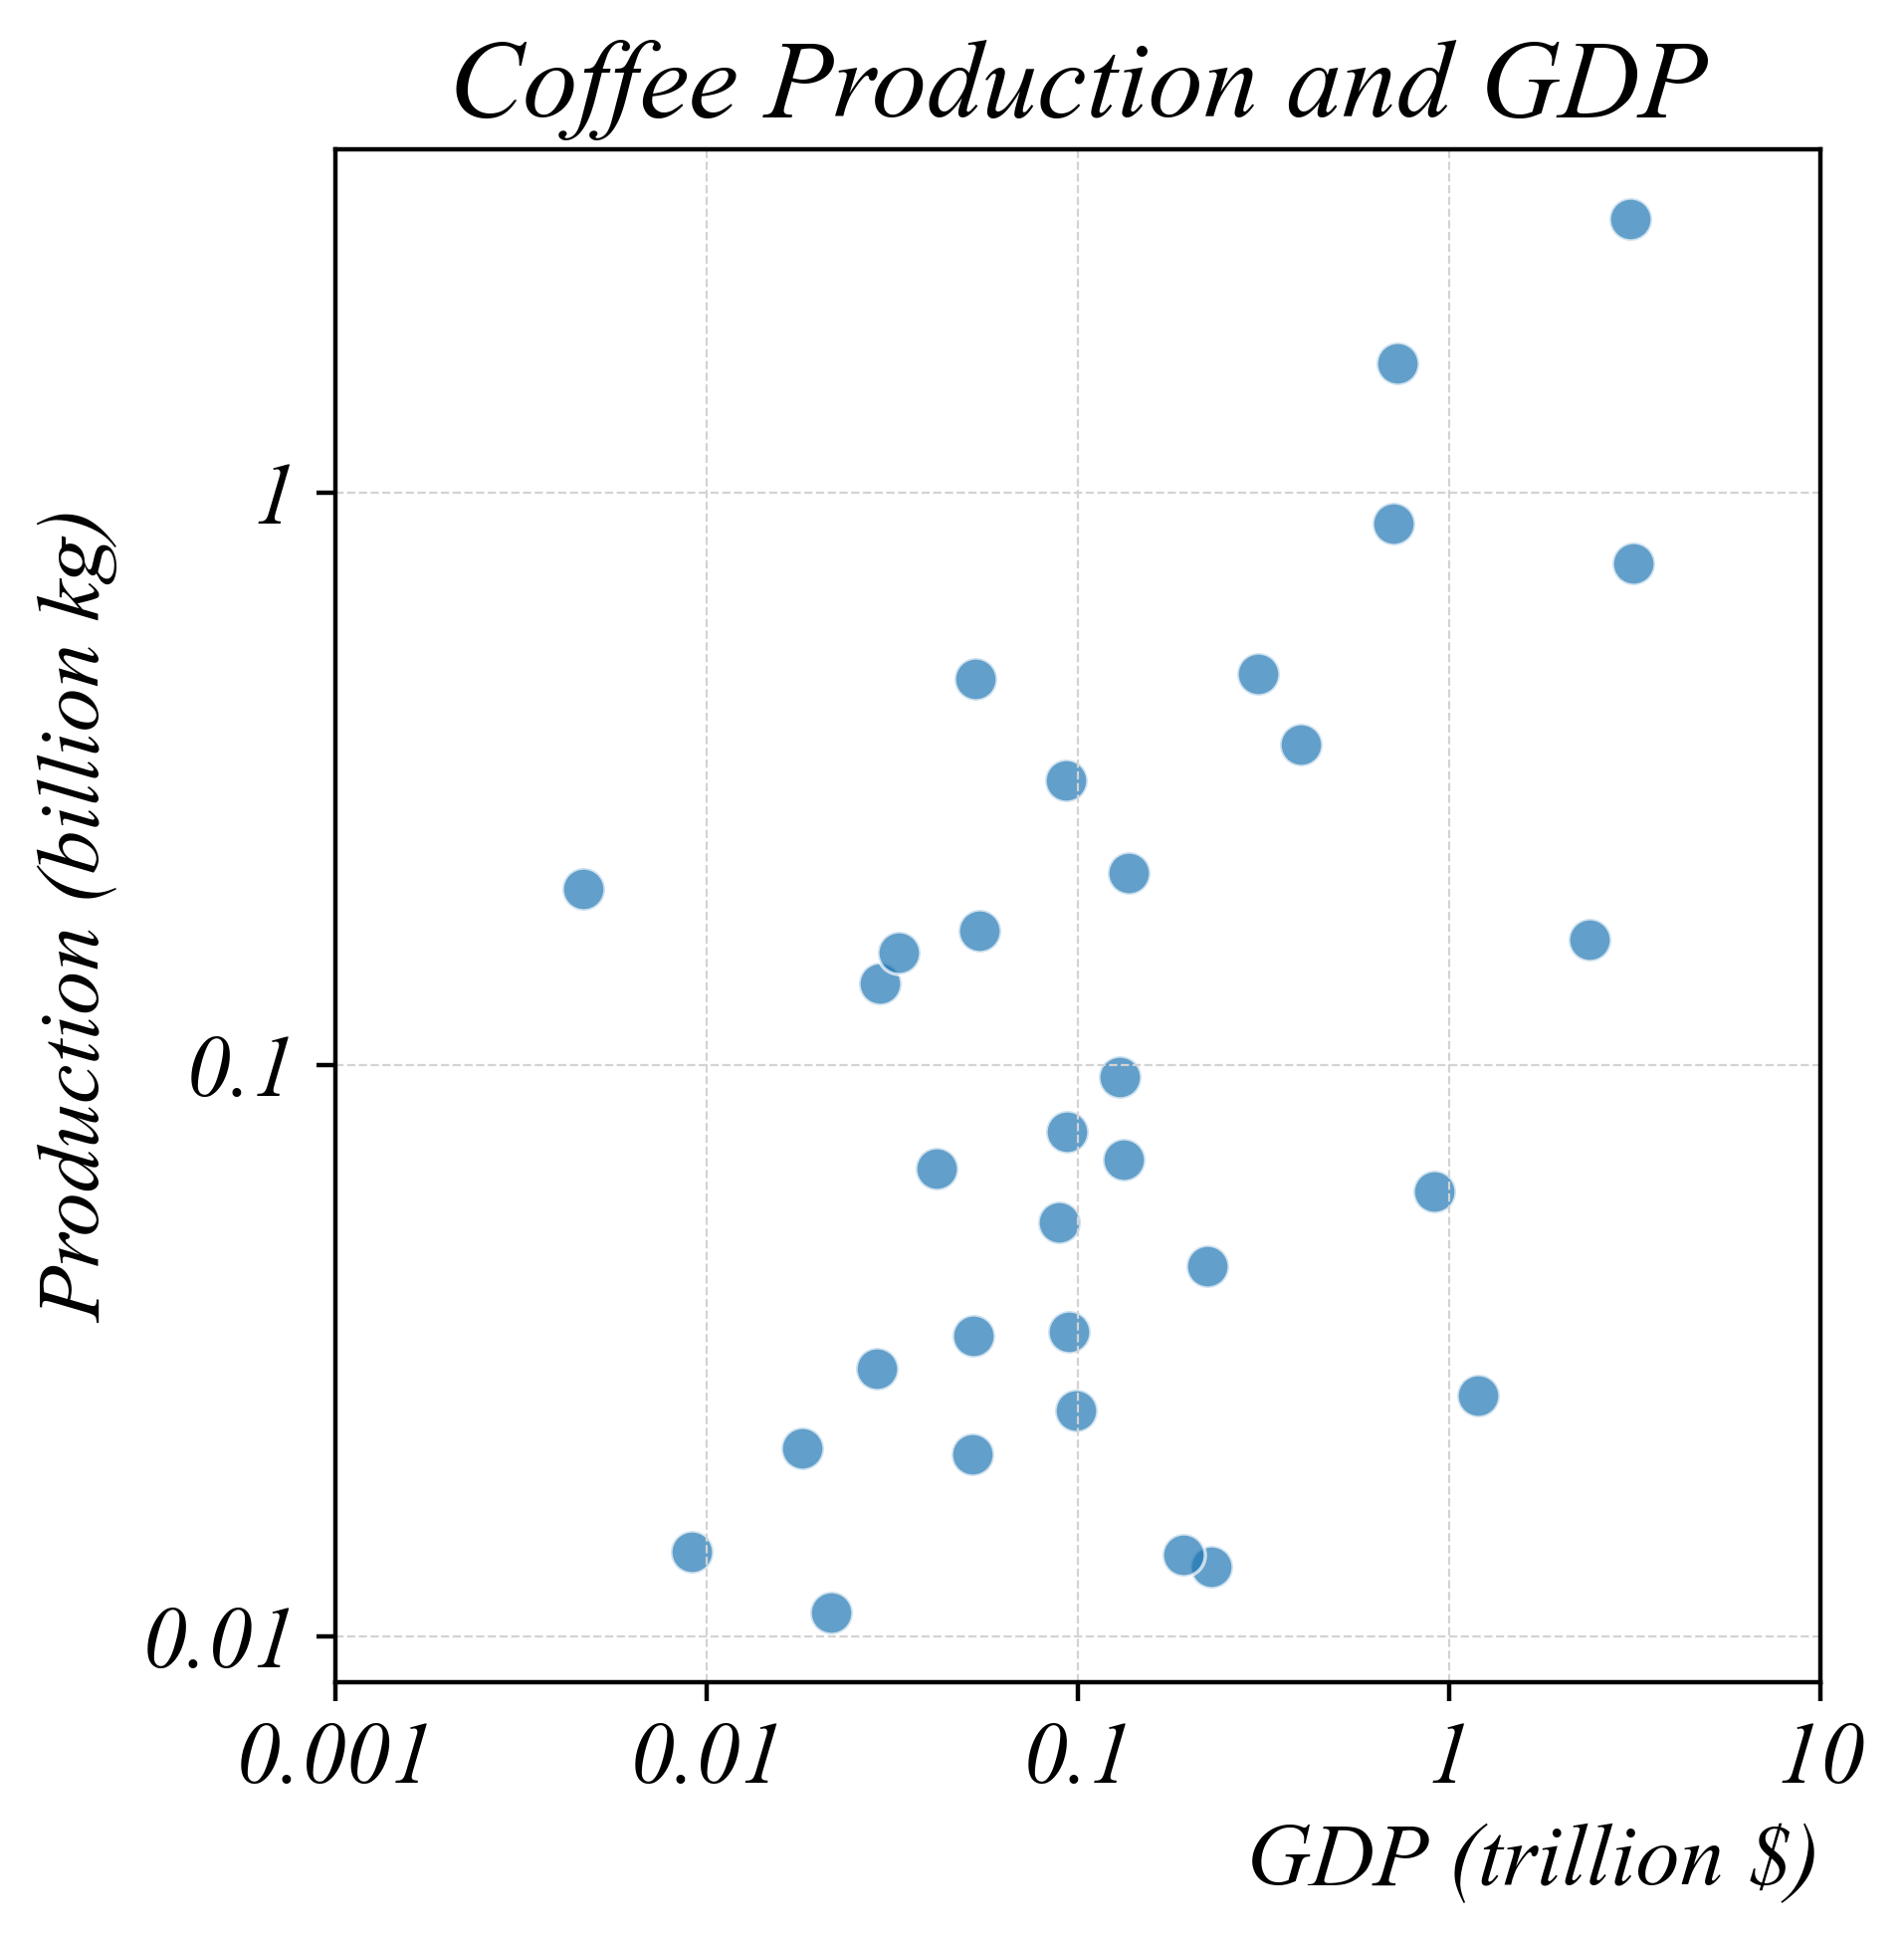

In [42]:
# Figure e_01: Basic scatterplot (reference) - LOG SCALE
data = pd.read_csv('../../data/Beans_GDP_2019_enhanced.csv')
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)
data['log10_coffee'] = np.log10(data['coffee_prod'].replace(0, np.nan) + 1e-10)

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='log10_GDP', y='log10_coffee', alpha=0.7, s=60)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
plt.xticks(ticks=x_ticks, labels=x_ticks_labels)

plt.ylabel('Production (billion kg)')
y_ticks_labels = [0.01, 0.1, 1]
y_ticks = np.log10(y_ticks_labels)
plt.yticks(ticks=y_ticks, labels=y_ticks_labels)

plt.title('Coffee Production and GDP')
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.savefig('i/e_01.png', dpi=300)
plt.show()

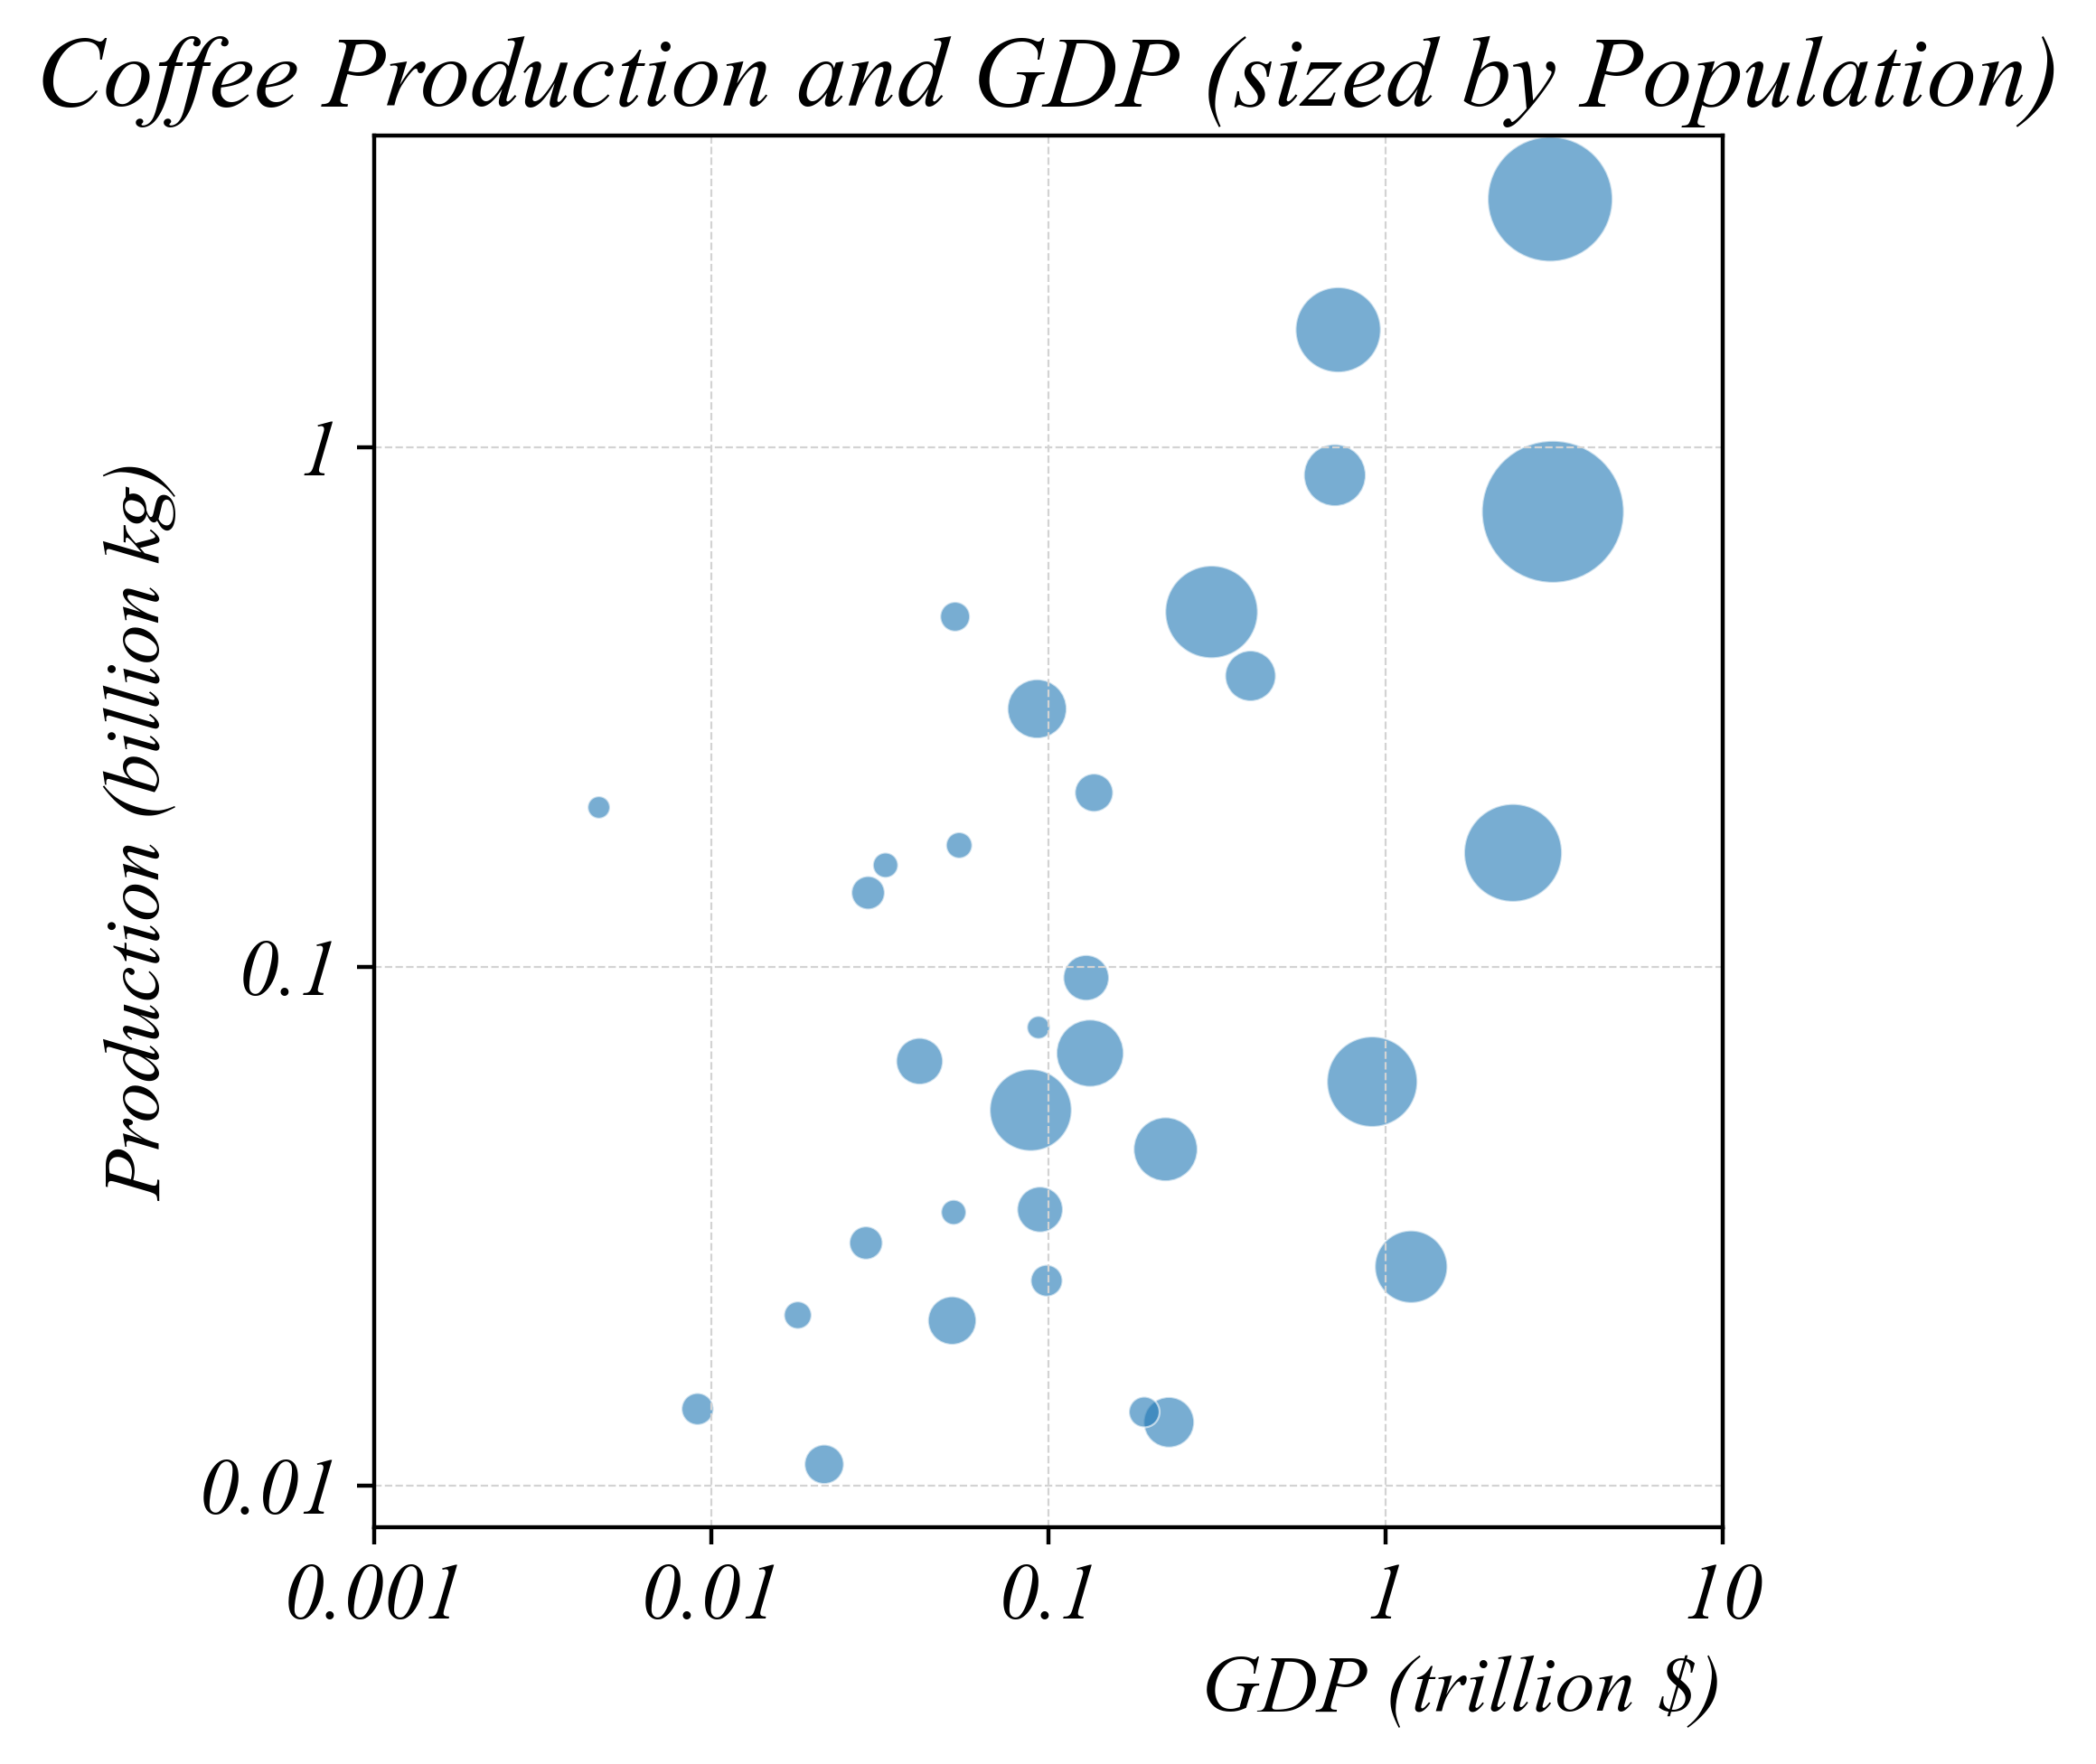

In [27]:
# Figure e_02: Bubble chart (size = population) - LOG SCALE
data = pd.read_csv('../../data/Beans_GDP_2019_enhanced.csv')
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)
data['log10_coffee'] = np.log10(data['coffee_prod'].replace(0, np.nan) + 1e-10)

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='log10_GDP', y='log10_coffee', size='population', sizes=(20, 800), 
                alpha=0.6, legend=False)

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
plt.xticks(ticks=x_ticks, labels=x_ticks_labels)

plt.ylabel('Production (billion kg)')
y_ticks_labels = [0.01, 0.1, 1]
y_ticks = np.log10(y_ticks_labels)
plt.yticks(ticks=y_ticks, labels=y_ticks_labels)

plt.title('Coffee Production and GDP (sized by Population)')
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.savefig('i/e_02.png', dpi=300)
plt.show()

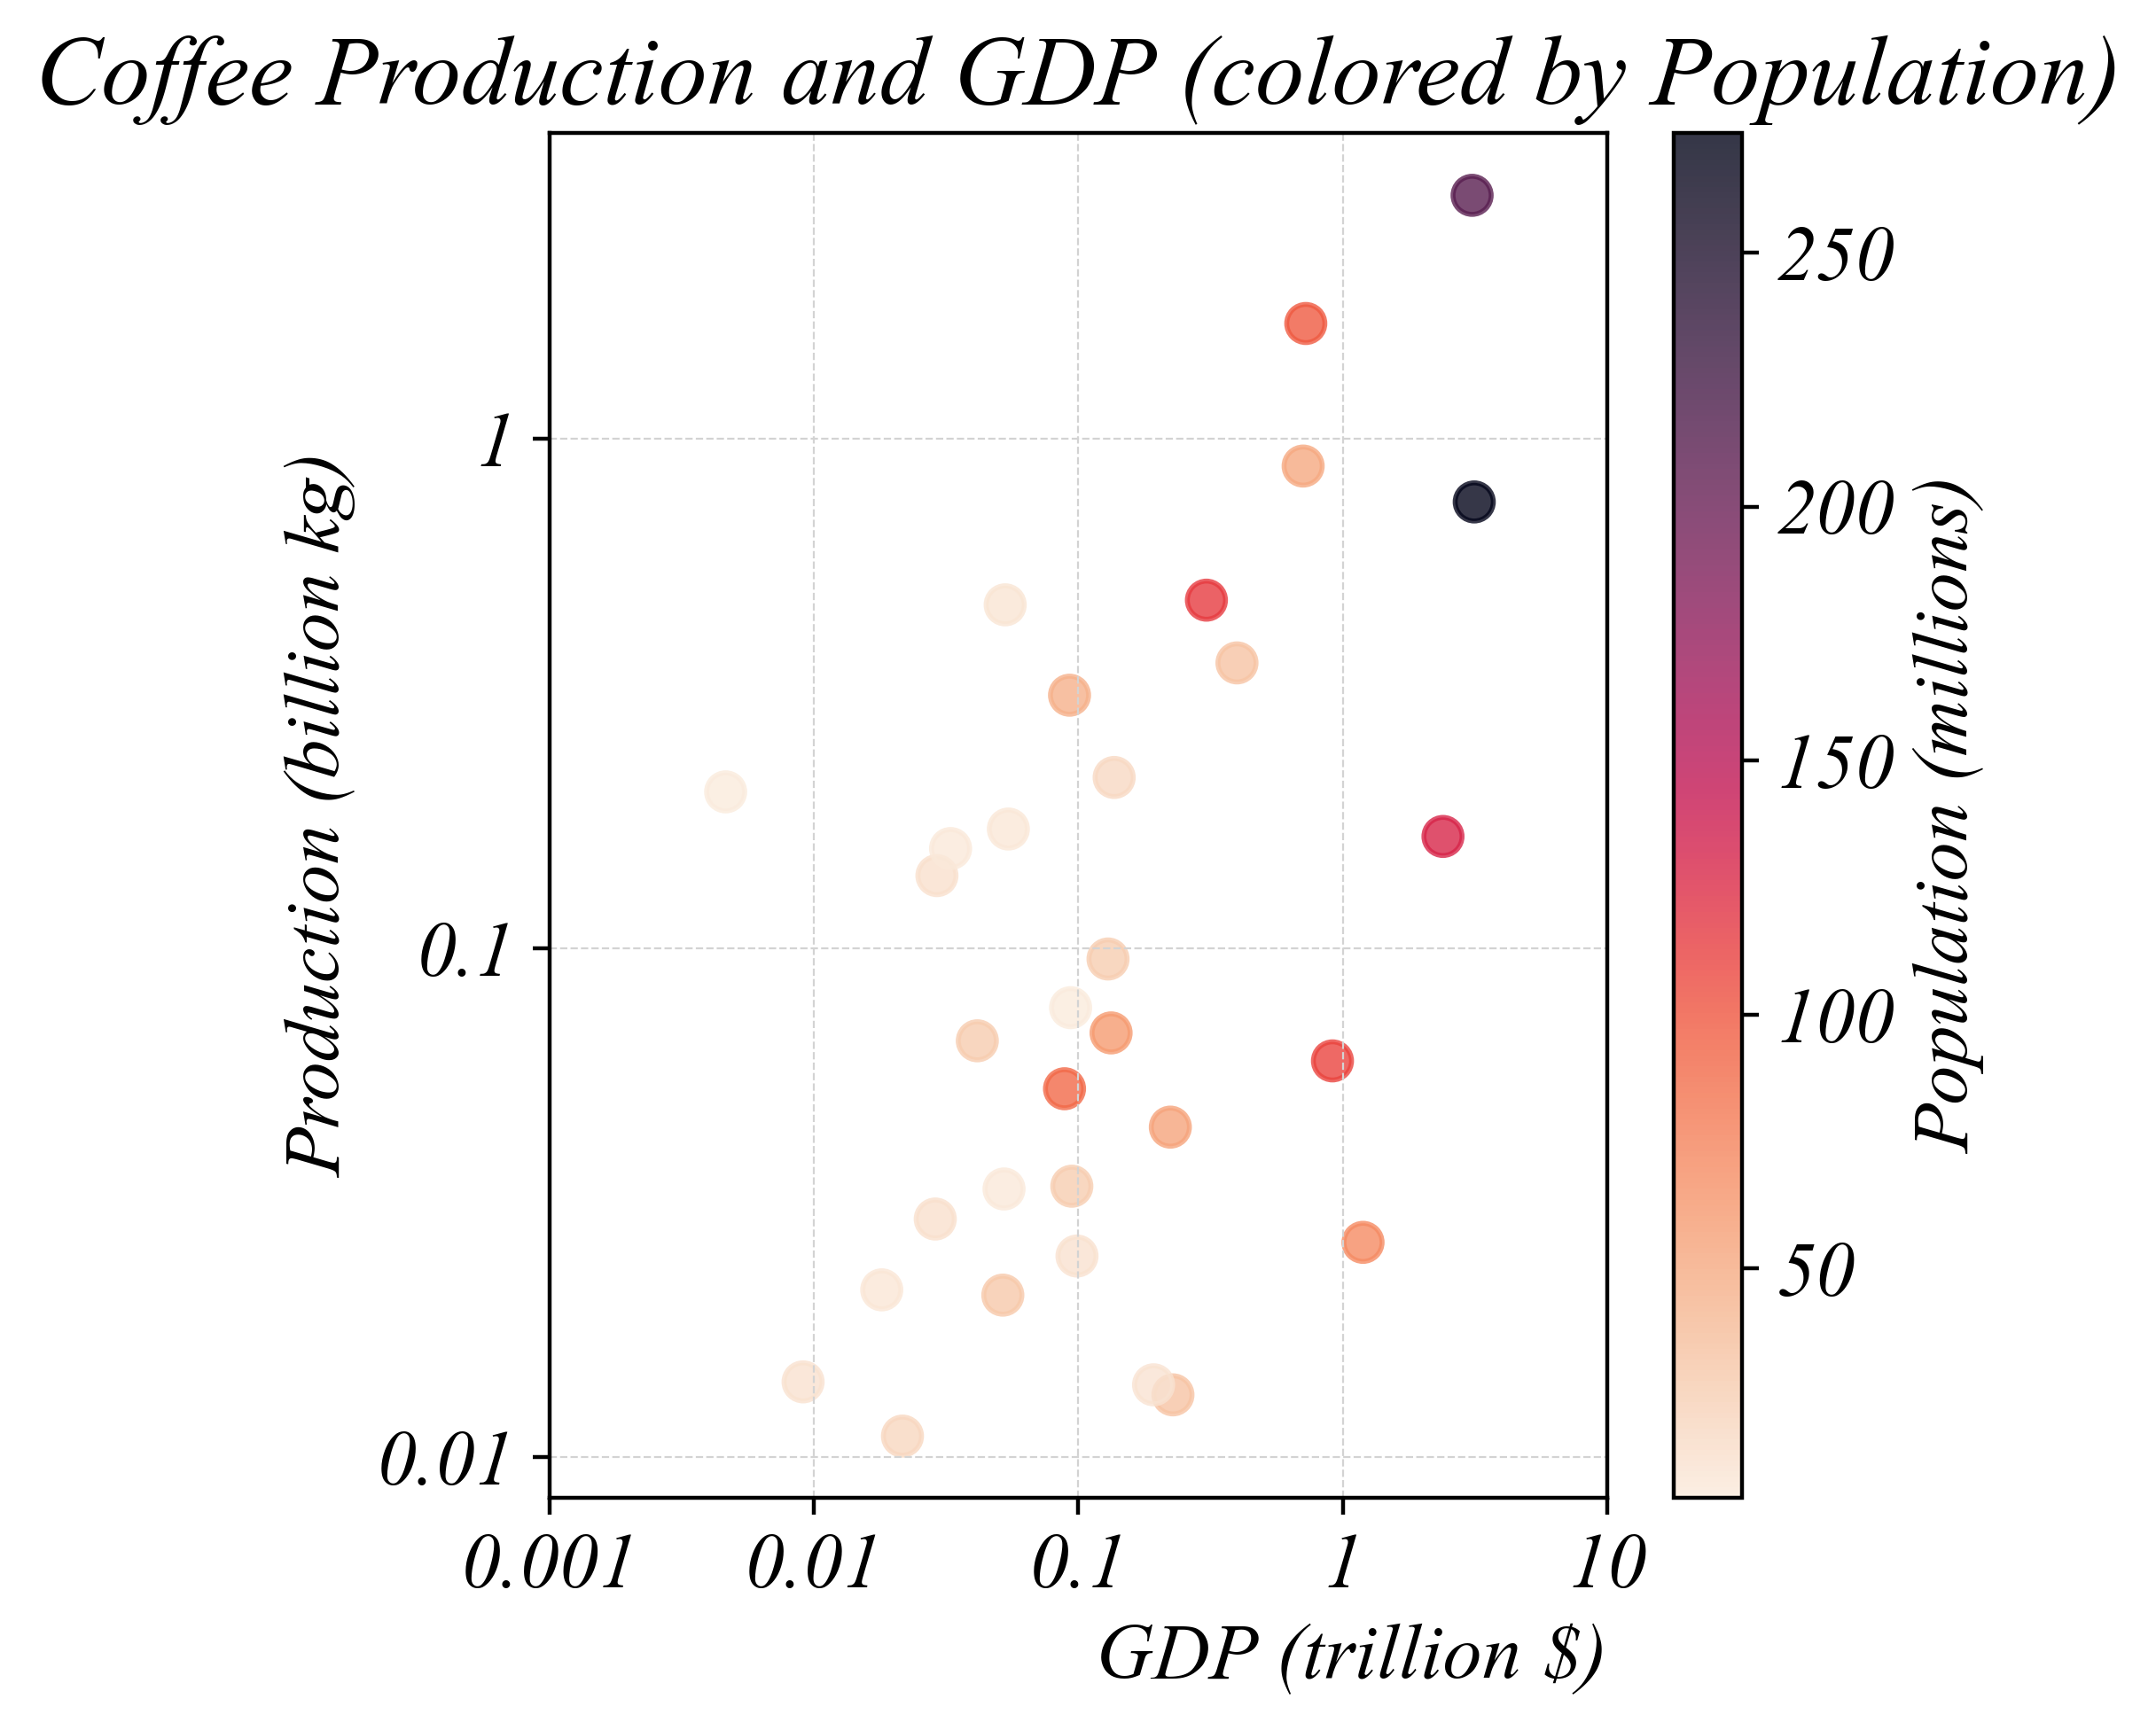

In [43]:
# Figure e_07: Color encoding (population as continuous color) - LOG SCALE
data = pd.read_csv('../../data/Beans_GDP_2019_enhanced.csv')
data['log10_GDP'] = np.log10(data['GDP'].replace(0, np.nan) + 1e-10)
data['log10_coffee'] = np.log10(data['coffee_prod'].replace(0, np.nan) + 1e-10)

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
ax = fig.add_subplot(gs[0, 1])

scatter = ax.scatter(data['log10_GDP'], data['log10_coffee'], c=data['population'], 
                     cmap='rocket_r', s=60, alpha=0.8)

plt.colorbar(scatter, label='Population (millions)')

# Styling
plt.xlabel('GDP (trillion $)', loc='right')
x_ticks_labels = [0.001, 0.01, 0.1, 1, 10]
x_ticks = np.log10(x_ticks_labels)
plt.xticks(ticks=x_ticks, labels=x_ticks_labels)

plt.ylabel('Production (billion kg)')
y_ticks_labels = [0.01, 0.1, 1]
y_ticks = np.log10(y_ticks_labels)
plt.yticks(ticks=y_ticks, labels=y_ticks_labels)

plt.title('Coffee Production and GDP (colored by Population)')
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.savefig('i/e_07.png', dpi=300)
plt.show()

## Coffee Consumption

#### Datasets

In [29]:
cpi = pd.read_csv('../../data/CPI_raw.csv')

cpi.Year = cpi.Year.astype(int)
cpi = cpi[cpi.Year >= 1970]
cpi['I'] = cpi['Annual Percent Change (rate of inflation)'].str.replace('%', '').astype(float)/100
cpi['cpi'] = cpi['Annual Average CPI(-U)'].astype(float)

""" 1970's Dollar """

# To find out how much a price in Year 1 would be in Year 2 dollars:
# Year 2 Price = Year 1 Price x (Year 2 CPI/Year 1 CPI)

price_base = 1
values = []
i_base = cpi['cpi'].values[0]
for i in cpi['cpi'].values:
    price = price_base * (i/i_base)
    values.append(price)
cpi['base'] = values

""" Today's Dollar """

# To find out how much a price in Year 1 would be in Year 2 dollars:
# Year 2 Price = Year 1 Price x (Year 2 CPI/Year 1 CPI)

price_base = 1
values = []
i_base = cpi['cpi'].values[-1]
for i in cpi['cpi'].values:
    price = price_base * (i/i_base)
    values.append(price)
cpi['today'] = values

cpi.to_csv('../../data/CPI.csv')

In [30]:
data = pd.read_csv('../../data/Daily_Coffee_Prices.csv', index_col=0)
data['date_column'] = pd.to_datetime(data['date'], format='%m/%d/%y')
data['year'] = data['date_column'].dt.year
data = data[(data['year'] < 2023)]

cpi = pd.read_csv('../../data/CPI.csv')

today_list = []
cpi_list = []
for i,row in data.iterrows():
    cpi_year = cpi[cpi.Year == row.year]
    year = row.year
    today_list.append(cpi_year.today.iloc[0])
    cpi_list.append(cpi_year.cpi.iloc[0])
    
data['today'] = today_list
data['cpi'] = cpi_list
data.to_csv('../../data/Coffee_Prices_CPI.csv')

In [31]:
data = pd.read_csv('../../data/Coffee_Prices.csv')
data = data.rename(columns={' value': 'price'})

data['date'] = pd.to_datetime(data['date'], format='%m/%d/%y')
data['date'] = data['date'].dt.to_period('M')

monthly_avg = data.groupby('date')['price'].mean().reset_index()

monthly_avg.to_csv('../../data/Monthly_Coffee_Prices.csv')

In [32]:
data = pd.read_csv('../../data/Coffee_Prices.csv')
data = data.rename(columns={' value': 'price'})

data.to_csv('../../data/Daily_Coffee_Prices.csv')

#### Figures

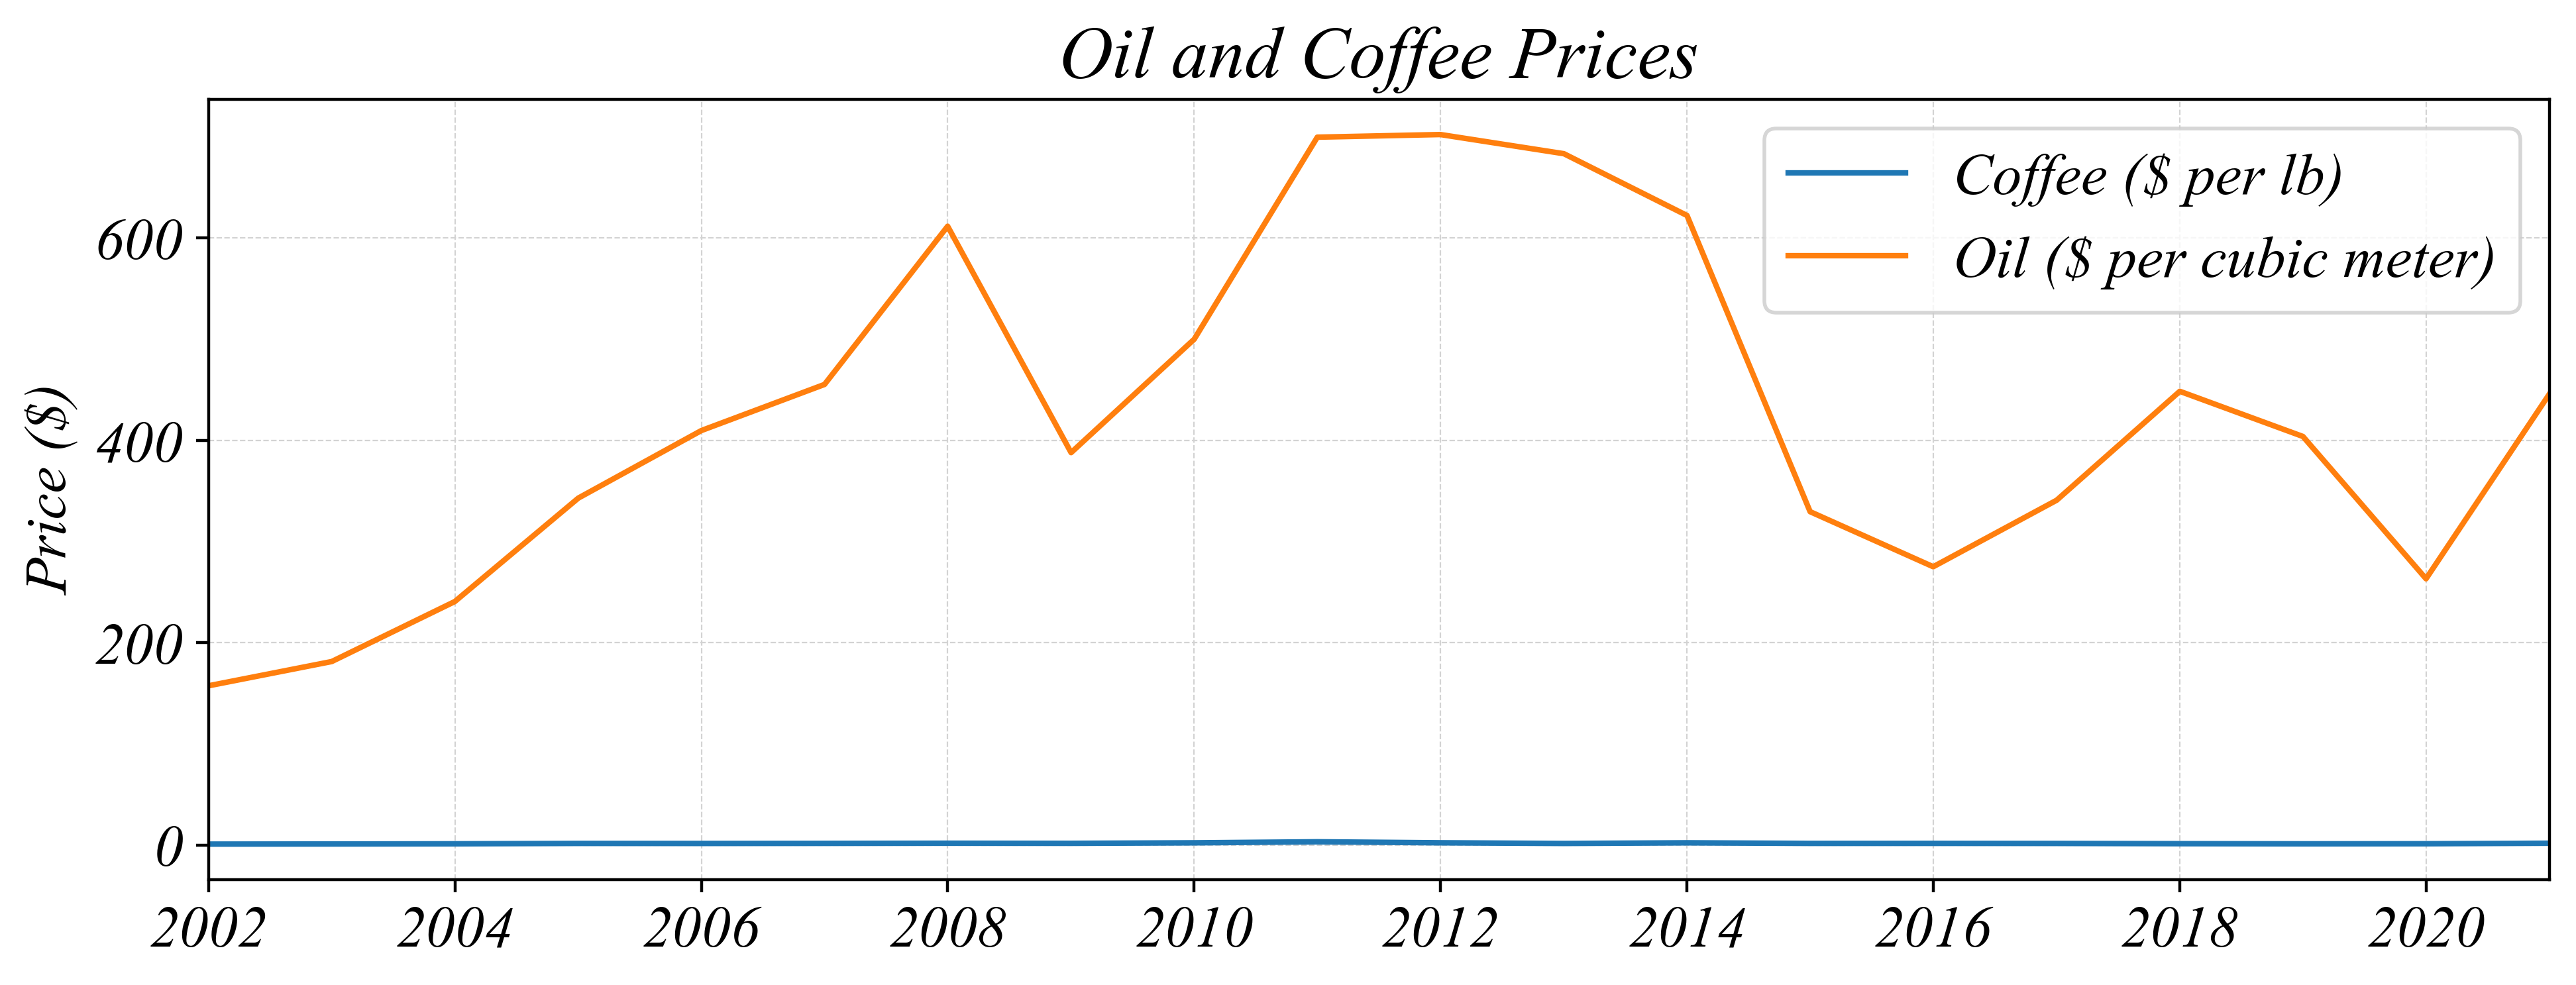

In [33]:
import matplotlib.dates as mdates

# Data
data = pd.read_csv('../../data/Coffee_Oil.csv')
data['date_column'] = pd.to_datetime(data['Year'], format='%Y')

# Figure
plt.figure(figsize=(10, 4))

sns.lineplot(data, x='date_column', y='Coffee', label='Coffee ($ per lb)')
sns.lineplot(data, x='date_column', y='Oil', label='Oil ($ per cubic meter)')

# Styling
plt.xlabel('')
plt.xlim(pd.Timestamp('2002-01-01'), pd.Timestamp('2021-01-01'))
plt.ylabel('Price ($)')

plt.title('Oil and Coffee Prices')
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
plt.legend()
plt.tight_layout()

plt.savefig('i/c_18.png')

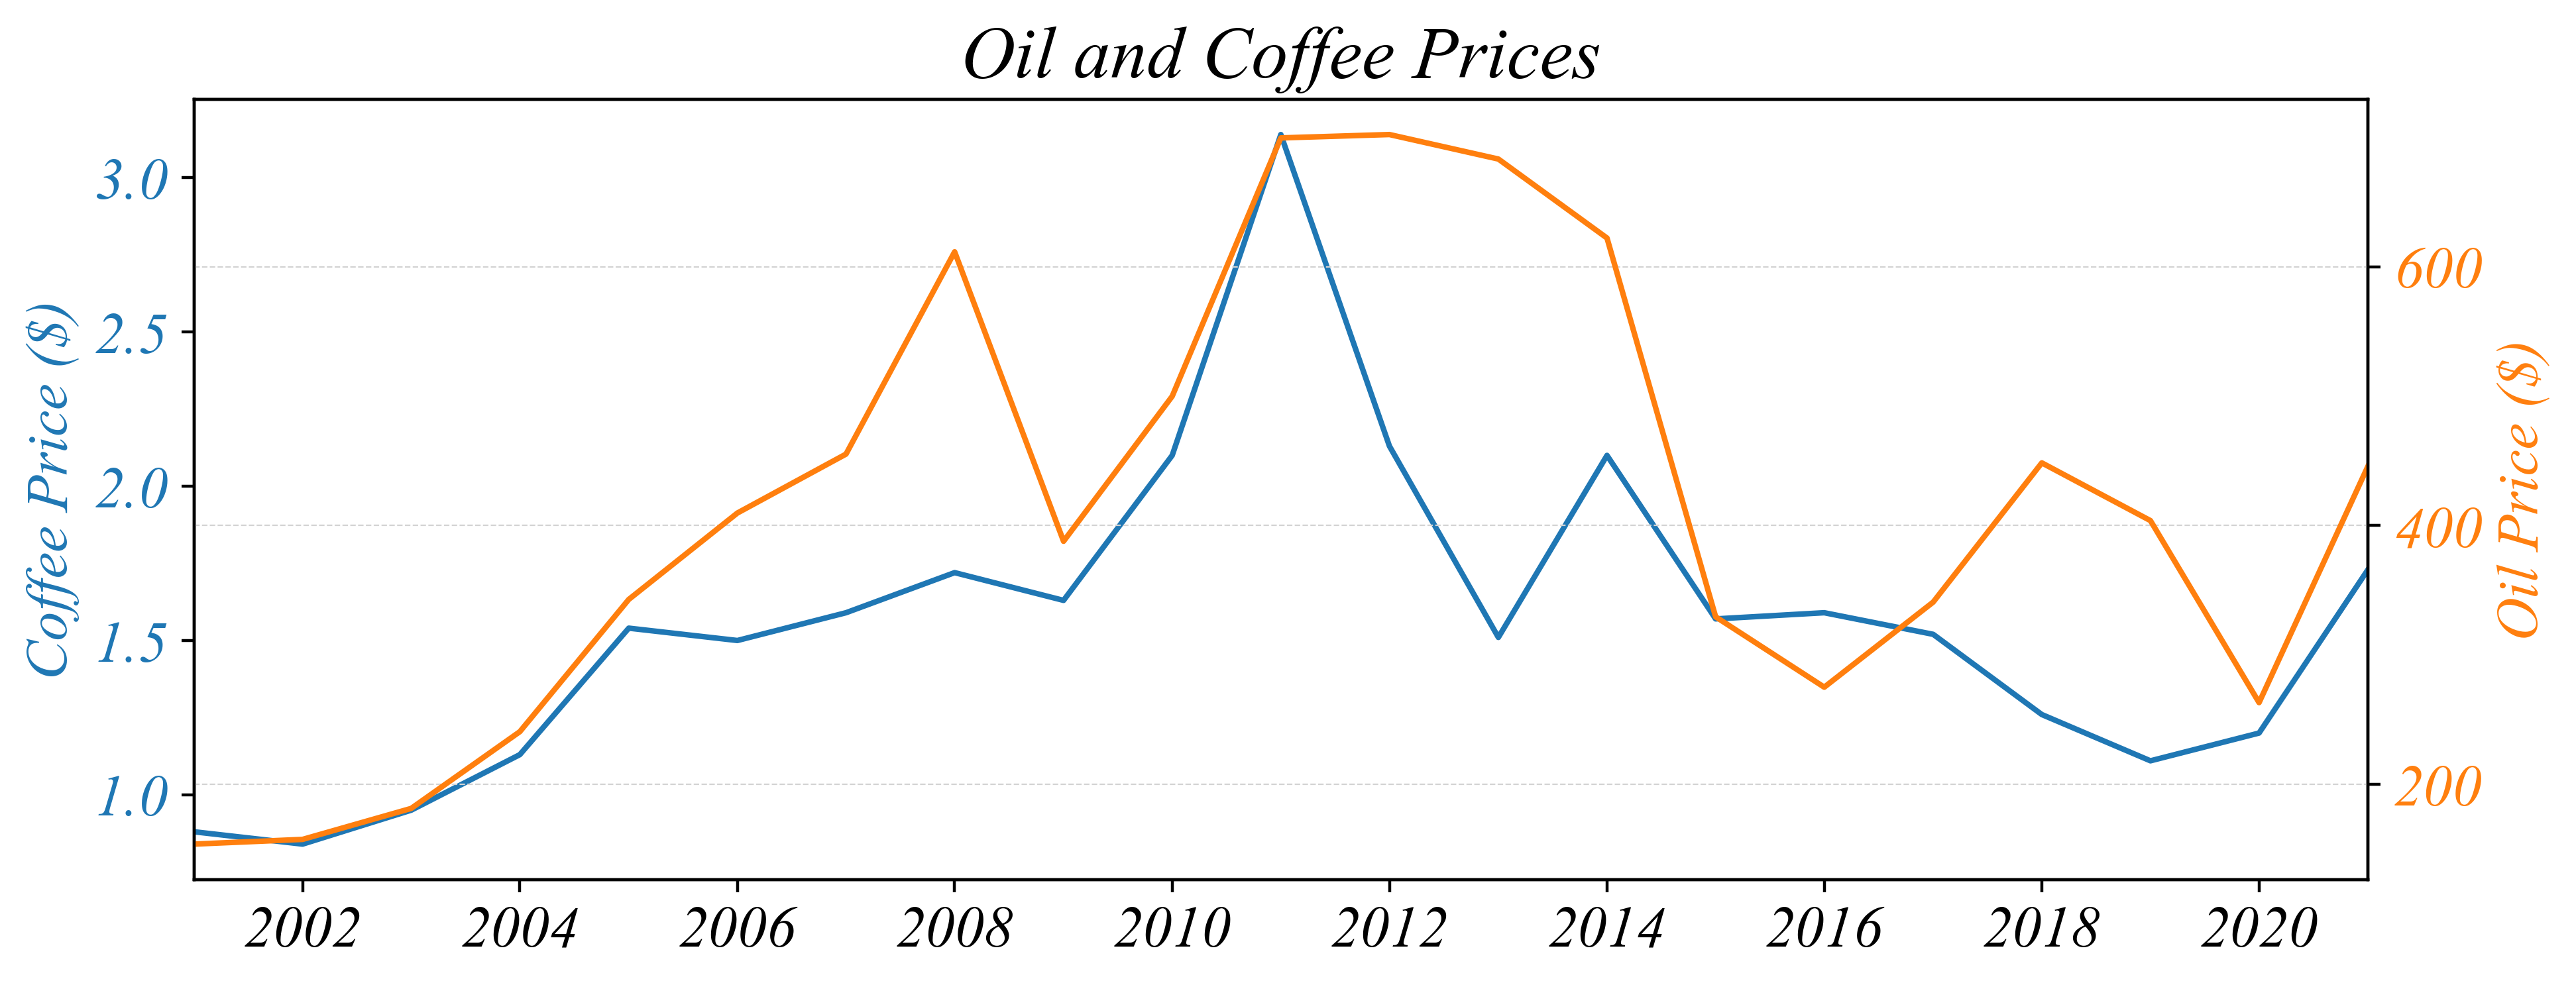

In [34]:
import matplotlib.dates as mdates

# Data
data = pd.read_csv('../../data/Coffee_Oil.csv')
data['date_column'] = pd.to_datetime(data['Year'], format='%Y')

# Figure
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot Coffee prices on the first y-axis
ax1.plot(data['date_column'], data['Coffee'], label='Coffee ($ per lb)', color='tab:blue')
ax1.set_xlabel('')
ax1.set_xlim(data['date_column'].min(), data['date_column'].max())
ax1.set_ylabel('Coffee Price ($)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis
ax2 = ax1.twinx()

# Plot Oil prices on the second y-axis
ax2.plot(data['date_column'], data['Oil'], label='Oil ($ per cubic meter)', color='tab:orange')
ax2.set_ylabel('Oil Price ($)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Add title and legend
plt.title('Oil and Coffee Prices')
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
fig.tight_layout()  # Adjust layout to prevent overlap

# Save Figure
plt.savefig('i/c_19.png')

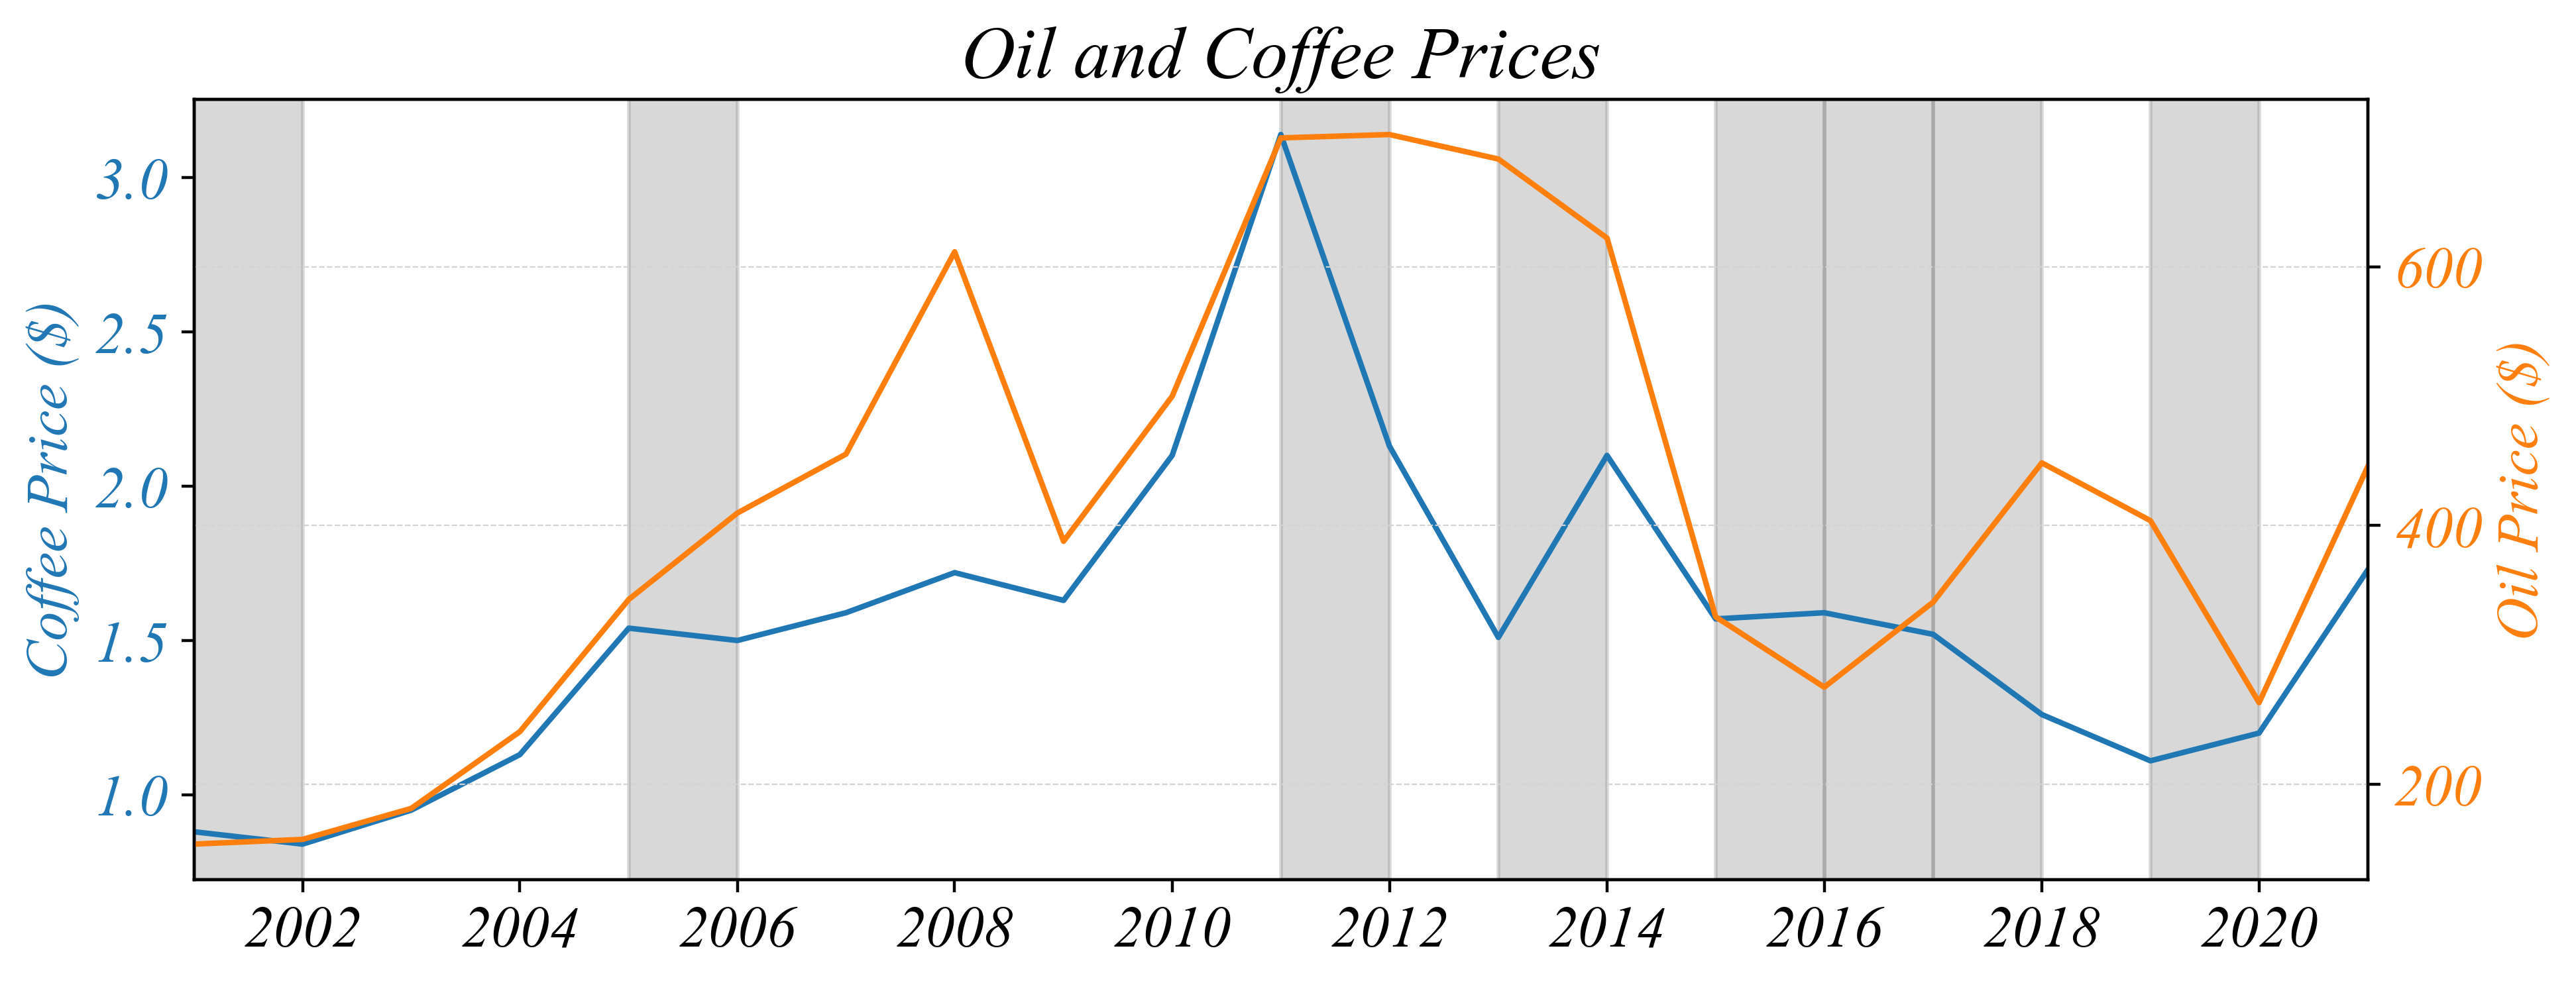

In [36]:
import matplotlib.dates as mdates

# Data
data = pd.read_csv('../../data/Coffee_Oil.csv')
data['date_column'] = pd.to_datetime(data['Year'], format='%Y')

# Figure
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot Coffee prices on the first y-axis
ax1.plot(data['date_column'], data['Coffee'], label='Coffee ($ per lb)', color='tab:blue')
ax1.set_xlabel('')
ax1.set_xlim(data['date_column'].min(), data['date_column'].max())
ax1.set_ylabel('Coffee Price ($)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis
ax2 = ax1.twinx()

# Plot Oil prices on the second y-axis
ax2.plot(data['date_column'], data['Oil'], label='Oil ($ per cubic meter)', color='tab:orange')
ax2.set_ylabel('Oil Price ($)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Determine where both prices increase or decrease together
# Create a mask for where both prices are increasing or decreasing
increasing = (data['Coffee'].diff() < 0) & (data['Oil'].diff() > 0)
decreasing = (data['Coffee'].diff() > 0) & (data['Oil'].diff() < 0)

# Plot grey bars where both prices increase or decrease
for i in range(1, len(data)):
    if increasing[i] or decreasing[i]:
        ax1.axvspan(data['date_column'].iloc[i-1], data['date_column'].iloc[i], color='grey', alpha=0.3)

# Add title and legend
plt.title('Oil and Coffee Prices')
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)
fig.tight_layout()  # Adjust layout to prevent overlap

# Save Figure
plt.savefig('i/c_20.png')

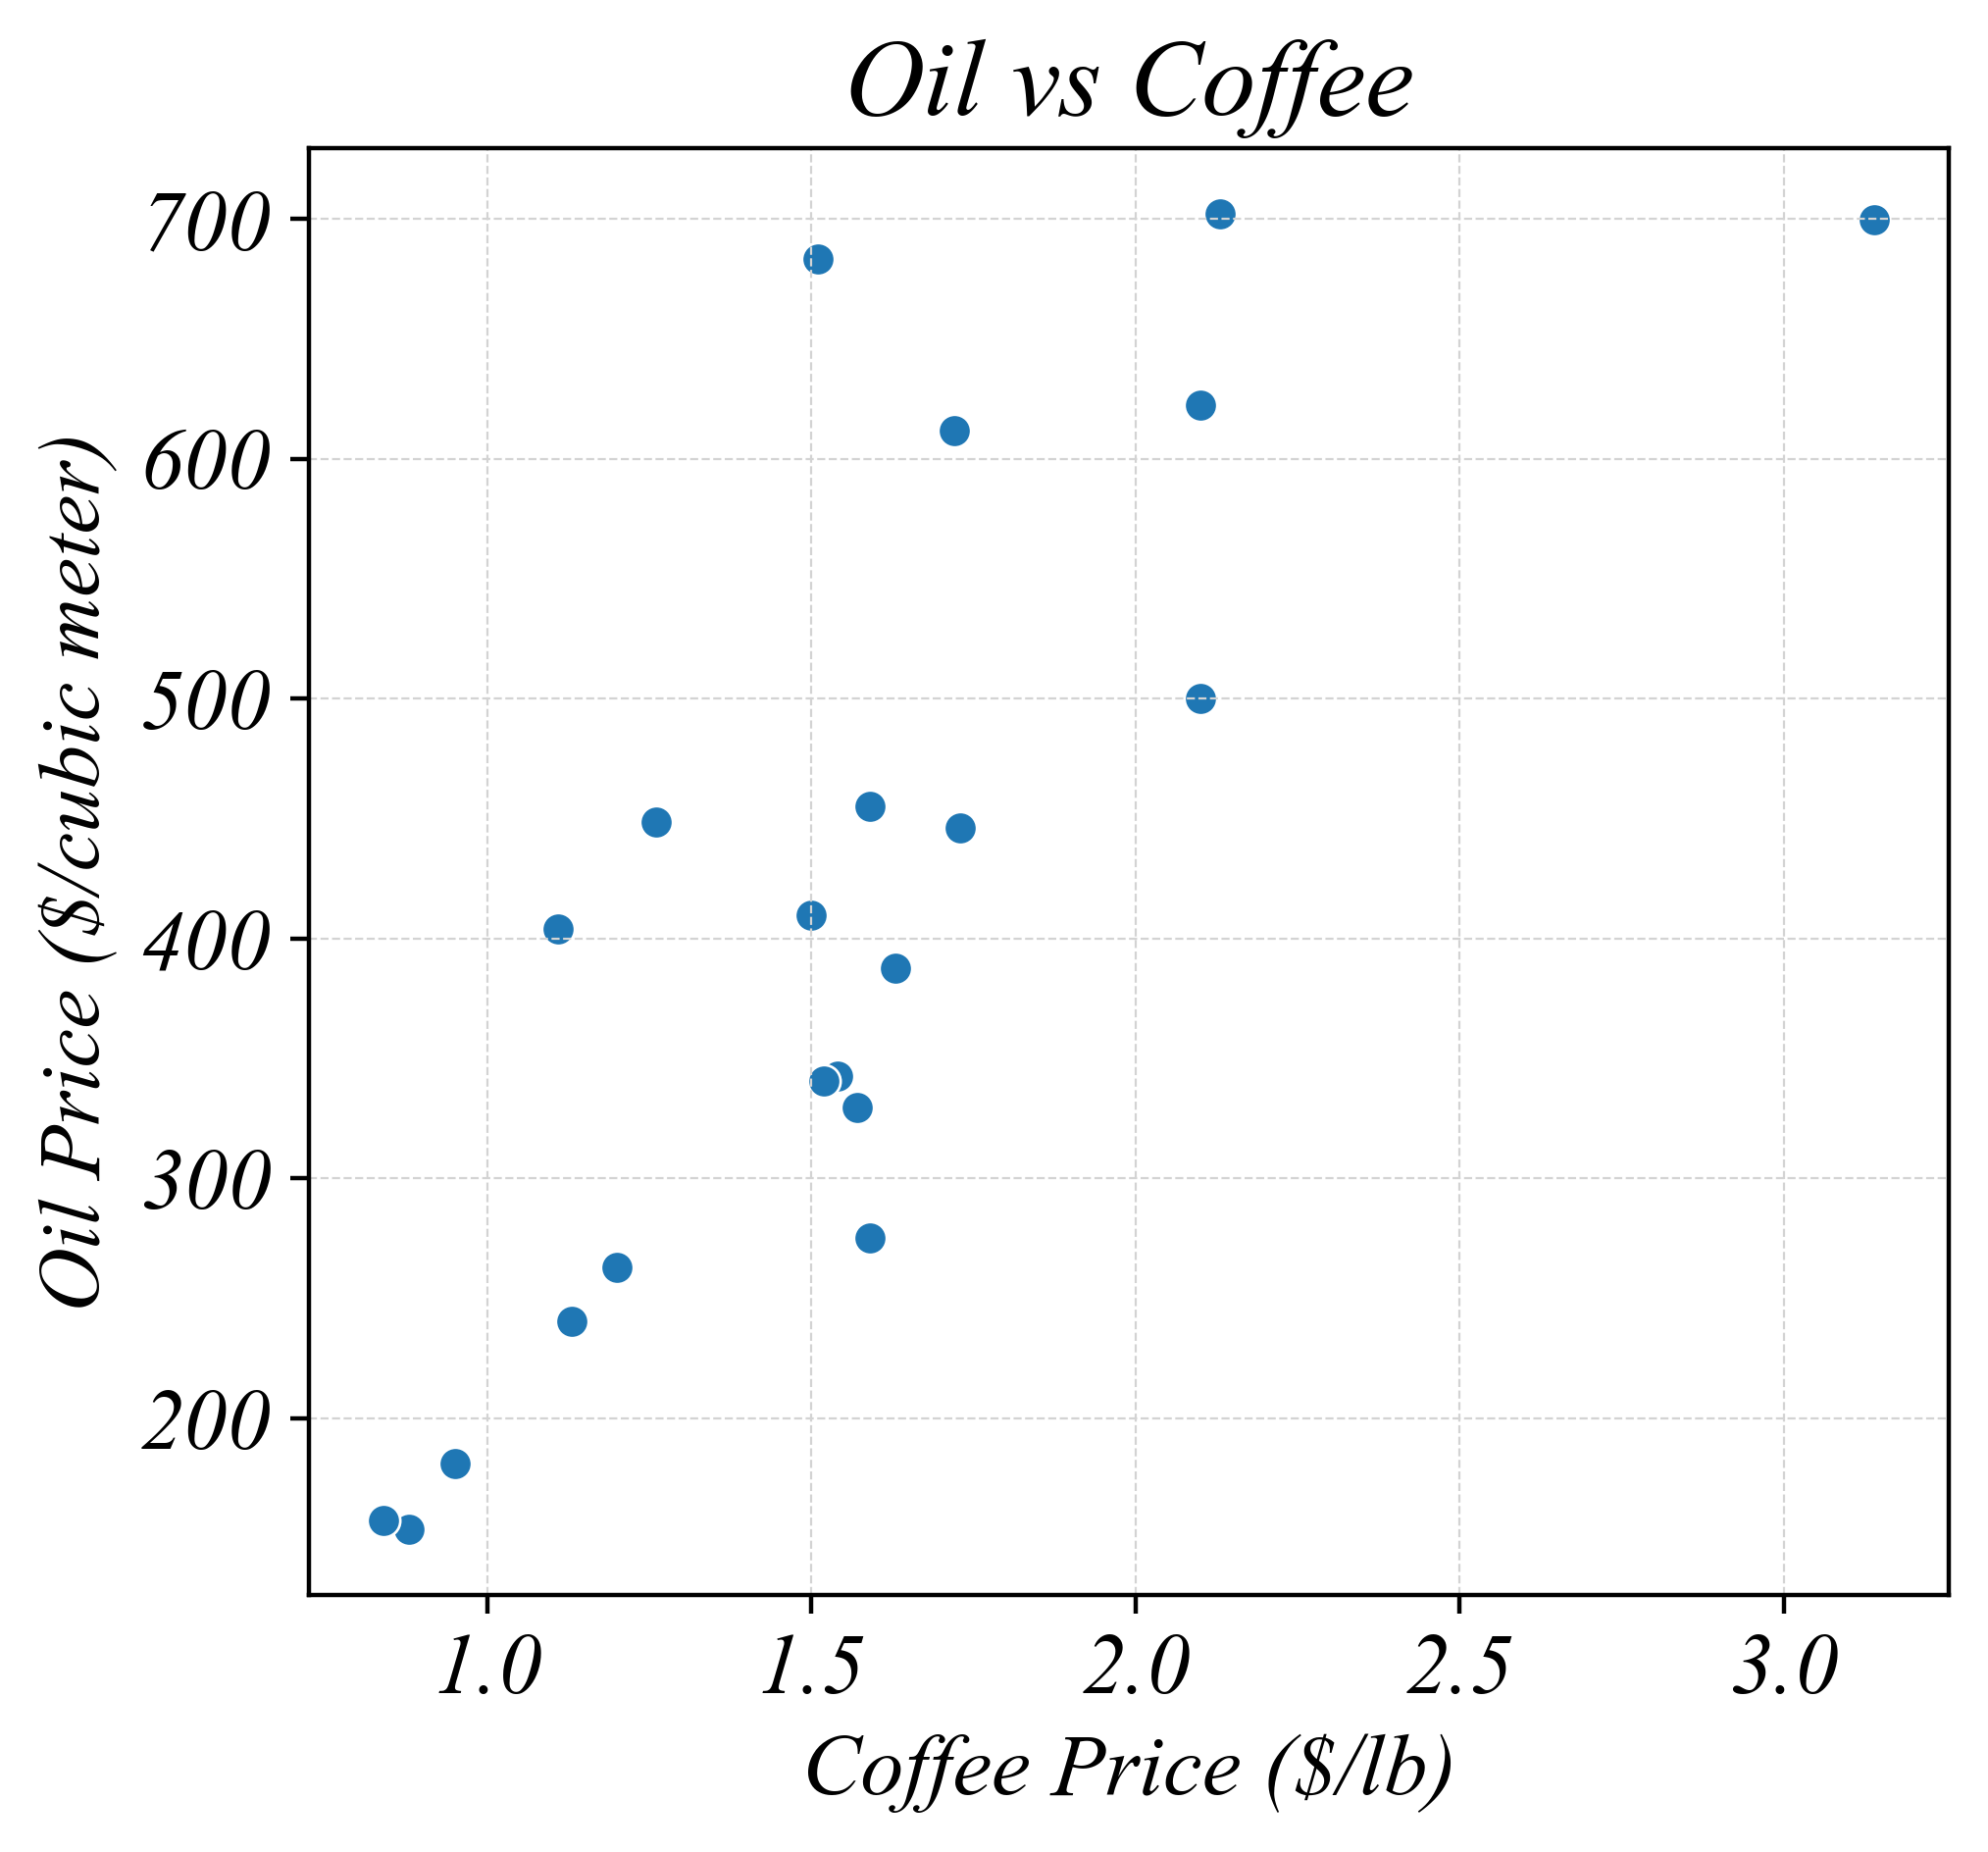

In [37]:
import matplotlib.dates as mdates

data = pd.read_csv('../../data/Coffee_Oil.csv')
data['date_column'] = pd.to_datetime(data['Year'], format='%Y')

# Figure (square with whitespace)
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 2.4, 1])
fig.add_subplot(gs[0, 1])

sns.scatterplot(data, x='Coffee', y='Oil')

# Styling
plt.xlabel('Coffee Price ($/lb)')
plt.ylabel('Oil Price ($/cubic meter)')
plt.title('Oil vs Coffee')
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.4)

plt.tight_layout()

# Save Figure
plt.savefig('i/c_21.png')

## Homework

In [38]:
heath = pd.read_csv('data/Heathrow.txt', sep='\s+', engine='python')
heath.to_csv('../../data/Heathrow.csv')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v7/n92bbkrn50x_rhkvsgm29llc0000gn/T/ipykernel_80456/4216943103.py:1: SyntaxWarning: invalid escape sequence '\s'
  heath = pd.read_csv('data/Heathrow.txt', sep='\s+', engine='python')


In [39]:
hires = pd.read_csv('../../data/Hires.csv')
hires.Hires = hires.Hires.str.replace(',', '').astype(int)

In [40]:
hires = pd.read_csv('../../data/Hires.csv')

# Example of cleaning up a column (if needed) - assuming 'Hires' is a column with commas
hires['Hires'] = hires['Hires'].str.replace(',', '').astype(int)

# Convert 'date_column' to datetime format (assuming there's a date column in your dataset)
# If there's no 'date_column' or different date format, adjust accordingly
hires['date_column'] = pd.to_datetime(hires['Day'], format='%m/%d/%y')

# Extract month and year into separate columns
hires['mm'] = hires['date_column'].dt.month
hires['yyyy'] = hires['date_column'].dt.year

# Group by month and year
grouped_hires = hires.groupby(['mm', 'yyyy']).agg({'Hires': 'sum'}).reset_index()

# Load the heath dataset
heath = pd.read_csv('../../data/Heathrow.csv', index_col=False)

merged_df = pd.merge(grouped_hires, heath, on=['mm', 'yyyy'], how='inner')
merged_df['sun'] = merged_df['sun'].replace(r'[^\d.]', '', regex=True)
merged_df['sun'] = pd.to_numeric(merged_df['sun'], errors='coerce')  # Convert to numeric, setting errors='coerce' will turn invalid parsing into NaN

merged_df.to_csv('../../data/Bike_Weather.csv')

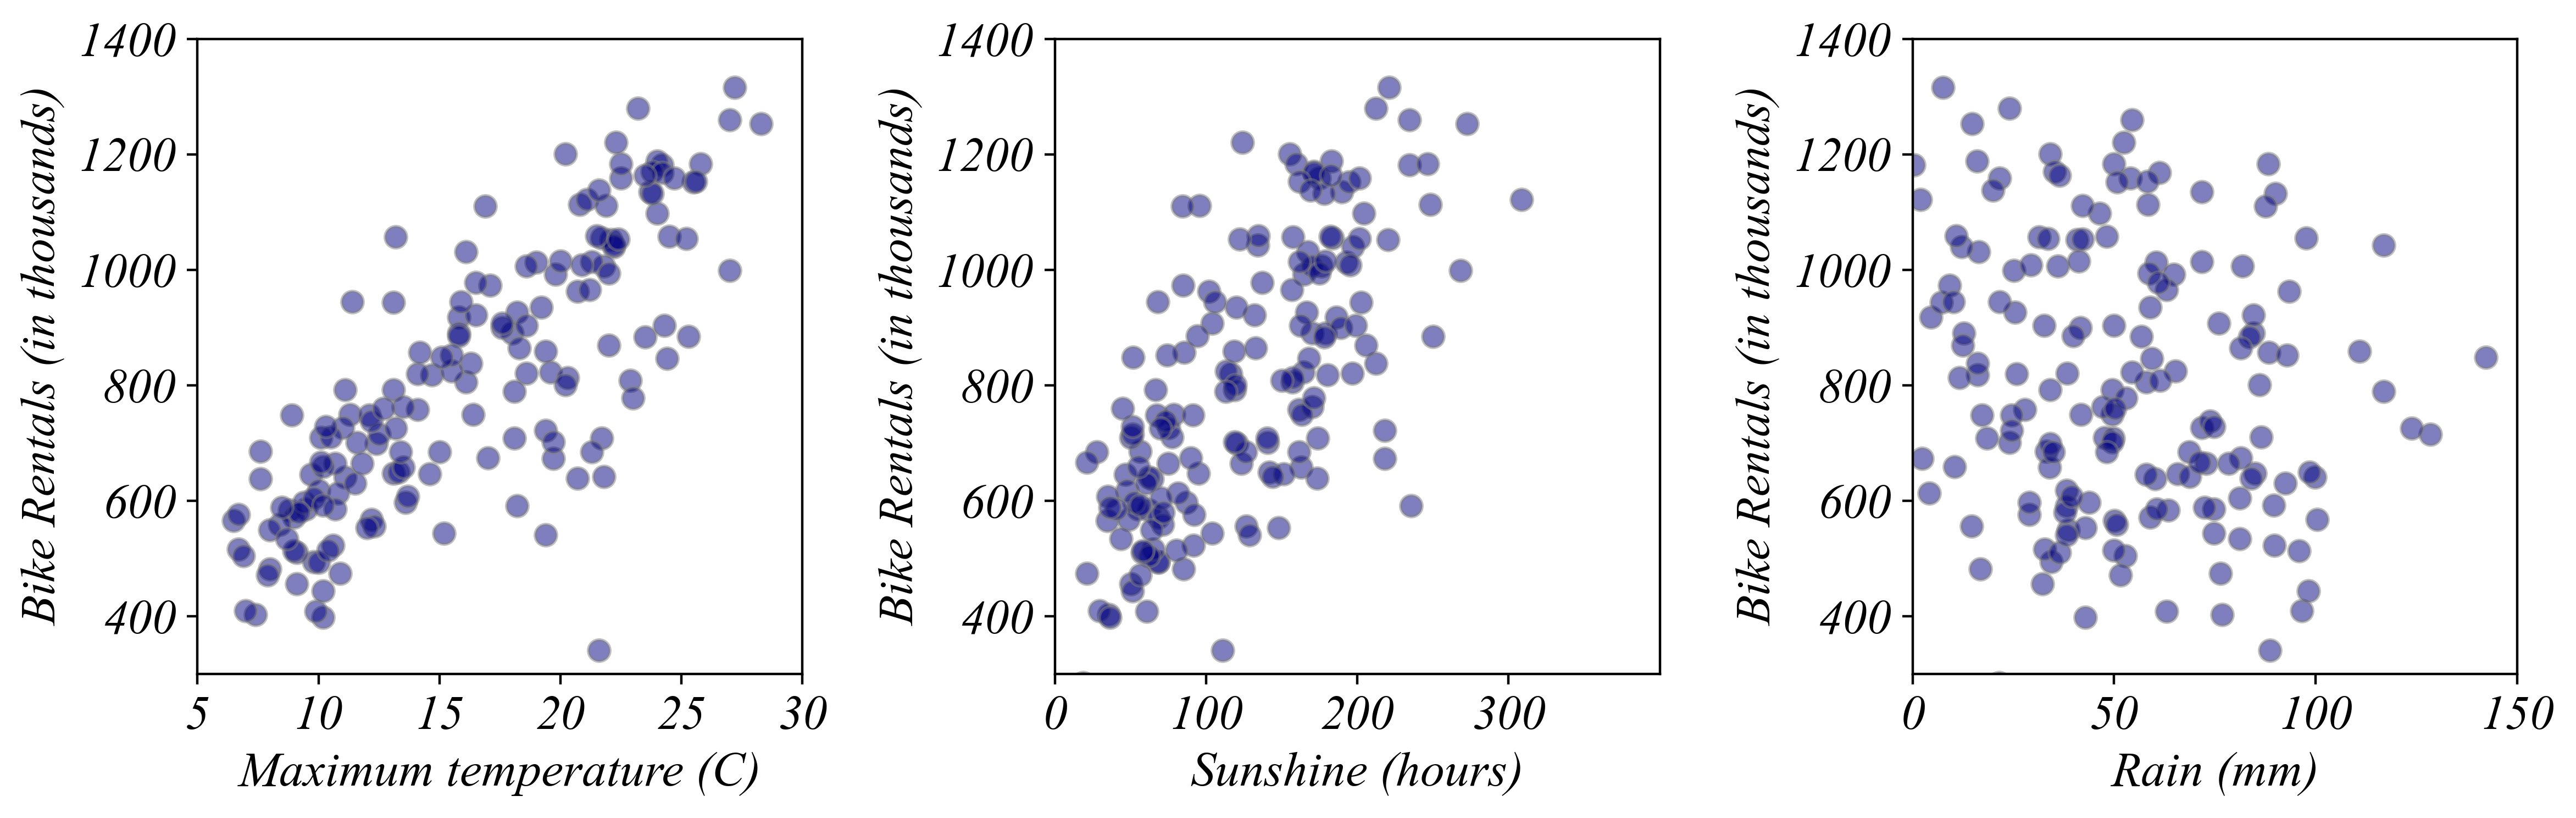

In [41]:
# Load Data
data = pd.read_csv('../../data/Bike_Weather.csv')

# Figure
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=400, gridspec_kw={'width_ratios': [1,1, 1]})
plt.subplots_adjust(left=0.05, right=0.95, wspace=0.05) # Adjust the space around the subplots

# Left subplot
ax = axs[0]
ax.scatter(data['tmax'], data['Hires']/1000, color='navy', edgecolors='grey', alpha=0.5, s=50)

# Styling
ax.set_xlabel('Maximum temperature (C)')
ax.set_xticks([5,10,15,20,25,30])
ax.set_xlim(5,30)
ax.set_ylabel('Bike Rentals (in thousands)')
ax.set_yticks([400,600,800,1000,1200,1400])
ax.set_ylim(300,1400)

# Middle subplot
ax = axs[1]
ax.scatter(data['sun'], data['Hires']/1000, color='navy', edgecolors='grey', alpha=0.5, s=50)

# Styling
ax.set_xlabel('Sunshine (hours)')
ax.set_xticks([0,100,200,300])
ax.set_xlim(0,400)
ax.set_ylabel('Bike Rentals (in thousands)')
ax.set_yticks([400,600,800,1000,1200,1400])
ax.set_ylim(300,1400)

# Right subplot
ax = axs[2]
ax.scatter(data['rain'], data['Hires']/1000, color='navy', edgecolors='grey', alpha=0.5, s=50)

# Stlying
ax.set_xlabel('Rain (mm)')
ax.set_xticks([0,50,100,150])
ax.set_xlim(0,150)
ax.set_ylabel('Bike Rentals (in thousands)')
ax.set_yticks([400,600,800,1000,1200,1400])
ax.set_ylim(300,1400)

# Save Figure
plt.tight_layout()
plt.savefig('i/hw_01.png', bbox_inches='tight')